# Technical-Analysis-Only Dynamic Asset Allocation
**Algorithmic Trading - Group Assignment**

**Universe:** ACWI, AGG, GLD, BSV (four ETFs only)

**Strategy type:** Weekly long-only, technical-analysis signals, no external data

**Data isolation rule:** All EDA, model design, diagnostics, and parameter selection use data
through 2024-12-31 only. Calendar year 2025 is the final out-of-sample test, held back until
the model is frozen.

## Project Summary

### What this project does
This notebook builds an **automated, rule-based investment strategy** for a basket of four ETFs. Every Friday, the strategy decides how much of a portfolio to allocate to each asset for the following week. No human judgment is used - the allocations are driven entirely by price-based mathematical signals computed from historical data.

### The four allowed assets
The assignment restricts the universe to exactly four ETFs:
- **ACWI**: a global equity ETF covering stocks from around the world (high growth potential, higher risk)
- **AGG**: a US investment-grade bond ETF (lower risk, stable income)
- **GLD**: a gold ETF (acts as a safe haven and inflation hedge, low correlation with stocks)
- **BSV**: a short-term bond ETF (very low risk, cash-like stability)

These four assets span the main risk categories - equities, long bonds, gold, and near-cash - providing genuine diversification opportunities. No other assets or data sources may be used.

### The core idea in plain English
The strategy follows a simple principle: *allocate more to assets that are trending upward with low volatility, and less to assets that are falling or erratic.* In quantitative finance, this is called **risk-adjusted momentum with trend filtering**: favour assets that have been rising steadily, and rotate towards the safer bond ETFs when no equity asset looks attractive.

### The full notebook workflow
| Section | Step | What happens |
|---------|------|--------------|
| 2 | Data preparation | Download daily adjusted prices; compute simple and log returns |
| 3 | Train/test split | Divide data into training (2007–2024) and out-of-sample test (2025) |
| 4 | Exploratory analysis | Understand each ETF's risk, return, and correlation profile |
| 5 | Signal construction | Build momentum, volatility, and moving-average trend indicators |
| 6 | Diagnostics | Test whether signals have statistical support in training data |
| 7 | Strategy variants | Define multiple candidate configurations to backtest |
| 8 | Portfolio construction | Turn signals into constrained, weekly, long-only weights |
| 9 | Parameter selection | Evaluate all candidates on training data; pick the most robust one |
| 10 | **Model freeze** | Lock all parameters - no further changes allowed |
| 11–12 | **Out-of-sample test** | Apply the frozen strategy to 2025 data for the first time |
| 13 | Robustness checks | Verify the strategy holds up across different assumptions |
| 14 | Constraint audit | Formally confirm every assignment rule is satisfied |
| 15 | Final discussion | Honest interpretation of results and limitations |
| 16 | Submission helper | Generate weekly CSV files in the required format |

### Results snapshot
The strategy is evaluated against two benchmarks: an equal-weight portfolio (25% in each ETF, rebalanced weekly) and a buy-and-hold position in ACWI. The detailed performance table - including annualised return, Sharpe ratio, and maximum drawdown for 2025 - is shown in Section 12. The strategy is designed to be competitive on a **risk-adjusted basis**: the goal is a consistent, drawdown-aware allocation, not a bet on a single asset.

## How to read this notebook

**The golden rule: 2025 data is never used until the model is fully locked in Section 10.**

| Sections | What is allowed |
|----------|-----------------|
| 1–9 | Only 2007–2024 training data. All charts, tables, and parameter choices are based on this period alone. |
| 10 | Model freeze. All parameters are written to disk. No further changes permitted. |
| 11–12 | 2025 data is used for the first time. This is the genuine out-of-sample test. |
| 13 | Robustness checks - but still only on training data. |
| 14 | Formal audit confirming all constraints are satisfied. |
| 15–17 | Interpretation, submission helper, and implementation checklist. |

**What this notebook is trying to show:**
The goal is not simply to maximise historical returns. It is to build a strategy that is:
1. **Constraint-compliant**: every assignment rule is followed and verified in code.
2. **Not over-fitted**: parameters are chosen by a multi-criterion score that rewards consistency across sub-periods, not just peak in-sample performance.
3. **Financially defensible**: the signals have economic intuition (momentum, trend following) supported by decades of academic evidence (Chan 2013).
4. **Honestly evaluated**: the 2025 out-of-sample test gives a fair read on real-world generalisability.

The notebook is written for a master's-level finance audience: familiar with financial markets and portfolio concepts, but not necessarily with quantitative trading code. Each major section includes a plain-English explanation of *what* is being done and *why* it matters.

## Key concepts in plain English

| Term | Plain-English definition |
|------|--------------------------|
| **Momentum** | The tendency of an asset that has recently risen to continue rising in the near term. A momentum signal scores assets by their recent returns and favours the leaders. |
| **Volatility** | How much an asset's price swings day-to-day. High volatility means larger, less predictable price moves. |
| **Trend filter** | A rule that checks whether an asset is in a general uptrend - for example, whether its price is above its 200-day moving average. Assets in a downtrend receive a lower or zero allocation. |
| **Drawdown** | The percentage fall from a portfolio's peak value to its subsequent lowest point. A maximum drawdown of −20% means the portfolio once fell 20% from its high before recovering. |
| **Sharpe ratio** | Return per unit of risk. A higher Sharpe means more return for each unit of volatility taken. A ratio above 0.5 is generally acceptable; above 1.0 is considered good. |
| **Turnover** | How much of the portfolio changes in a single rebalancing period. A weekly turnover cap of 25% means no more than 25 percentage points of portfolio weight can shift in one week. |
| **Transaction costs** | The cost of buying and selling. This notebook assumes 5 basis points (0.05%) per unit of turnover, deducted from returns on each execution day. |
| **Out-of-sample test** | Testing a strategy on data it has never seen before. Here, 2025 is the out-of-sample period - the strategy was designed exclusively using 2007–2024 data. |
| **Look-ahead bias** | A modelling error where future information accidentally influences past decisions - for example, using this week's prices to set last week's weights. This notebook avoids it by lagging all signals by one day. |
| **Robustness check** | A test asking: 'Does the strategy still work if we change one assumption?' For example, does it still perform well with a different momentum lookback window, or during a different historical sub-period? |

## 1. Assignment objective and constraints

### What we are building
We are building an automated, weekly portfolio allocation strategy. Every Friday, the model reads the four allowed ETFs' price histories, computes signals, and outputs a set of weights - four numbers that sum to 1.00 - that determine next week's allocation. The strategy follows strict rules (listed below) that mirror the constraints a real fund manager would face.

We model the assignment as a **weekly long-only portfolio allocation problem** across `{ACWI, AGG, GLD, BSV}`. The model produces a vector of four non-negative weights summing to 1.00 each Friday. The weights are applied to the following week's returns (one-day execution lag) to avoid look-ahead bias.

### Hard constraints enforced in code

| Constraint | What it means in practice | Implementation |
|---|---|---|
| Allowed assets only | Cannot include any ETF not in the approved list | `ALLOWED_TICKERS = ['ACWI','AGG','GLD','BSV']`; assertion blocks any other symbol |
| Long-only | Cannot 'short' (bet against) any asset | Weights clipped to `[0, 1]`; mean-reversion overlay is a long-only tilt |
| Fully invested, no leverage | Must deploy 100% of capital without borrowing | Weights normalised to sum exactly to 1.00 |
| Weekly rebalance | Positions can only be adjusted once per week | Last trading day of each ISO week |
| Turnover cap | At most 25 percentage points of the portfolio can shift per week | `move_toward_target_with_cap()` enforces `Σ|wₜ−wₜ₋₁| ≤ 0.25` |
| Execution lag | Signals from Friday can only be acted upon the next trading day | Daily weight panel is `shift(1)` before multiplying by returns |
| Transaction costs | Buying and selling is not free | Charged on execution day (same shift as weights) |
| Train/test split | 2025 cannot influence any design decision | Selection uses `<= 2024-12-31`; 2025 for OOS test only |
| No 2026 data | Test period ends 31 December 2025 | Explicit assertion after every load |

### Excluded data and methods

This strategy uses **only price-derived signals**. Explicitly excluded: fundamentals, macro indicators (GDP, CPI, interest rates, VIX, credit spreads), news, sentiment, analyst forecasts, short positions, long-short pairs, derivatives, leveraged ETFs, and any asset outside the four allowed tickers.

In [1]:
from __future__ import annotations

import json
import warnings
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as sps

import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, coint

try:
    from statsmodels.tsa.vector_ar.vecm import coint_johansen
    HAS_JOHANSEN = True
except Exception:
    HAS_JOHANSEN = False

try:
    import yfinance as yf
    HAS_YFINANCE = True
except Exception:
    HAS_YFINANCE = False

warnings.filterwarnings("ignore")
np.random.seed(42)
plt.rcParams["figure.figsize"] = (11, 5)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["axes.grid.which"] = "both"
plt.rcParams["grid.alpha"] = 0.25

# ---------------------------------------------------------------------------
# Assignment constants – single source of truth
# ---------------------------------------------------------------------------
ALLOWED_TICKERS    = ["ACWI", "AGG", "GLD", "BSV"]
START_DATE         = "2007-01-01"
TRAIN_END          = "2024-12-31"
TEST_START         = "2025-01-01"
TEST_END           = "2025-12-31"

MAX_WEEKLY_TURNOVER  = 0.25
TRANSACTION_COST_BPS = 5.0          # base assumption; stressed in robustness section
INITIAL_WEIGHTS      = pd.Series({"ACWI": 0.25, "AGG": 0.25, "GLD": 0.25, "BSV": 0.25})
TRADING_DAYS         = 252

OUTPUTS_DIR = Path("outputs")
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

print(json.dumps({
    "allowed_tickers":    ALLOWED_TICKERS,
    "start_date":         START_DATE,
    "train_end":          TRAIN_END,
    "test_start":         TEST_START,
    "test_end":           TEST_END,
    "max_weekly_turnover": MAX_WEEKLY_TURNOVER,
    "transaction_cost_bps": TRANSACTION_COST_BPS,
}, indent=2))

{
  "allowed_tickers": [
    "ACWI",
    "AGG",
    "GLD",
    "BSV"
  ],
  "start_date": "2007-01-01",
  "train_end": "2024-12-31",
  "test_start": "2025-01-01",
  "test_end": "2025-12-31",
  "max_weekly_turnover": 0.25,
  "transaction_cost_bps": 5.0
}


## Canonical blocks (inlined from shared/canonical.py)

The four blocks below (`constants`, `kpis`, `turnover`, `submission`) are inlined verbatim from `shared/canonical.py`. They define the shared schema all four verticals report against. Do not edit in place; edit `shared/canonical.py` and re-sync via the build script.

In [2]:
# === BEGIN canonical:constants ===
UNIVERSE = ["ACWI", "AGG", "GLD", "BSV"]
TEAM_ID = "TeamXX"
TRAIN_END = pd.Timestamp("2024-12-31")
VAL_END = pd.Timestamp("2025-12-31")
TURNOVER_CAP = 0.25
PERIODS_PER_YEAR = 52
RISK_FREE_RATE = 0.0
MAR = 0.0
MIN_PERIODS_FOR_RATIO = 24
RNG_SEED = 42

np.random.seed(RNG_SEED)
pd.set_option("display.float_format", "{:.4f}".format)
# === END canonical:constants ===

In [3]:
# === BEGIN canonical:kpis ===
def compute_kpis(
    returns: pd.Series,
    benchmark: pd.Series | None = None,
    *,
    periods_per_year: int = PERIODS_PER_YEAR,
    risk_free_rate: float = RISK_FREE_RATE,
    mar: float = MAR,
    min_periods_for_ratio: int = MIN_PERIODS_FOR_RATIO,
) -> dict:
    """Weekly KPI bank shared by every vertical.

    Sharpe uses mean excess return over sample-std (ddof=1), annualised by
    sqrt(periods_per_year). Sortino uses the textbook downside deviation:
    sqrt(mean(min(excess - mar_per_period, 0)^2)). Returns NaN for the
    ratio metrics when the sample is shorter than min_periods_for_ratio.
    """
    r = returns.dropna()
    if r.empty:
        return {}
    rf_per = risk_free_rate / periods_per_year
    mar_per = mar / periods_per_year
    ann = float(np.sqrt(periods_per_year))

    excess = r - rf_per
    mean_excess = float(excess.mean())
    vol = float(excess.std(ddof=1))

    downside = np.minimum(excess - mar_per, 0.0)
    downside_dev = float(np.sqrt(np.mean(np.square(downside))))

    equity = (1.0 + r).cumprod()
    drawdown = equity / equity.cummax() - 1.0
    n = len(r)
    n_years = n / periods_per_year
    total_return = float(equity.iloc[-1] - 1.0)
    cagr = float(equity.iloc[-1] ** (1.0 / n_years) - 1.0) if n_years > 0 else float("nan")
    max_dd = float(drawdown.min())

    enough = n >= min_periods_for_ratio
    sharpe = (mean_excess / vol) * ann if enough and vol > 0 else float("nan")
    sortino = (mean_excess / downside_dev) * ann if enough and downside_dev > 0 else float("nan")
    calmar = cagr / abs(max_dd) if max_dd < 0 and not np.isnan(cagr) else float("nan")

    out = {
        "n_periods": int(n),
        "total_return": total_return,
        "CAGR": cagr,
        "ann_return": float(r.mean() * periods_per_year),
        "ann_vol": float(r.std(ddof=1) * ann),
        "Sharpe": float(sharpe),
        "Sortino": float(sortino),
        "max_drawdown": max_dd,
        "calmar": float(calmar),
        "hit_rate": float((r > 0).mean()),
        "best_period": float(r.max()),
        "worst_period": float(r.min()),
    }
    if benchmark is not None:
        bench = benchmark.reindex(r.index).dropna()
        active = (r - bench).dropna()
        if len(active) >= min_periods_for_ratio and active.std(ddof=1) > 0:
            out["active_sharpe_vs_bench"] = float(
                (active.mean() / active.std(ddof=1)) * ann
            )
        else:
            out["active_sharpe_vs_bench"] = float("nan")
        out["excess_ann_return"] = (
            float(active.mean() * periods_per_year) if not active.empty else float("nan")
        )
    return out
# === END canonical:kpis ===

In [4]:
# === BEGIN canonical:turnover ===
def project_to_turnover_ball(
    target: pd.Series,
    previous: pd.Series,
    *,
    cap: float = TURNOVER_CAP,
) -> pd.Series:
    """L1-ball projection of target toward previous so sum(|target-previous|) <= cap.

    Returns a Series indexed by UNIVERSE, clipped to [0,1] and renormalised to
    sum to 1. Matches the math each vertical already used independently.
    """
    target = target.reindex(UNIVERSE).astype(float)
    previous = previous.reindex(UNIVERSE).astype(float)
    delta = target - previous
    total = float(np.abs(delta).sum())
    if total <= cap + 1e-12:
        out = target.copy()
    else:
        out = previous + delta * (cap / total)
    out = out.clip(lower=0.0, upper=1.0)
    s = float(out.sum())
    return out / s if s > 0 else target
# === END canonical:turnover ===

In [5]:
# === BEGIN canonical:submission ===
def write_submission_csv(
    weights_fraction: pd.Series,
    week: "pd.Timestamp | str",
    team_id: str,
    out_dir: Path,
    *,
    vertical_tag: str | None = None,
    previous_path: Path | None = None,
    enforce_turnover: bool = True,
) -> Path:
    """Write the weekly submission CSV in the format mandated by CLAUDE.md.

    Input weights are fractions in [0,1] summing to 1. They are scaled to
    percentages, rounded to two decimals, and the residual is added to the
    largest weight so the row sums to exactly 100.00. Per-vertical draft files
    get a {team_id}_{vertical_tag}_{date}.csv name; the final team submission
    uses {team_id}_{date}.csv. Header is week,team_id,acwi,agg,gld,bsv.
    """
    week_ts = pd.Timestamp(week)
    week_str = week_ts.strftime("%Y-%m-%d")
    w = weights_fraction.reindex(UNIVERSE).astype(float) * 100.0
    w = w.round(2)
    residual = round(100.0 - float(w.sum()), 2)
    largest = w.idxmax()
    w.loc[largest] = round(float(w.loc[largest]) + residual, 2)
    if not ((w >= 0).all() and (w <= 100).all()):
        raise ValueError(f"weights out of [0,100]: {w.to_dict()}")
    if abs(float(w.sum()) - 100.0) > 1e-6:
        raise ValueError(f"weights do not sum to 100: {float(w.sum())}")
    if enforce_turnover and previous_path is not None and Path(previous_path).exists():
        prev_df = pd.read_csv(previous_path)
        prev_w = pd.Series(
            {k: float(prev_df.iloc[0][k.lower()]) for k in UNIVERSE},
        ).reindex(UNIVERSE)
        turnover_pp = float((w - prev_w).abs().sum())
        if turnover_pp - 25.0 > 1e-9:
            raise ValueError(
                f"turnover {turnover_pp:.2f}pp > 25.00pp vs {Path(previous_path).name}"
            )
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    name = (
        f"{team_id}_{vertical_tag}_{week_str}.csv"
        if vertical_tag
        else f"{team_id}_{week_str}.csv"
    )
    path = out_dir / name
    row = {
        "week": week_str,
        "team_id": team_id,
        "acwi": w["ACWI"],
        "agg": w["AGG"],
        "gld": w["GLD"],
        "bsv": w["BSV"],
    }
    pd.DataFrame([row], columns=["week", "team_id", "acwi", "agg", "gld", "bsv"]).to_csv(
        path, index=False, float_format="%.2f",
    )
    return path
# === END canonical:submission ===

In [6]:
def compute_canonical_kpis(daily_returns, daily_benchmark=None):
    """Resample daily returns to weekly Friday close and call canonical compute_kpis."""
    if daily_returns is None or len(daily_returns) == 0:
        return {}
    weekly_r = (1.0 + daily_returns.fillna(0.0)).resample("W-FRI").prod() - 1.0
    weekly_r = weekly_r.dropna()
    weekly_b = None
    if daily_benchmark is not None and len(daily_benchmark) > 0:
        weekly_b = (1.0 + daily_benchmark.fillna(0.0)).resample("W-FRI").prod() - 1.0
        weekly_b = weekly_b.dropna()
    return compute_kpis(weekly_r, weekly_b)


## 2. Data extraction and preparation

### What we are doing
We download daily historical price data for all four ETFs from Yahoo Finance. The data runs from 2007 (when BSV was first listed) through the end of 2025. We then compute daily returns and split the data into a training set (up to end of 2024) and a test set (2025).

### Adjusted prices: why they matter
We use **adjusted close prices** (`auto_adjust=True`). This means that cash dividends, stock splits, and other corporate actions are already reflected in the price series. Without this adjustment, a dividend payment would appear as a sudden price drop, which would generate a false negative momentum signal. Adjusted prices give a true picture of total investor wealth over time.

### Simple returns and log returns
From adjusted prices, we compute two types of daily returns:
- **Simple returns** (`r_t = P_t / P_{t−1} − 1`): the percentage change from one day to the next. Used for performance reporting and portfolio construction.
- **Log returns** (`r_t = ln(P_t / P_{t−1})`): the natural logarithm of the price ratio. Used in certain statistical tests because they are additive across time and more tractable mathematically.

We pull daily adjusted-close prices from Yahoo Finance (`auto_adjust=True`). The panel is filtered to the common history of all four ETFs (dropping the first rows where any ETF is missing) and clipped to `TEST_END = 2025-12-31`. A defensive assertion blocks any 2026 rows.

If yfinance is unavailable, the notebook falls back to a local `outputs/clean_prices.csv`.
### Data isolation policy
The full panel is loaded for reproducibility, but all exploratory model design, diagnostics, parameter selection, and robustness decisions before the freeze use only data through 2024-12-31. Calendar year 2025 is displayed and evaluated only after the selected parameters are frozen.


In [7]:
def download_or_load_data(tickers, start, end):
    """Return an adjusted-close panel (date x ticker)."""
    local_csv = OUTPUTS_DIR / "clean_prices.csv"
    panel = None

    if HAS_YFINANCE:
        try:
            raw = yf.download(
                tickers,
                start=start,
                end=pd.Timestamp(end) + pd.Timedelta(days=1),
                auto_adjust=True,
                progress=False,
                group_by="column",
                threads=True,
            )
            if isinstance(raw.columns, pd.MultiIndex):
                if "Close" in raw.columns.get_level_values(0):
                    panel = raw["Close"].copy()
                elif "Adj Close" in raw.columns.get_level_values(0):
                    panel = raw["Adj Close"].copy()
            else:
                panel = raw[["Close"]].rename(columns={"Close": tickers[0]})
        except Exception as e:
            print(f"[warn] yfinance failed: {e!r}")

    if panel is None:
        if local_csv.exists():
            panel = pd.read_csv(local_csv, index_col=0, parse_dates=True)
            print(f"[info] loaded local CSV: {local_csv}")
        else:
            raise RuntimeError(
                "No data: yfinance failed and no outputs/clean_prices.csv found. "
                "Either enable internet access (yfinance) or place a pre-built "
                "clean_prices.csv (columns: ACWI, AGG, GLD, BSV; index: date) "
                "in the outputs/ directory."
            )
    return panel


def prepare_price_panel(raw_panel, tickers, test_end=TEST_END):
    """Align, clean, and validate the price panel."""
    panel = raw_panel.copy()
    panel = panel.sort_index()
    panel = panel[~panel.index.duplicated(keep="last")]
    panel = panel.dropna(how="any")
    panel = panel.loc[:test_end]

    missing = [t for t in tickers if t not in panel.columns]
    if missing:
        raise RuntimeError(f"Missing tickers: {missing}")
    panel = panel[tickers].copy()

    assert sorted(panel.columns.tolist()) == sorted(tickers)
    assert panel.index.max() <= pd.Timestamp(test_end)
    assert not (panel.index.year >= 2026).any(), "2026 data found – forbidden"
    assert not panel.isna().any().any(), "Missing prices after cleaning"
    return panel


raw    = download_or_load_data(ALLOWED_TICKERS, START_DATE, TEST_END)
prices = prepare_price_panel(raw, ALLOWED_TICKERS)
prices.to_csv(OUTPUTS_DIR / "clean_prices.csv")
print(f"Price panel: {prices.shape}, {prices.index[0].date()} to {prices.index[-1].date()}")
display(prices.loc[:TRAIN_END].tail(3))  # training-period tail only


Price panel: (4470, 4), 2008-03-28 to 2025-12-31


Ticker,ACWI,AGG,GLD,BSV
Date,,,,
2024-12-27,116.3430,91.4121,241.4000,72.9504
2024-12-30,115.1506,91.7716,240.6300,73.1113
2024-12-31,114.8379,91.6580,242.1300,73.1302


In [8]:
def compute_returns(prices):
    """Daily simple and log returns (no forward fill)."""
    simple = prices.pct_change().dropna()
    log    = np.log(prices).diff().dropna()
    return simple, log


returns, log_returns = compute_returns(prices)
returns.to_csv(OUTPUTS_DIR / "daily_returns.csv")

# ---------------------------------------------------------------------------
# Train/test split – define here so ALL subsequent cells use these objects.
# EDA and pre-selection analysis use eda_prices / eda_returns only.
# ---------------------------------------------------------------------------
train_prices  = prices.loc[:TRAIN_END]
test_prices   = prices.loc[TEST_START:TEST_END]
train_returns = returns.loc[:TRAIN_END]
test_returns  = returns.loc[TEST_START:TEST_END]

# EDA objects are identical to training objects (explicit alias for clarity)
eda_prices  = train_prices.copy()
eda_returns = train_returns.copy()

# ---------------------------------------------------------------------------
# Mandatory forbidden-data audit
# ---------------------------------------------------------------------------
def forbidden_data_audit(panel):
    assert sorted(panel.columns.tolist()) == sorted(ALLOWED_TICKERS),         "Forbidden ticker detected"
    assert panel.index.max() <= pd.Timestamp(TEST_END), "Data past 2025-12-31"
    assert not (panel.index.year >= 2026).any(), "2026 data present"
    print("forbidden_data_audit: PASSED")

forbidden_data_audit(prices)

# Train/test isolation assertions
assert train_prices.index.max()  <= pd.Timestamp(TRAIN_END),  "train_prices leaks past TRAIN_END"
assert train_returns.index.max() <= pd.Timestamp(TRAIN_END),  "train_returns leaks past TRAIN_END"
assert test_prices.index.min()   >= pd.Timestamp(TEST_START), "test_prices starts before TEST_START"
assert test_prices.index.max()   <= pd.Timestamp(TEST_END),   "test_prices extends past TEST_END"

print(f"Train: {train_prices.shape[0]} rows,  "
      f"{train_prices.index[0].date()} – {train_prices.index[-1].date()}")
print(f"Test:  {test_prices.shape[0]} rows,  "
      f"{test_prices.index[0].date()} – {test_prices.index[-1].date()}")
print("Data isolation audit: PASSED")

forbidden_data_audit: PASSED
Train: 4220 rows,  2008-03-28 – 2024-12-31
Test:  250 rows,  2025-01-02 – 2025-12-31
Data isolation audit: PASSED


## 3. Train/test split and data-isolation policy

### Why this matters: the look-ahead bias problem
Imagine designing a trading strategy and then testing it on the same data used to design it. Of course it looks good - you already knew the answers. This is called **look-ahead bias** (or data leakage), and it makes any performance measure meaningless as a guide to real-world results.

To produce an honest out-of-sample test, the data is divided into two strictly separate periods:
- **Training period (2007–2024):** Used for all exploration, signal design, diagnostic testing, and parameter selection. This is the data the model “sees” during development.
- **Test period (2025 only):** Completely sealed off until the model is frozen. Used only once, at the end, to evaluate whether the strategy generalises to genuinely unseen data.

> **From this point until Section 11 (final out-of-sample test), all charts, diagnostic
> tables, model comparisons, robustness checks used for model selection, and parameter
> choices use only data dated on or before 2024-12-31.  Calendar year 2025 is loaded only
> so the final out-of-sample test can be run later; it is not displayed or analysed before
> the selected strategy is frozen and `outputs/selected_parameters.json` is written.**

### Why 2025 data is loaded but not used here
The 2025 prices are downloaded at the same time as the training data for convenience, but they are stored in separate variables (`test_prices`, `test_returns`) and are never referenced before Section 11. The objects `eda_prices` and `eda_returns` are training-period aliases used throughout Sections 4–9 below. The 2025 split (`test_prices`, `test_returns`) is first touched in Section 11.

## 4. Training-only exploratory data analysis

All EDA uses `eda_prices = prices.loc[:'2024-12-31']` and `eda_returns = returns.loc[:'2024-12-31']`. No 2025 data is shown here.

### What are we doing here?
Before building any signals, we look at the raw data to understand the four ETFs: how they have grown over time, how volatile each one is, and how correlated they are with each other.

### Why does it matter?
A good tactical allocation strategy needs to exploit differences between assets. If all four ETFs moved in perfect lockstep, there would be nothing to gain from shifting between them - equal-weighting would be optimal. EDA confirms that meaningful diversification opportunities exist in the data.

### What to look for in the output
- **Normalised price chart:** Shows cumulative growth from a common starting index of 100. ACWI should show the highest long-run return but also the largest drawdowns; BSV the lowest return but the smoothest path.
- **Rolling volatility:** ACWI and GLD tend to have higher volatility than AGG and BSV. This motivates the volatility-scaling step in Section 5.
- **Correlation heatmap:** Look for which pairs are least correlated - especially between ACWI and AGG or GLD during market stress. Low correlations are the foundation for the strategy's diversification benefit.

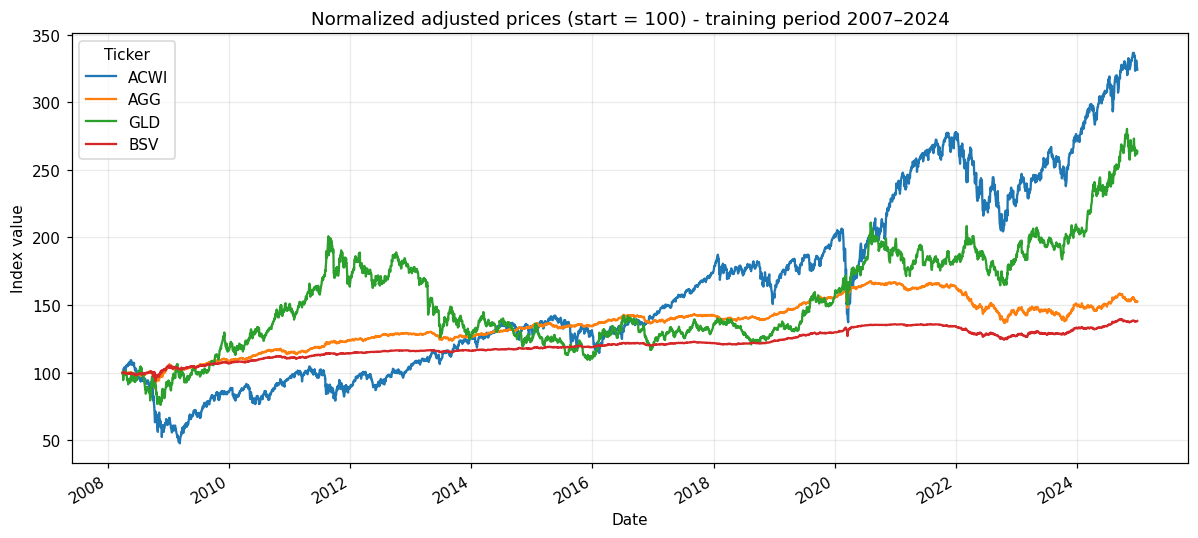

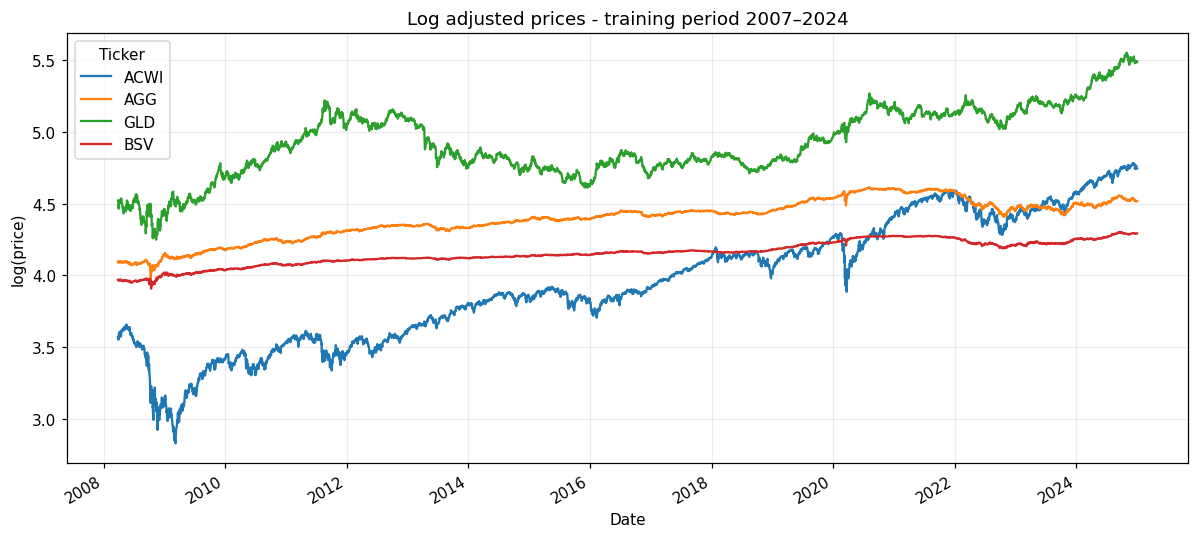

Daily return summary statistics - training data only (2007–2024):


,mean_daily,std_daily,ann_vol,skew,kurtosis,min,max
Ticker,,,,,,,
ACWI,0.0004,0.0129,0.2044,-0.2944,11.6992,-0.1122,0.1241
AGG,0.0001,0.0035,0.0551,-2.0011,52.0574,-0.0684,0.0387
GLD,0.0003,0.0109,0.1723,-0.0879,7.1776,-0.0878,0.1129
BSV,0.0001,0.0019,0.0303,-1.0915,58.8866,-0.0332,0.0262


In [9]:
# 4.1 Normalized prices (start at 100) – TRAINING DATA ONLY
norm = eda_prices / eda_prices.iloc[0] * 100.0
ax = norm.plot(title="Normalized adjusted prices (start = 100) - training period 2007–2024")
ax.set_ylabel("Index value")
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "eda_normalized_prices.png", dpi=140)
plt.show()

# 4.2 Log prices – TRAINING DATA ONLY
ax = np.log(eda_prices).plot(title="Log adjusted prices - training period 2007–2024")
ax.set_ylabel("log(price)")
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "eda_log_prices.png", dpi=140)
plt.show()

# 4.3 Daily return summary statistics – TRAINING DATA ONLY
desc = pd.DataFrame({
    "mean_daily":  eda_returns.mean(),
    "std_daily":   eda_returns.std(),
    "ann_vol":     eda_returns.std() * np.sqrt(TRADING_DAYS),
    "skew":        eda_returns.skew(),
    "kurtosis":    eda_returns.kurtosis(),
    "min":         eda_returns.min(),
    "max":         eda_returns.max(),
})
print("Daily return summary statistics - training data only (2007–2024):")
display(desc.round(4))

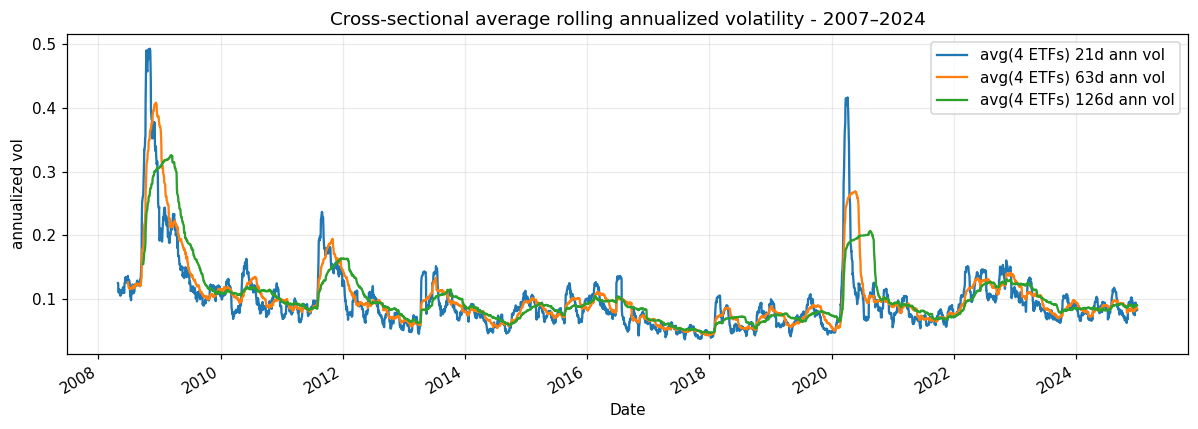

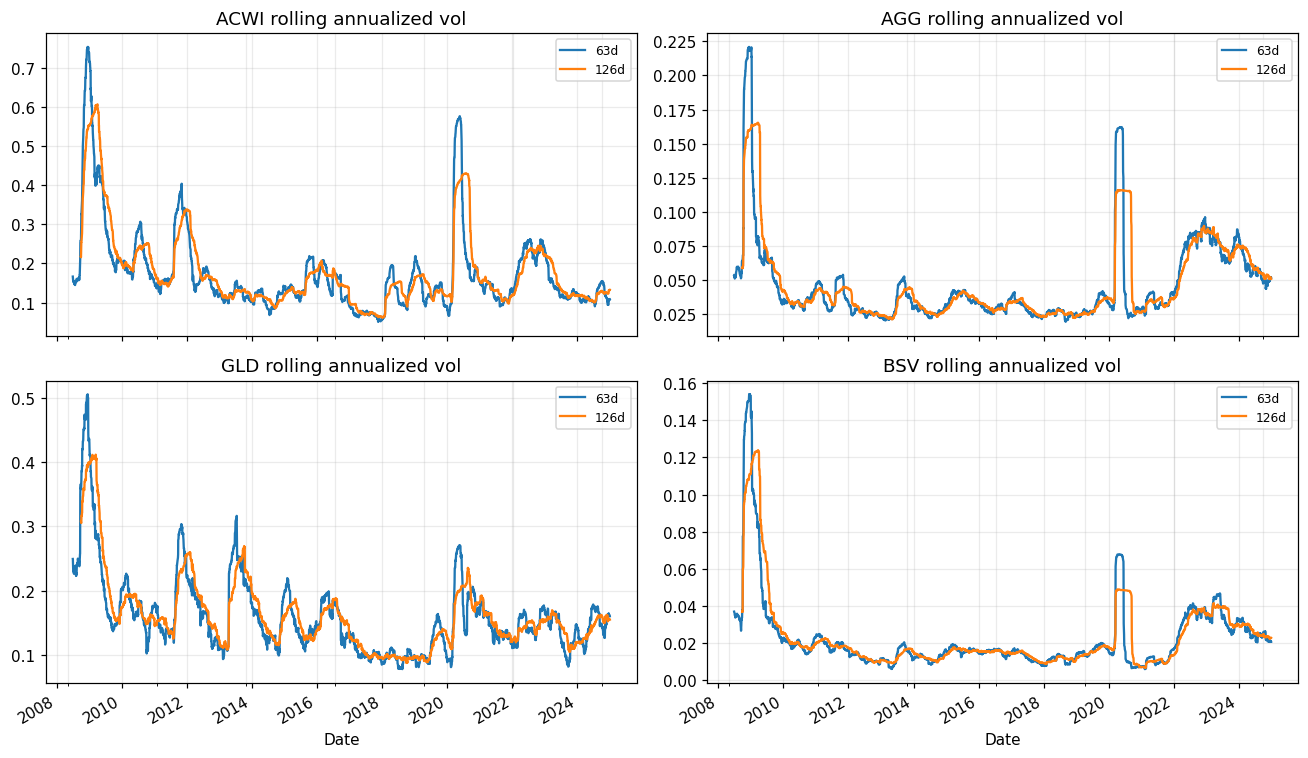

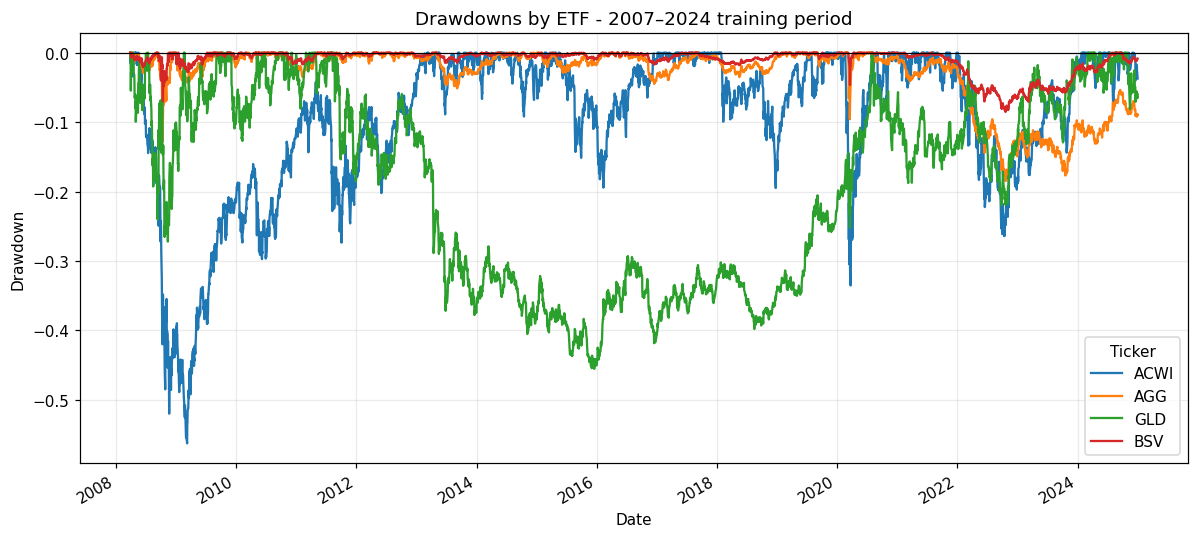

In [10]:
# 4.4 Rolling annualized volatility – TRAINING DATA ONLY
fig, ax = plt.subplots(figsize=(11, 4))
for w in (21, 63, 126):
    (eda_returns.rolling(w).std() * np.sqrt(TRADING_DAYS)).mean(axis=1).plot(
        ax=ax, label=f"avg(4 ETFs) {w}d ann vol")
ax.set_title("Cross-sectional average rolling annualized volatility - 2007–2024")
ax.set_ylabel("annualized vol")
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "eda_rolling_vol_avg.png", dpi=140)
plt.show()

# Per-ETF rolling vol
fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True)
for ax, tkr in zip(axes.ravel(), ALLOWED_TICKERS):
    (eda_returns[tkr].rolling(63).std() * np.sqrt(TRADING_DAYS)).plot(
        ax=ax, label="63d", color="#1f77b4")
    (eda_returns[tkr].rolling(126).std() * np.sqrt(TRADING_DAYS)).plot(
        ax=ax, label="126d", color="#ff7f0e")
    ax.set_title(f"{tkr} rolling annualized vol")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "eda_rolling_vol_per_etf.png", dpi=140)
plt.show()

# 4.5 Drawdowns – TRAINING DATA ONLY
def _drawdown_series(prc):
    eq = prc / prc.iloc[0]
    return eq / eq.cummax() - 1.0

dd = eda_prices.apply(_drawdown_series)
ax = dd.plot(title="Drawdowns by ETF - 2007–2024 training period")
ax.set_ylabel("Drawdown")
ax.axhline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "eda_drawdowns.png", dpi=140)
plt.show()

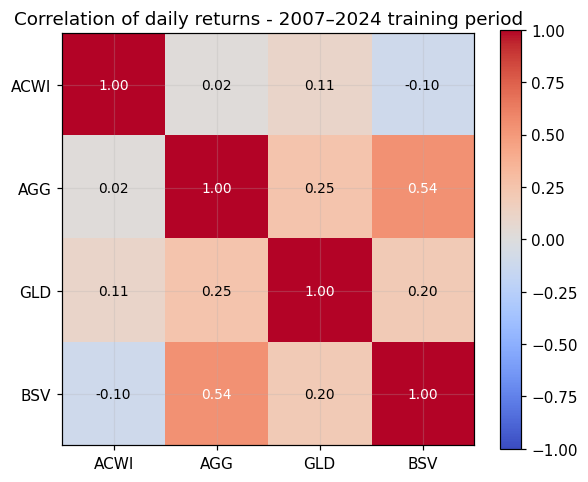

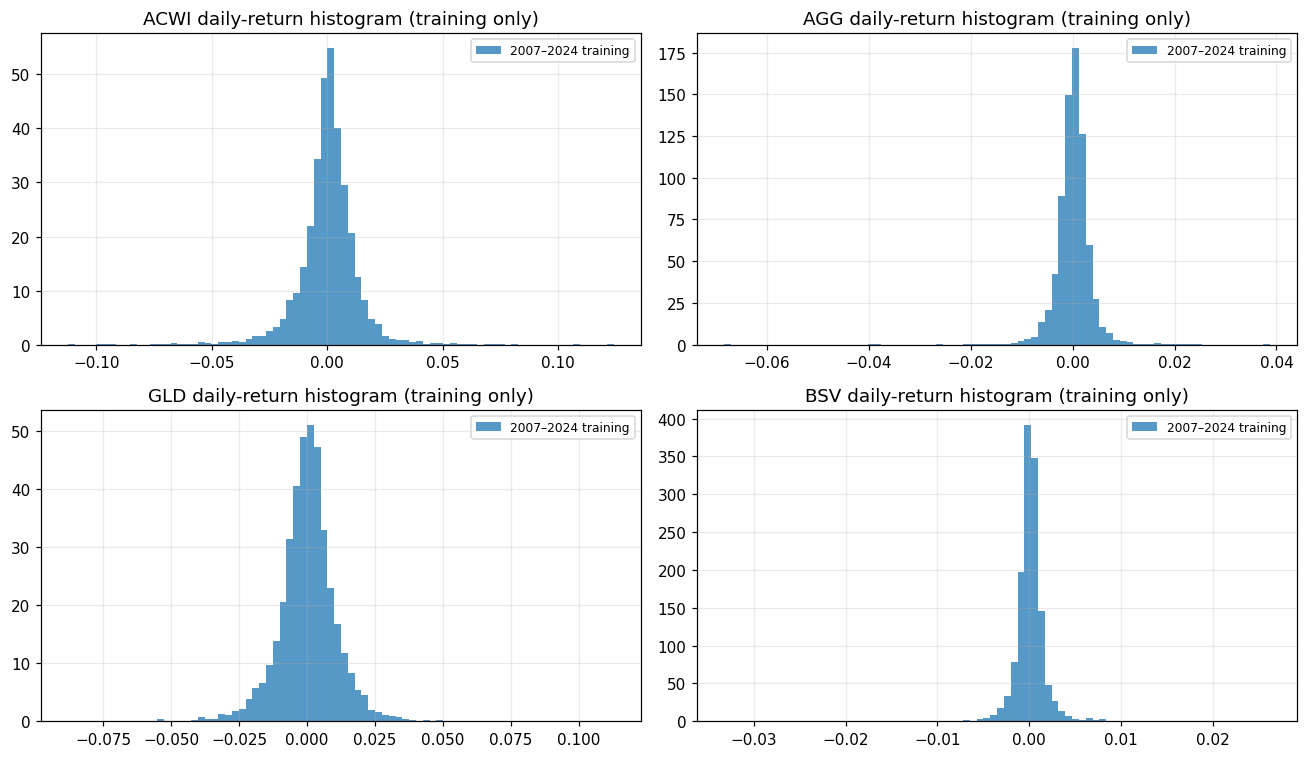

In [11]:
# 4.6 Correlation heatmap – TRAINING DATA ONLY
corr = eda_returns.corr()
fig, ax = plt.subplots(figsize=(5.5, 4.5))
im = ax.imshow(corr.values, vmin=-1, vmax=1, cmap="coolwarm")
ax.set_xticks(range(len(corr.columns))); ax.set_xticklabels(corr.columns)
ax.set_yticks(range(len(corr.index)));   ax.set_yticklabels(corr.index)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.values[i, j]:.2f}",
                ha="center", va="center",
                color="white" if abs(corr.values[i, j]) > 0.5 else "black", fontsize=9)
plt.colorbar(im, ax=ax)
ax.set_title("Correlation of daily returns - 2007–2024 training period")
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "eda_correlation_heatmap.png", dpi=140)
plt.show()

# 4.7 Return distributions – TRAINING DATA ONLY
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
for ax, tkr in zip(axes.ravel(), ALLOWED_TICKERS):
    ax.hist(eda_returns[tkr].values, bins=80, alpha=0.75,
            color="#1f77b4", density=True, label="2007–2024 training")
    ax.set_title(f"{tkr} daily-return histogram (training only)")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "eda_return_distributions.png", dpi=140)
plt.show()

### EDA interpretation (training data only)

- **ACWI** dominates long-run cumulative growth with the highest realised volatility.
- **AGG** provides low-volatility diversification and smaller drawdowns.
- **GLD** has equity-like volatility but low, time-varying correlation with both ACWI and AGG, making it a valuable diversifier during equity stress periods.
- **BSV** has the lowest volatility and the smoothest equity curve - effectively cash-like.

**Bottom line:** These four ETFs behave differently enough to reward tactical allocation. An asset that is in a strong, low-volatility uptrend (often ACWI in bull markets) deserves a larger weight; when risk signals deteriorate, rotating towards AGG and BSV preserves capital.

These properties motivate a **trend-and-relative-strength** allocator that overweights whichever risky asset is in a strong, low-volatility uptrend and shifts toward **AGG/BSV** when risk signals deteriorate.  Correlations are not so high as to collapse the four ETFs into a single factor, so cross-sectional ranking is informative.

## 5. Technical indicator construction

### What are we doing here?
We translate raw price histories into numeric signals that the portfolio construction module can consume. Every indicator is computed from **past prices only** (never future prices), and all signals are lagged by one day before being applied to returns to prevent look-ahead bias.

### The three core signal types

**1. Momentum**
Momentum measures how much an asset has gone up over a recent past window. An asset that gained 15% over the past year has a higher momentum score than one that gained 5%. We blend multiple lookback windows (e.g., 63, 126, and 252 trading days - roughly 3, 6, and 12 months) into a single score, following Chan (2013). Using multiple horizons smooths out short-term noise and avoids over-reliance on any single time window.

**2. Volatility scaling (risk-adjusted momentum)**
Raw momentum scores are divided by each asset's recent realised volatility. This prevents the strategy from concentrating in an asset simply because it has been moving around a lot. For example, if GLD jumped 10% in a highly volatile period while AGG rose a steady 3%, the volatility-adjusted scores are brought closer together. In plain terms: *the strategy prefers assets that have risen steadily, not just assets that have had large price swings.*

**3. Moving-average trend filter**
A simple moving average (SMA) or exponential moving average (EMA) of past prices captures the long-run direction of travel. When a price is **below** its long-term average, it signals a potential downtrend - the strategy reduces or eliminates that asset's allocation, regardless of its shorter-term momentum score. This acts as a risk-off gating rule.

Every indicator is a function of past prices/returns of the four allowed ETFs only. Indicators used in strategy targets are always lagged before multiplying by returns.

In [12]:
# ---------------------------------------------------------------------------
# 5.1 Core technical primitives
# ---------------------------------------------------------------------------
def trailing_return(prices, lookback):
    return prices / prices.shift(lookback) - 1.0

def moving_average(prices, window, kind="sma"):
    if kind.lower() == "sma":
        return prices.rolling(window, min_periods=window).mean()
    if kind.lower() == "ema":
        return prices.ewm(span=window, adjust=False, min_periods=window).mean()
    raise ValueError(f"Unknown MA kind: {kind}")

def rolling_volatility(returns, window):
    return returns.rolling(window, min_periods=window).std() * np.sqrt(TRADING_DAYS)

def rolling_zscore(series, window):
    m = series.rolling(window, min_periods=window).mean()
    s = series.rolling(window, min_periods=window).std()
    return (series - m) / (s + 1e-12)

def rolling_high(prices, window):
    """Rolling N-day max, shift(1) so signal uses only past data."""
    return prices.rolling(window, min_periods=window).max().shift(1)

def compute_drawdown(equity):
    return equity / equity.cummax() - 1.0


# ---------------------------------------------------------------------------
# 5.2 Mean-reversion diagnostic helpers (Chan Ch. 2)
# ---------------------------------------------------------------------------
def adf_test(series):
    s = series.dropna()
    if len(s) < 30:
        return {"adf_stat": np.nan, "p_value": np.nan, "n": len(s)}
    stat, p, *_ = adfuller(s, autolag="AIC")
    return {"adf_stat": float(stat), "p_value": float(p), "n": int(len(s))}

def hurst_exponent(series, max_lag=100):
    s = series.dropna().values
    if len(s) < max_lag + 2:
        return np.nan
    lags = np.arange(2, max_lag + 1)
    tau = np.array([np.std(s[lag:] - s[:-lag]) for lag in lags])
    mask = tau > 0
    if mask.sum() < 5:
        return np.nan
    poly = np.polyfit(np.log(lags[mask]), np.log(tau[mask]), 1)
    return float(poly[0])

def variance_ratio_test(series, k=5):
    s = np.log(series.dropna())
    r1 = s.diff().dropna()
    if len(r1) < k + 5:
        return {"VR": np.nan, "k": k, "n": len(r1)}
    var1 = r1.var(ddof=1)
    rk   = s.diff(k).dropna()
    vark = rk.var(ddof=1) / k
    vr   = float(vark / var1) if var1 > 0 else np.nan
    return {"VR": vr, "k": k, "n": int(len(r1))}

def estimate_half_life(series):
    y = series.dropna()
    if len(y) < 30:
        return np.nan
    y_lag = y.shift(1).dropna()
    dy    = (y - y_lag).dropna()
    y_lag = y_lag.loc[dy.index]
    X = sm.add_constant(y_lag.values)
    try:
        beta = sm.OLS(dy.values, X).fit().params[1]
    except Exception:
        return np.nan
    if beta >= 0:
        return np.inf
    return float(-np.log(2) / beta)


# ---------------------------------------------------------------------------
# 5.3 Cointegration helpers
# ---------------------------------------------------------------------------
def engle_granger_pair(y, x):
    df = pd.concat([y, x], axis=1).dropna()
    if len(df) < 30:
        return {"stat": np.nan, "p_value": np.nan, "n": int(len(df))}
    stat, p, _ = coint(df.iloc[:, 0], df.iloc[:, 1])
    return {"stat": float(stat), "p_value": float(p), "n": int(len(df))}

def johansen_test(log_price_df):
    if not HAS_JOHANSEN:
        return {"available": False}
    try:
        result = coint_johansen(log_price_df.dropna().values, det_order=0, k_ar_diff=1)
        return {
            "available":     True,
            "trace_stat":    result.lr1.tolist(),
            "trace_crit_5pct": result.cvt[:, 1].tolist(),
        }
    except Exception as e:
        return {"available": False, "error": str(e)}


# ---------------------------------------------------------------------------
# 5.4 Real mean-reversion tilt (FIX 5 – replaces the previous no-op)
# ---------------------------------------------------------------------------
def mean_reversion_tilt_from_z(log_prices, window=63):
    """
    Cross-sectionally demeaned z-score tilt.
    Negative z (below rolling mean) -> positive tilt (buy the laggard).
    Positive z (above rolling mean) -> negative tilt (trim the leader).
    The cross-sectional demean ensures the tilt sums to zero across assets,
    so it redistributes capital rather than adding leverage.
    """
    z = rolling_zscore(log_prices, window)
    raw_tilt = (-z).clip(-1.0, 1.0)
    # Demean cross-sectionally
    raw_tilt = raw_tilt.sub(raw_tilt.mean(axis=1), axis=0)
    return raw_tilt

def apply_mr_tilt(base_w, tilt_row, cap=0.05):
    """
    Apply a capped mean-reversion tilt to a weight vector.
    Ensures the result is long-only, sums to 1, and the total absolute
    tilt does not exceed `cap`.
    """
    base_w = base_w.astype(float).copy()
    tilt   = tilt_row.reindex(base_w.index).fillna(0.0)
    abs_sum = tilt.abs().sum()
    if abs_sum > 1e-12:
        tilt = tilt / abs_sum * cap
    else:
        tilt[:] = 0.0
    w = base_w + tilt
    w = w.clip(lower=0.0, upper=1.0)
    if w.sum() <= 1e-12:
        w = base_w.clip(lower=0.0, upper=1.0)
    w = w / w.sum()
    assert (w >= -1e-10).all()
    assert (w <= 1.0 + 1e-10).all()
    assert abs(w.sum() - 1.0) < 1e-8
    return w


# ---------------------------------------------------------------------------
# 5.5 Kalman filter (FIX 6 – diagnostic function for AGG/BSV)
# ---------------------------------------------------------------------------
def kalman_filter_spread(y, x, delta=1e-4, Ve=1e-3):
    """
    Time-varying Kalman hedge ratio between log-price series y and x.
    Used for DIAGNOSTIC purposes only (training data).
    A true long-short spread strategy is forbidden by the assignment.
    """
    n  = len(y)
    Vw = delta / (1.0 - delta)          # process noise
    theta    = np.zeros(n)
    P        = np.ones(n)
    z_scores = np.zeros(n)
    for t in range(1, n):
        theta_pred = theta[t - 1]
        P_pred     = P[t - 1] + Vw
        xt = float(x.iloc[t])
        yt = float(y.iloc[t])
        S  = xt ** 2 * P_pred + Ve
        K  = P_pred * xt / S
        innov      = yt - theta_pred * xt
        theta[t]   = theta_pred + K * innov
        P[t]       = (1.0 - K * xt) * P_pred
        z_scores[t] = innov / (float(np.sqrt(max(S, 1e-12))))
    return pd.Series(z_scores, index=y.index), pd.Series(theta, index=y.index)


print("Technical indicator functions defined.")
print("  - trailing_return, moving_average, rolling_volatility, rolling_zscore")
print("  - rolling_high, compute_drawdown")
print("  - adf_test, hurst_exponent, variance_ratio_test, estimate_half_life")
print("  - engle_granger_pair, johansen_test")
print("  - mean_reversion_tilt_from_z, apply_mr_tilt  (real MR overlay)")
print("  - kalman_filter_spread  (diagnostic only)")

Technical indicator functions defined.
  - trailing_return, moving_average, rolling_volatility, rolling_zscore
  - rolling_high, compute_drawdown
  - adf_test, hurst_exponent, variance_ratio_test, estimate_half_life
  - engle_granger_pair, johansen_test
  - mean_reversion_tilt_from_z, apply_mr_tilt  (real MR overlay)
  - kalman_filter_spread  (diagnostic only)


## 6. Training-only diagnostics

### What are we doing here?
Before committing to momentum as the primary signal, we run a series of statistical tests to check whether the price data actually contains the patterns the strategy assumes. This is not just a formality - it helps us understand the character of each ETF and build confidence that the signals have a real empirical foundation.

**Important:** All diagnostics in this section use only training data (2007–2024). The results inform signal design and parameter choices, but they are **diagnostic in nature**: not trading rules.

### 6.1 Momentum predictability diagnostics

We measure whether past returns predict future returns for each ETF. We compute two statistics:
- **Pearson correlation** between past lookback returns and future holding-period returns. A positive correlation confirms that momentum is present in the data.
- **Sign hit-rate:** how often the sign of the past return correctly predicts the sign of the future return. A hit-rate above 50% suggests directional predictability beyond chance.

### What to look for
Look for ETFs with consistently positive momentum correlations across multiple lookback windows. This confirms that a momentum-based strategy has a reasonable statistical foundation, even if individual correlations are modest in magnitude.

All computations use `eda_prices` (2007–2024 only).
**Statistical note on p-values (adapted from Chan Ch. 6):** The momentum diagnostics below use non-overlapping samples (step = holding period) when computing Pearson correlations and p-values. This follows Chan's caution that overlapping return windows induce serial dependence, which can inflate apparent statistical significance. Each (lookback, holding) pair is therefore evaluated on a subset of dates spaced `holding` periods apart, giving conservative, cleaner significance estimates.


In [13]:
# Momentum diagnostics: TRAINING DATA ONLY
# Non-overlapping samples (step = holding period) per Chan Ch. 6 guidance:
# overlapping windows induce serial dependence that inflates p-values.

def momentum_diagnostic_nonoverlap(prices_df, lookback, holding, step=None):
    """Return diagnostic rows using non-overlapping sample dates.
    step: spacing between sample observations (defaults to holding period).

    `fwd` uses shift(-holding) - a forward-looking label that captures the
    holding-period return starting at each date.  This is intentional: the
    function measures whether past returns predict future returns, which is
    standard momentum signal validation.  It is a diagnostic tool only;
    no model parameter is derived from this function's output.
    """
    if step is None:
        step = holding
    rows = []
    for tkr in prices_df.columns:
        past = prices_df[tkr].pct_change(lookback)
        fwd  = prices_df[tkr].pct_change(holding).shift(-holding)
        both = pd.concat([past, fwd], axis=1).dropna()
        both.columns = ['past', 'fwd']
        sample_idx = both.index[::step]
        samp = both.loc[sample_idx].dropna()
        if len(samp) < 20:
            continue
        corr_val, p_val = sps.pearsonr(samp['past'], samp['fwd'])
        sign_match = float((np.sign(samp['past']) == np.sign(samp['fwd'])).mean())
        rows.append({
            'ticker':   tkr,
            'lookback': lookback,
            'holding':  holding,
            'n_obs':    len(samp),
            'ret_corr': round(corr_val, 4),
            'p_value':  round(p_val, 4),
            'hit_rate': round(sign_match, 4),
        })
    return rows


mom_diag_rows = []
for lb in [21, 63, 126, 252]:
    for hold in [5, 10, 21]:
        mom_diag_rows.extend(momentum_diagnostic_nonoverlap(eda_prices, lb, hold))

mom_diag_df = pd.DataFrame(mom_diag_rows)
ht_pivot = mom_diag_df.pivot_table(
    index=['lookback', 'holding'], columns='ticker', values='hit_rate'
).round(4)
print('Momentum hit rate (sign correlation) - training data only (non-overlapping):')
display(ht_pivot)

rc_pivot = mom_diag_df.pivot_table(
    index=['lookback', 'holding'], columns='ticker', values='ret_corr'
).round(4)
print('\nReturn correlation (past lookback vs future holding) - training data only (non-overlapping):')
display(rc_pivot)

pv_pivot = mom_diag_df.pivot_table(
    index=['lookback', 'holding'], columns='ticker', values='p_value'
).round(4)
print('\nP-values (non-overlapping - conservative estimates) - training data only:')
display(pv_pivot)
print('Note: p-values are computed on non-overlapping samples; interpret as lower bounds.')


Momentum hit rate (sign correlation) - training data only (non-overlapping):


ticker             ACWI    AGG    BSV    GLD
lookback holding                            
21       5       0.5328 0.4899 0.5328 0.4863
         10      0.5227 0.5107 0.5489 0.4749
         21      0.5578 0.5528 0.5528 0.4874
63       5       0.5367 0.5187 0.5548 0.5006
         10      0.5373 0.5301 0.5639 0.4916
         21      0.5584 0.5431 0.5838 0.4873
126      5       0.5403 0.5440 0.5623 0.5208
         10      0.5501 0.5746 0.5990 0.5257
         21      0.5670 0.5361 0.5670 0.5052
252      5       0.5473 0.5675 0.5864 0.4943
         10      0.5404 0.5909 0.6035 0.4949
         21      0.5532 0.5957 0.6117 0.5160


Return correlation (past lookback vs future holding) - training data only (non-overlapping):


ticker              ACWI     AGG     BSV     GLD
lookback holding                                
21       5       -0.0568  0.0301  0.0278 -0.0815
         10       0.0117  0.0777  0.1273 -0.0700
         21      -0.0103  0.0514  0.0243 -0.1264
63       5       -0.0285 -0.0363 -0.0591 -0.0328
         10      -0.0198 -0.0166 -0.0108 -0.0632
         21       0.0205 -0.0411 -0.0804 -0.1068
126      5       -0.0053  0.0202  0.0455 -0.0107
         10      -0.0249  0.0149  0.0717 -0.0063
         21      -0.0152  0.0176  0.0357  0.0095
252      5       -0.0979  0.0481  0.1024  0.0113
         10      -0.1425  0.0697  0.1373  0.0225
         21      -0.1941  0.0941  0.2073  0.0751


P-values (non-overlapping - conservative estimates) - training data only:


ticker             ACWI    AGG    BSV    GLD
lookback holding                            
21       5       0.0999 0.3841 0.4220 0.0182
         10      0.8108 0.1121 0.0091 0.1528
         21      0.8856 0.4713 0.7332 0.0752
63       5       0.4125 0.2962 0.0887 0.3445
         10      0.6878 0.7358 0.8256 0.1985
         21      0.7753 0.5666 0.2613 0.1352
126      5       0.8790 0.5634 0.1932 0.7599
         10      0.6161 0.7632 0.1478 0.8991
         21      0.8335 0.8076 0.6215 0.8958
252      5       0.0058 0.1761 0.0039 0.7505
         10      0.0045 0.1663 0.0062 0.6549
         21      0.0076 0.1987 0.0043 0.3054

Note: p-values are computed on non-overlapping samples; interpret as lower bounds.


### 6.2 Mean-reversion diagnostics (training data only)

### What are we doing here?
Mean-reversion is the opposite of momentum: the idea that an asset which has recently fallen is likely to recover, and vice versa. We test whether any of the four ETFs exhibit mean-reverting price behaviour.

We run four statistical tests on the log-price series of each ETF:
- **ADF test (Augmented Dickey-Fuller):** Tests whether the price series has a 'unit root' - meaning prices wander randomly without reverting. Failure to reject the unit root (i.e., a non-stationary series) is consistent with momentum or random-walk behaviour rather than mean-reversion.
- **Hurst exponent:** A value below 0.5 suggests mean-reversion; above 0.5 suggests trending behaviour; near 0.5 suggests a random walk. Most major equity indices tend to score above 0.5.
- **Variance ratio test:** Compares the variance of short-run returns to long-run returns. Ratios below 1 are consistent with mean-reversion.
- **Half-life:** For mean-reverting series, the expected time for the price to revert halfway to its mean. Shorter half-lives are more exploitable in practice.

### What to expect
For broad market ETFs like ACWI and AGG, we generally expect trending or random-walk behaviour, not mean-reversion - consistent with the academic literature on equity and bond prices. These tests confirm whether a mean-reversion overlay would be statistically justified.

ADF, Hurst exponent, variance ratio, and half-life on log prices - all using `train_prices` (data through 2024-12-31 only).

In [14]:
train_log = np.log(train_prices)

mr_rows = []
for tkr in ALLOWED_TICKERS:
    adf = adf_test(train_log[tkr])
    vr  = variance_ratio_test(train_prices[tkr], k=5)
    hl  = estimate_half_life(train_log[tkr])
    h   = hurst_exponent(train_log[tkr])
    mr_rows.append({
        "series": tkr, "ADF_p": adf["p_value"], "VR(k=5)": vr["VR"],
        "Hurst": h, "half_life_days": hl,
    })

pairs = [("AGG", "BSV"), ("ACWI", "GLD"), ("ACWI", "AGG")]
for a, b in pairs:
    spread = train_log[a] - train_log[b]
    adf = adf_test(spread)
    vr  = variance_ratio_test(np.exp(spread), k=5)
    hl  = estimate_half_life(spread)
    h   = hurst_exponent(spread)
    mr_rows.append({
        "series": f"log({a})-log({b})", "ADF_p": adf["p_value"],
        "VR(k=5)": vr["VR"], "Hurst": h, "half_life_days": hl,
    })

mr_table = pd.DataFrame(mr_rows).set_index("series")
mr_table.to_csv(OUTPUTS_DIR / "mean_reversion_diagnostics.csv")
print("Mean-reversion diagnostics - training data only:")
display(mr_table.round(3))

Mean-reversion diagnostics - training data only:


,ADF_p,VR(k=5),Hurst,half_life_days
series,,,,
ACWI,0.9520,0.8600,0.4930,5147.6400
AGG,0.2220,0.8290,0.4810,887.2840
GLD,0.7670,0.9750,0.4440,1042.8210
BSV,0.4570,0.7210,0.4820,1298.0290
log(AGG)-log(BSV),0.3580,0.5610,0.4220,407.6070
log(ACWI)-log(GLD),0.6130,0.8370,0.4710,571.4750
log(ACWI)-log(AGG),0.9390,0.7990,0.4980,1964.2090


### 6.3 Cointegration tests (training data only)

### What are we doing here?
Two assets are **cointegrated** if they tend to move together in the long run, even if they diverge in the short term. Cointegration is the statistical foundation for pairs trading - a strategy that profits from temporary divergences between related assets by buying the temporarily cheap one and selling the temporarily expensive one.

We run two tests:
- **Engle-Granger / CADF test:** A two-step test for each pair of ETFs. First, we regress one log-price on the other. Then we test whether the residuals (the 'spread') are stationary - meaning the two assets do not drift apart permanently.
- **Johansen test (multivariate):** Tests for cointegration relationships across all four assets simultaneously, allowing for multiple cointegrating vectors.

### Important caveat: these are diagnostics, not trading rules
Cointegration-based strategies typically require **long-short positions**: buy the underperforming asset and sell the outperforming one simultaneously. This assignment only permits long-only positions. Therefore, even if strong cointegration is detected between a pair, it cannot be directly exploited in this framework. The results inform our understanding of the asset universe but do not form part of the final strategy.

Pairwise Engle-Granger/CADF plus optional Johansen multivariate test, using log-prices from the training period only.

In [15]:
coint_rows = []
for a in ALLOWED_TICKERS:
    for b in ALLOWED_TICKERS:
        if a >= b:
            continue
        res = engle_granger_pair(train_log[a], train_log[b])
        coint_rows.append({"pair": f"{a} ~ {b}", **res})
coint_table = pd.DataFrame(coint_rows).set_index("pair").round(4)
coint_table.to_csv(OUTPUTS_DIR / "cointegration_pairs.csv")
print("Engle-Granger / CADF pairs - training data, log prices:")
display(coint_table)

joh = johansen_test(train_log[ALLOWED_TICKERS])
print("Johansen multivariate test:", "available" if joh.get("available") else "not available")
if joh.get("available"):
    print("  trace stats   :", [round(x, 2) for x in joh["trace_stat"]])
    print("  5% critical   :", [round(x, 2) for x in joh["trace_crit_5pct"]])

Engle-Granger / CADF pairs - training data, log prices:


,stat,p_value,n
pair,,,
ACWI ~ AGG,-2.2553,0.3961,4220
ACWI ~ GLD,-1.7180,0.6686,4220
ACWI ~ BSV,-3.9588,0.0082,4220
AGG ~ GLD,-1.2774,0.8365,4220
AGG ~ BSV,0.8145,0.9939,4220
BSV ~ GLD,-1.7845,0.6372,4220


Johansen multivariate test: available
  trace stats   : [65.52, 17.98, 3.72, 0.0]
  5% critical   : [47.85, 29.8, 15.49, 3.84]


### 6.4 Kalman filter diagnostic (training data only)

### What are we doing here?
A **Kalman filter** is a statistical algorithm that tracks a slowly-changing relationship between two time series in real time. Here, we use it to estimate the dynamic hedge ratio between AGG (investment-grade bonds) and BSV (short-term bonds) - measuring how much of AGG is needed to offset one unit of BSV over time.

The output is a **spread series**: when AGG is historically 'cheap' relative to BSV (spread is low), a pairs trader would buy AGG and short BSV; when it is 'expensive' (spread is high), they would reverse the trade. The Kalman filter makes the hedge ratio adaptive rather than fixed.

### Why this is a diagnostic, not a traded signal
Kalman filter spread strategies are inherently long-short. Profit comes from buying the undervalued asset and simultaneously selling the overvalued one. This assignment **forbids short positions**. A long-only Kalman signal could in principle be used as a small tilt between AGG and BSV, but only if the training evidence clearly justified the added complexity.

Kalman regression is used only as a **diagnostic** for the AGG/BSV log-price pair.
A true hedge-ratio trading strategy normally implies long-short positions, which are
forbidden by this assignment.  Any signal from a Kalman filter could only enter as a small
long-only tilt between AGG and BSV - and only if training evidence supports it.

**The Kalman diagnostic was not included in the final selected strategy** because:
1. the added complexity was not justified by training-period robustness improvement, and
2. the assignment prohibits the long-short relative-value trades for which Kalman is
   most naturally suited.

The diagnostic is shown here to demonstrate familiarity with the methodology.

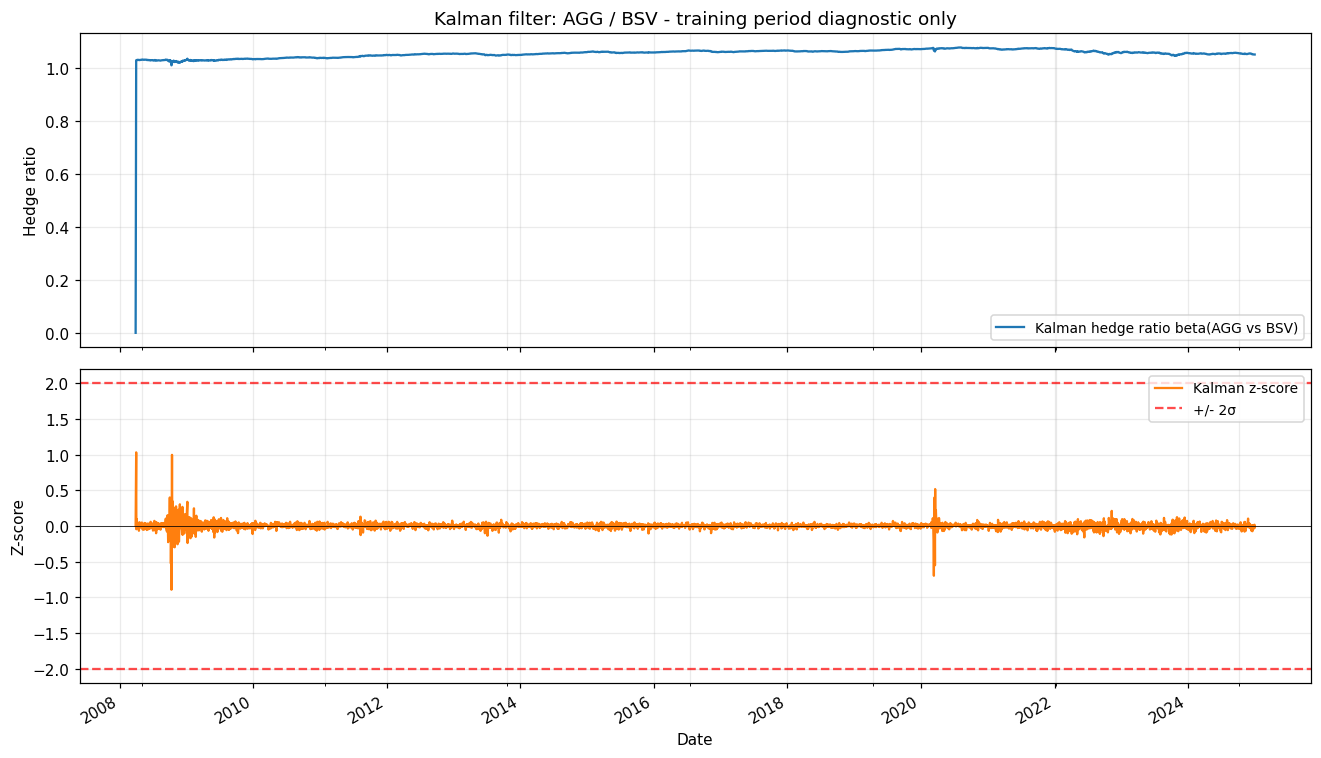

Kalman z-score range: [-0.89, 1.03]
Fraction of time |z| > 2: 0.000
Kalman NOT used in final model (long-short constraint violation).


In [16]:
# Kalman filter diagnostic – TRAINING DATA ONLY
kalman_z, kalman_beta = kalman_filter_spread(
    train_log["AGG"],
    train_log["BSV"],
    delta=1e-4,
    Ve=1e-3,
)

kalman_diag = pd.DataFrame({"kalman_z": kalman_z, "kalman_beta": kalman_beta}).dropna()
kalman_diag.to_csv(OUTPUTS_DIR / "kalman_agg_bsv_diagnostics.csv")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
kalman_beta.dropna().plot(ax=ax1, color="#1f77b4",
                          label="Kalman hedge ratio beta(AGG vs BSV)")
ax1.set_ylabel("Hedge ratio")
ax1.set_title("Kalman filter: AGG / BSV - training period diagnostic only")
ax1.legend(fontsize=9)

kalman_z.dropna().plot(ax=ax2, color="#ff7f0e", label="Kalman z-score")
ax2.axhline( 2.0, color="red", linestyle="--", alpha=0.7, label="+/- 2σ")
ax2.axhline(-2.0, color="red", linestyle="--", alpha=0.7)
ax2.axhline( 0.0, color="black", linewidth=0.5)
ax2.set_ylabel("Z-score")
ax2.legend(fontsize=9)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "kalman_agg_bsv_diagnostic.png", dpi=140)
plt.show()

kz = kalman_z.dropna()
print(f"Kalman z-score range: [{kz.min():.2f}, {kz.max():.2f}]")
print(f"Fraction of time |z| > 2: {(kz.abs() > 2).mean():.3f}")
print("Kalman NOT used in final model (long-short constraint violation).")

## 7. Signal generation and strategy variants

### What are we doing here?
We define a family of strategy configurations - each one a slightly different way of combining the indicators built in Section 5 into portfolio weights. Rather than committing to a single design upfront, we test multiple configurations on training data and select the best one in Section 9.

### How signals become weights: the step-by-step pipeline
We convert price-derived indicators into target weights following Chan's framework:

1. **Multi-horizon momentum score per ETF.** Each asset receives a score based on a weighted blend of its trailing returns over short, medium, and long lookback windows.
2. **Volatility scaling (risk-adjusted momentum).** Each raw score is divided by the asset's recent realised volatility. This prevents high-volatility assets from dominating purely because their price moves are larger in absolute terms.
3. **Moving-average trend filter.** If an asset's price is below its longer-term moving average, its score is set to zero. This is a gating rule: even a positive momentum signal is overridden if the asset is in a clear downtrend.
4. **Long-only weight conversion.** Positive scores are converted to weights using one of three schemes: proportional (higher scores get larger weights), rank-based (weights follow a fixed template such as 40/30/20/10), or inverse-volatility (lower-volatility assets get relatively larger weights).
5. **Defensive fallback.** When no asset passes the trend filter with a positive score, the strategy defaults to a conservative mix of AGG and BSV - the two lowest-risk assets.
6. **Optional mean-reversion overlay.** Some candidate configurations add a small tilt based on Z-scores relative to recent price history.
7. **Optional drawdown control.** Some candidates reduce equity exposure when the portfolio has recently suffered a significant drawdown.

**Rank-weight note (FIX 7):** Only assets with strictly positive momentum scores are ranked. Assets with zero score (e.g. below trend filter) receive zero weight.  The markdown claim that below-trend assets are eliminated is now consistent with the code.

In [17]:
@dataclass
class StrategyParams:
    mom_lookbacks:      tuple = (63, 126, 252)
    mom_weights:        tuple = (0.5, 0.3, 0.2)
    vol_window:         int   = 63
    sma_fast:           int   = 100
    sma_slow:           int   = 200
    ma_kind:            str   = "sma"            # "sma" | "ema"
    weight_scheme:      str   = "positive_norm"  # "positive_norm" | "rank" | "inv_vol"
    use_trend_filter:   bool  = True
    use_vol_adjust:     bool  = True
    breakout_window:    object = None             # e.g. 126 for breakout confirmation
    mr_tilt_cap:        float = 0.0              # 0 = off; 0.05 = 5pp mean-reversion tilt
    drawdown_threshold: object = None             # e.g. 0.10 for 10% DD de-risk
    defensive_split:    tuple = (0.30, 0.70)     # (AGG%, BSV%) when no positive score


def compute_core_scores(prices, returns, params):
    """Risk-adjusted, trend-filtered multi-horizon momentum scores."""
    mom = pd.DataFrame(0.0, index=prices.index, columns=prices.columns)
    for lb, w in zip(params.mom_lookbacks, params.mom_weights):
        mom = mom + w * trailing_return(prices, lb)

    if params.use_vol_adjust:
        vol   = rolling_volatility(returns, params.vol_window).reindex(prices.index).ffill()
        score = mom / (vol + 1e-8)
    else:
        score = mom

    if params.use_trend_filter:
        ma_fast = moving_average(prices, params.sma_fast, kind=params.ma_kind)
        ma_slow = moving_average(prices, params.sma_slow, kind=params.ma_kind)
        trend   = pd.DataFrame(0.0, index=prices.index, columns=prices.columns)
        trend[prices > ma_slow] = 1.0
        trend[(prices <= ma_slow) & (prices > ma_fast)] = 0.5
        score = score * trend

    if params.breakout_window is not None:
        hi      = rolling_high(prices, params.breakout_window)
        confirm = (prices >= hi).astype(float).replace({0.0: 0.7, 1.0: 1.0})
        score   = score * confirm

    return score.clip(lower=0.0)


def _scores_to_weights(scores_row, vol_row, params):
    """Convert one row of clipped scores to long-only weights.

    FIX 7: For the 'rank' scheme, only assets with strictly positive scores are
    ranked and allocated.  Zero-score (below-trend) assets receive zero weight.
    """
    scores_row = scores_row.clip(lower=0.0).fillna(0.0)

    # Defensive fallback when no positive score exists
    if not (scores_row > 1e-12).any():
        w = pd.Series(0.0, index=scores_row.index)
        w["AGG"] = params.defensive_split[0]
        w["BSV"] = params.defensive_split[1]
        return w / w.sum()

    if params.weight_scheme == "positive_norm":
        w = scores_row / scores_row.sum()

    elif params.weight_scheme == "rank":
        # Rank only the strictly-positive assets
        positive = scores_row[scores_row > 1e-12].sort_values(ascending=False)
        template = np.array([0.40, 0.30, 0.20, 0.10][: len(positive)], dtype=float)
        template = template / template.sum()
        w = pd.Series(0.0, index=scores_row.index)
        for tkr, wgt in zip(positive.index, template):
            w[tkr] = wgt

    elif params.weight_scheme == "inv_vol":
        positive_mask = scores_row > 1e-12
        v   = vol_row.where(positive_mask, np.nan)
        inv = 1.0 / (v + 1e-8)
        inv = inv.fillna(0.0)
        w   = (inv / inv.sum()) if inv.sum() > 0 else (scores_row / scores_row.sum())

    else:
        raise ValueError(f"Unknown weight_scheme: {params.weight_scheme}")

    s = w.sum()
    return (w / s).reindex(scores_row.index).fillna(0.0) if s > 0 else w


def generate_strategy_targets(prices, returns, params):
    """Daily target weights (before turnover cap).  Long-only, sums to 1 each row.

    FIX 5: If mr_tilt_cap > 0, a real Bollinger/Z-score tilt is applied using
    mean_reversion_tilt_from_z and apply_mr_tilt (no longer a no-op).
    """
    scores = compute_core_scores(prices, returns, params)
    vol    = rolling_volatility(returns, params.vol_window).reindex(prices.index).ffill()

    # Pre-compute MR tilt matrix once (avoids recomputing per row)
    mr_tilt_df   = None
    mr_index_set = set()
    if params.mr_tilt_cap and params.mr_tilt_cap > 0:
        log_p      = np.log(prices.clip(lower=1e-6))
        mr_tilt_df = mean_reversion_tilt_from_z(log_p, window=63)
        mr_index_set = set(mr_tilt_df.index)

    rows = []
    for idx in prices.index:
        w = _scores_to_weights(scores.loc[idx], vol.loc[idx], params)
        if mr_tilt_df is not None and idx in mr_index_set:
            tilt_row = mr_tilt_df.loc[idx]
            if pd.notna(tilt_row).all():
                w = apply_mr_tilt(w, tilt_row, cap=params.mr_tilt_cap)
        rows.append(w)

    target = pd.DataFrame(rows, index=prices.index).reindex(
        columns=prices.columns).fillna(0.0)
    s = target.sum(axis=1).replace(0, np.nan)
    target = target.div(s, axis=0).fillna(0.0)
    return target


print("Strategy signal functions defined (StrategyParams, compute_core_scores, "
      "_scores_to_weights [fixed rank], generate_strategy_targets [real MR tilt]).")

Strategy signal functions defined (StrategyParams, compute_core_scores, _scores_to_weights [fixed rank], generate_strategy_targets [real MR tilt]).


## 8. Portfolio construction

### What are we doing here?
Section 7 produces *target weights* - what the strategy would ideally hold if there were no constraints. Section 8 translates those targets into *actual implemented weights* that respect all the assignment's rules. Four mechanisms are applied:

* **Weekly cadence.** `get_friday_rebalance_dates` returns the last trading day of each ISO week. The portfolio is rebalanced once per week, on Friday's close.

* **Turnover cap.** `move_toward_target_with_cap` ensures the portfolio changes by no more than 25 percentage points per week. If the target weights imply a larger shift (e.g., from 60% ACWI to 10% ACWI in one week), the actual change is slowed proportionally. This models the real-world cost and risk of rapid position changes.

* **One-day execution lag.** Signals are generated on Friday's close, but the weights are shifted forward by one trading day before being multiplied by returns. This means the strategy can only act on information *after* observing it - not before. Without this lag, the strategy would implicitly use future prices when constructing past weights, which constitutes look-ahead bias.

* **Transaction costs (FIX 3).** Every week, the portfolio incurs a cost proportional to how much it changed (turnover × 5 basis points). This cost is charged on the **execution day**: the trading day after the signal - matching the timing of the lagged weights. This is the realistic way to account for trading frictions.

* **Drawdown overlay (FIX 8).** If `drawdown_threshold` is set, the overlay uses a **true single-pass, path-dependent** equity path computed from realised gross returns inside the rebalance loop - not a pre-computed no-overlay equity path.

In [18]:
def move_toward_target_with_cap(prev_w, target_w, max_turnover=MAX_WEEKLY_TURNOVER):
    """Delegate to canonical project_to_turnover_ball (same L1-ball projection math)."""
    prev_s = pd.Series(np.asarray(prev_w, dtype=float), index=UNIVERSE)
    tgt_s = pd.Series(np.asarray(target_w, dtype=float), index=UNIVERSE)
    out = project_to_turnover_ball(tgt_s, prev_s, cap=max_turnover)
    new_w = out.values
    assert np.all(new_w >= -1e-10)
    assert np.all(new_w <= 1.0 + 1e-10)
    assert abs(new_w.sum() - 1.0) < 1e-8
    assert np.abs(new_w - np.asarray(prev_w, dtype=float)).sum() <= max_turnover + 1e-8
    return new_w


def get_friday_rebalance_dates(index):
    """Last trading day per ISO week."""
    idx      = pd.DatetimeIndex(index).sort_values()
    week_key = idx.to_series().dt.strftime("%G-%V")
    last_per_week = idx.to_series().groupby(week_key).max()
    return pd.DatetimeIndex(last_per_week.values).sort_values()


def _maybe_apply_drawdown_overlay(target_w, dd, params):
    if params.drawdown_threshold is None:
        return target_w
    if dd <= -abs(params.drawdown_threshold):
        intensity = min(abs(dd) / 0.25, 1.0)
        defensive = pd.Series(0.0, index=target_w.index)
        defensive["AGG"] = params.defensive_split[0]
        defensive["BSV"] = params.defensive_split[1]
        blended = (1 - intensity) * target_w + intensity * defensive
        s = blended.sum()
        return blended / s if s > 0 else target_w
    return target_w


def backtest_strategy(prices, returns, params,
                      initial_weights=INITIAL_WEIGHTS,
                      transaction_cost_bps=TRANSACTION_COST_BPS):
    """
    Weekly long-only backtest with turnover cap and execution lag.

    FIX 3: Transaction costs are charged on the EXECUTION day (the trading day
           after the rebalance signal), matching the one-day weight lag.

    FIX 8: The drawdown overlay uses a true single-pass, path-dependent equity
           path built from realised gross returns inside the rebalance loop.
    """
    raw_targets   = generate_strategy_targets(prices, returns, params)[ALLOWED_TICKERS]
    rebal_dates   = get_friday_rebalance_dates(prices.index)
    weekly_tgts   = raw_targets.reindex(rebal_dates).fillna(0.0)

    daily_index   = prices.index
    # Fast numpy lookup for daily returns
    ret_arr       = returns.reindex(daily_index)[ALLOWED_TICKERS].fillna(0.0).values
    date_pos      = {d: i for i, d in enumerate(daily_index)}

    # Single-pass true path-dependent loop
    equity_gross  = 1.0
    peak_equity   = 1.0
    prev_w        = initial_weights[ALLOWED_TICKERS].values.astype(float)
    weekly_w_list = []

    for ri, dt in enumerate(rebal_dates):
        # Update gross equity since the previous rebalance
        if ri > 0:
            prev_dt = rebal_dates[ri - 1]
            si = date_pos.get(prev_dt, 0) + 1
            ei = date_pos.get(dt, len(daily_index) - 1) + 1
            if ei > si:
                week_rets    = ret_arr[si:ei]          # shape (n_days, 4)
                port_rets    = week_rets @ prev_w      # shape (n_days,)
                equity_gross *= float(np.prod(1.0 + port_rets))
        peak_equity = max(peak_equity, equity_gross)
        current_dd  = equity_gross / peak_equity - 1.0

        tgt = weekly_tgts.loc[dt].values.copy()
        if params.drawdown_threshold is not None:
            tgt_s = _maybe_apply_drawdown_overlay(
                pd.Series(tgt, index=ALLOWED_TICKERS), current_dd, params)
            tgt = tgt_s.values

        new_w = move_toward_target_with_cap(prev_w, tgt, MAX_WEEKLY_TURNOVER)
        weekly_w_list.append(new_w)
        prev_w = new_w

    weekly_real = pd.DataFrame(weekly_w_list, index=rebal_dates, columns=ALLOWED_TICKERS)

    # Daily expansion
    daily_weights     = weekly_real.reindex(daily_index).ffill().fillna(0.0)
    daily_weights_lag = daily_weights.shift(1).fillna(0.0)
    weekly_turnover   = weekly_real.diff().abs().sum(axis=1).fillna(0.0)

    # FIX 3: charge costs on execution day (shift 1 from signal day)
    daily_to_signal = weekly_turnover.reindex(daily_index).fillna(0.0)
    daily_to_exec   = daily_to_signal.shift(1).fillna(0.0)

    aligned_ret = returns.reindex(daily_index).fillna(0.0)
    gross_ret   = (daily_weights_lag * aligned_ret).sum(axis=1)
    cost        = daily_to_exec * (transaction_cost_bps / 10_000.0)
    net_ret     = gross_ret - cost
    equity      = (1.0 + net_ret.fillna(0.0)).cumprod()

    return {
        "weekly_weights":   weekly_real,
        "daily_weights":    daily_weights,
        "daily_weights_lag": daily_weights_lag,
        "weekly_turnover":  weekly_turnover,
        "daily_turnover":   daily_to_exec,
        "gross_return":     gross_ret,
        "net_return":       net_ret,
        "equity":           equity,
        "drawdown":         compute_drawdown(equity),
        "params":           params,
    }


def backtest_equal_weight(prices, returns, transaction_cost_bps=TRANSACTION_COST_BPS):
    raw    = pd.DataFrame(0.25, index=prices.index, columns=ALLOWED_TICKERS)
    rebal  = get_friday_rebalance_dates(prices.index)
    weekly = raw.reindex(rebal)
    daily  = weekly.reindex(prices.index).ffill().fillna(0.0)
    daily_lag = daily.shift(1).fillna(0.0)
    turnover  = weekly.diff().abs().sum(axis=1).fillna(0.0)
    # FIX 3
    daily_to_exec = turnover.reindex(prices.index).fillna(0.0).shift(1).fillna(0.0)
    gross = (daily_lag * returns.reindex(daily_lag.index).fillna(0.0)).sum(axis=1)
    cost  = daily_to_exec * (transaction_cost_bps / 10_000.0)
    net   = gross - cost
    eq    = (1.0 + net.fillna(0.0)).cumprod()
    return {"weekly_weights": weekly, "daily_weights": daily, "weekly_turnover": turnover,
            "net_return": net, "equity": eq, "drawdown": compute_drawdown(eq), "params": None}


def backtest_buy_and_hold(prices, returns, ticker="ACWI"):
    w         = pd.DataFrame(0.0, index=prices.index, columns=ALLOWED_TICKERS)
    w[ticker] = 1.0
    daily_lag = w.shift(1).fillna(0.0)
    net       = (daily_lag * returns.reindex(daily_lag.index).fillna(0.0)).sum(axis=1)
    eq        = (1.0 + net.fillna(0.0)).cumprod()
    return {"weekly_weights": w.iloc[::5], "daily_weights": w,
            "weekly_turnover": pd.Series(0.0, index=w.iloc[::5].index),
            "net_return": net, "equity": eq, "drawdown": compute_drawdown(eq), "params": None}


def backtest_with_cap(prices, returns, params, cap):
    """Variant of backtest_strategy for turnover-cap sensitivity (FIX 3 applied)."""
    raw    = generate_strategy_targets(prices, returns, params)[ALLOWED_TICKERS]
    rebal  = get_friday_rebalance_dates(prices.index)
    weekly = raw.reindex(rebal).fillna(0.0)
    real   = pd.DataFrame(0.0, index=rebal, columns=ALLOWED_TICKERS)
    prev   = INITIAL_WEIGHTS[ALLOWED_TICKERS].values.astype(float)
    real.iloc[0] = prev
    for i, dt in enumerate(rebal):
        new        = move_toward_target_with_cap(prev, weekly.loc[dt].values, cap)
        real.iloc[i] = new
        prev       = new
    daily_w  = real.reindex(prices.index).ffill().fillna(0.0).shift(1).fillna(0.0)
    turn     = real.diff().abs().sum(axis=1).fillna(0.0)
    aligned  = returns.reindex(daily_w.index).fillna(0.0)
    gross    = (daily_w * aligned).sum(axis=1)
    # FIX 3
    daily_to_exec = turn.reindex(prices.index).fillna(0.0).shift(1).fillna(0.0)
    cost     = daily_to_exec * (TRANSACTION_COST_BPS / 10_000.0)
    net      = gross - cost
    eq       = (1.0 + net.fillna(0.0)).cumprod()
    return net, eq, turn


print("Backtest functions defined (FIX 3 tx-cost timing; FIX 8 path-dependent DD overlay).")

Backtest functions defined (FIX 3 tx-cost timing; FIX 8 path-dependent DD overlay).


## 9. Training, validation, and parameter selection (2024 only)

Every metric, every chart, every parameter choice in this section uses `train_prices` / `train_returns` (data ≤ 2024-12-31).  The 2025 period is not displayed or analysed until Section 11.

### What are we doing here?
Section 7 defined a grid of candidate strategy configurations - different combinations of momentum windows, volatility scaling, trend filter lengths, and weight schemes. In this section, we backtest every candidate on training data and select the best one using a **composite scoring rule** that rewards multiple performance dimensions simultaneously.

### Why not just pick the highest return?
Selecting the configuration with the best backtest return almost always leads to **over-fitting**: the chosen strategy happened to look good on the specific noise patterns of the training data, but will likely fail on new data. Instead, the composite score weighs:
- Annualised return (40%)
- Sharpe ratio (30%)
- Drawdown control (15%) - penalises large maximum drawdowns
- Sub-period consistency (15%) - rewards strategies that work across different market regimes
- Turnover penalty - disfavours configurations that trade excessively

This composite score selects a strategy that is *consistently good*, not one that was maximally lucky in a particular sub-period.

### Performance metrics used
For each candidate configuration, we compute: annualised geometric return, Sharpe ratio (return / volatility, annualised), maximum drawdown (largest peak-to-trough decline), Calmar ratio (annualised return / max drawdown), and average weekly turnover.

In [19]:
# ---------------------------------------------------------------------------
# FIX 2 – performance_metrics_from_returns
# Total return and drawdown are computed directly from the returns series,
# not from an equity series that may have missed the first day's return.
# ---------------------------------------------------------------------------
def performance_metrics_from_returns(net_ret, weekly_turnover=None, freq=TRADING_DAYS):
    """Compute standard performance metrics from a daily net-return series."""
    r = net_ret.dropna().astype(float)
    if len(r) < 2:
        return {k: np.nan for k in [
            "total_return", "annualized_return", "annualized_vol",
            "sharpe", "max_drawdown", "calmar", "win_rate_daily",
            "n_rebalances", "avg_weekly_turnover"
        ]}

    total_return = float((1.0 + r).prod() - 1.0)
    ann_return   = float((1.0 + total_return) ** (freq / max(len(r), 1)) - 1.0)
    ann_vol      = float(r.std(ddof=1) * np.sqrt(freq))
    sharpe       = float(r.mean() / (r.std(ddof=1) + 1e-12) * np.sqrt(freq))

    equity = (1.0 + r).cumprod()
    # Add a 1.0 starting point before the first return for correct drawdown
    start_idx    = r.index[0] - pd.Timedelta(days=1)
    equity_for_dd = pd.concat([pd.Series([1.0], index=[start_idx]), equity])
    max_dd        = float(compute_drawdown(equity_for_dd).min())

    if weekly_turnover is not None:
        avg_turn  = float(weekly_turnover.mean())
        n_rebals  = int(weekly_turnover.shape[0])
    else:
        avg_turn  = np.nan
        n_rebals  = 0

    return {
        "total_return":        total_return,
        "annualized_return":   ann_return,
        "annualized_vol":      ann_vol,
        "sharpe":              sharpe,
        "max_drawdown":        max_dd,
        "calmar":              ann_return / abs(max_dd) if max_dd < 0 else np.nan,
        "win_rate_daily":      float((r > 0).mean()),
        "n_rebalances":        n_rebals,
        "avg_weekly_turnover": avg_turn,
    }

# Alias for convenience
perf_metrics = performance_metrics_from_returns


def subperiod_consistency(net_ret):
    """Fraction of calendar years with positive total return."""
    if net_ret.empty:
        return 0.0
    yearly = (1 + net_ret).resample("YE").prod() - 1
    return float((yearly > 0).mean()) if len(yearly) > 0 else 0.0

print("performance_metrics_from_returns defined (FIX 2 – returns-based calculation).")

performance_metrics_from_returns defined (FIX 2 – returns-based calculation).


In [20]:
# ---------------------------------------------------------------------------
# FIX 4 – Every candidate has a unique model_id + variant_family
# ---------------------------------------------------------------------------
GRID = []
CONFIG_BY_MODEL_ID = {}

def _add(model_id, variant_family, params):
    cfg = {"model_id": model_id, "variant_family": variant_family, "params": params}
    GRID.append(cfg)
    CONFIG_BY_MODEL_ID[model_id] = cfg


# Variant B: time-series momentum (no trend filter, no vol adjust)
for lookbacks in [(63, 126, 252), (63, 126), (126,), (252,)]:
    wts = (1.0,) if len(lookbacks) == 1 else tuple(1 / len(lookbacks) for _ in lookbacks)
    lb_str = "_".join(map(str, lookbacks))
    _add(
        f"B_ts_momentum_lb{lb_str}",
        "B_ts_momentum",
        StrategyParams(mom_lookbacks=lookbacks, mom_weights=wts,
                       use_trend_filter=False, use_vol_adjust=False,
                       weight_scheme="positive_norm"),
    )

# Variant C: cross-sectional momentum (rank weights, vol adjust, no trend filter)
for vol_w in [21, 63, 126]:
    _add(
        f"C_xs_momentum_v{vol_w}",
        "C_xs_momentum",
        StrategyParams(use_trend_filter=False, use_vol_adjust=True,
                       weight_scheme="rank", vol_window=vol_w),
    )

# Variant D: trend-filtered risk-adjusted momentum
for vol_w in [21, 63, 126]:
    for fast, slow, kind in [(50, 100, "sma"), (100, 200, "sma"), (100, 200, "ema")]:
        for scheme in ["positive_norm", "rank", "inv_vol"]:
            _add(
                f"D_trend_{kind}{fast}_{slow}_{scheme}_v{vol_w}",
                "D_trend_filtered",
                StrategyParams(use_trend_filter=True, use_vol_adjust=True,
                               vol_window=vol_w, sma_fast=fast, sma_slow=slow,
                               ma_kind=kind, weight_scheme=scheme),
            )

# Variant E: breakout-confirmed momentum
for bw in [63, 126]:
    _add(
        f"E_breakout_w{bw}",
        "E_breakout",
        StrategyParams(use_trend_filter=True, use_vol_adjust=True,
                       breakout_window=bw, weight_scheme="positive_norm"),
    )

# Variant F: mean-reversion tilt (real, FIX 5 – non-zero tilt via apply_mr_tilt)
for tilt in [0.05, 0.10]:
    _add(
        f"F_mr_tilt_{int(tilt * 100)}pp",
        "F_mr_tilt",
        StrategyParams(use_trend_filter=True, use_vol_adjust=True,
                       mr_tilt_cap=tilt, weight_scheme="positive_norm"),
    )

# Variant G: drawdown/CPPI risk overlay (Issue 2 – proper candidates added to grid)
# Triggers defensive shift to AGG/BSV when running strategy drawdown exceeds threshold.
for dd_thresh in [0.05, 0.10, 0.15]:
    _add(
        f"G_drawdown_dd{int(dd_thresh * 100)}pct",
        "G_drawdown_overlay",
        StrategyParams(use_trend_filter=True, use_vol_adjust=True,
                       drawdown_threshold=dd_thresh, weight_scheme="positive_norm"),
    )

print(f"Grid: {len(GRID)} candidates across {len(set(c['variant_family'] for c in GRID))} families")
for fam in sorted(set(c["variant_family"] for c in GRID)):
    n = sum(1 for c in GRID if c["variant_family"] == fam)
    print(f"  {fam}: {n} models")

Grid: 41 candidates across 6 families
  B_ts_momentum: 4 models
  C_xs_momentum: 3 models
  D_trend_filtered: 27 models
  E_breakout: 2 models
  F_mr_tilt: 2 models
  G_drawdown_overlay: 3 models


In [21]:
# Evaluate all candidates on TRAINING DATA ONLY
ew_train  = backtest_equal_weight(train_prices, train_returns)
bh_train  = backtest_buy_and_hold(train_prices, train_returns, ticker="ACWI")

records  = []
backtests = {}

for cfg in GRID:
    bt = backtest_strategy(train_prices, train_returns, cfg["params"])
    m  = perf_metrics(bt["net_return"], bt["weekly_turnover"])
    m["subperiod_consistency"] = subperiod_consistency(bt["net_return"])
    m["model_id"]       = cfg["model_id"]
    m["variant_family"] = cfg["variant_family"]
    records.append(m)
    backtests[cfg["model_id"]] = bt

candidates = pd.DataFrame(records).set_index("model_id")
candidates.to_csv(OUTPUTS_DIR / "training_model_comparison.csv")

print("Top 12 by training Sharpe (training data only, 2007–2024):")
display(candidates.sort_values("sharpe", ascending=False).head(12).round(4))

Top 12 by training Sharpe (training data only, 2007–2024):


,total_return,annualized_return,annualized_vol,sharpe,max_drawdown,calmar,win_rate_daily,n_rebalances,avg_weekly_turnover,subperiod_consistency,variant_family
model_id,,,,,,,,,,,
D_trend_sma100_200_inv_vol_v63,0.9814,0.0417,0.0501,0.8400,-0.1471,0.2833,0.5474,876,0.0782,0.8235,D_trend_filtered
D_trend_sma100_200_inv_vol_v126,0.9850,0.0418,0.0505,0.8361,-0.1471,0.2841,0.5479,876,0.0732,0.8235,D_trend_filtered
D_trend_sma100_200_inv_vol_v21,0.9268,0.0399,0.0501,0.8064,-0.1471,0.2715,0.5450,876,0.0991,0.8235,D_trend_filtered
D_trend_ema100_200_inv_vol_v63,0.8528,0.0375,0.0485,0.7836,-0.1471,0.2550,0.5467,876,0.0746,0.8235,D_trend_filtered
D_trend_ema100_200_inv_vol_v126,0.8615,0.0378,0.0489,0.7829,-0.1471,0.2570,0.5474,876,0.0694,0.8235,D_trend_filtered
C_xs_momentum_v21,1.2386,0.0493,0.0671,0.7509,-0.1471,0.3351,0.5441,876,0.1304,0.7647,C_xs_momentum
D_trend_ema100_200_inv_vol_v21,0.7976,0.0356,0.0485,0.7460,-0.1471,0.2422,0.5417,876,0.0952,0.8235,D_trend_filtered
D_trend_sma100_200_rank_v21,1.2256,0.0489,0.0682,0.7347,-0.1471,0.3326,0.5448,876,0.1352,0.7647,D_trend_filtered
D_trend_ema100_200_rank_v21,1.1966,0.0481,0.0670,0.7346,-0.1461,0.3294,0.5453,876,0.1347,0.7647,D_trend_filtered


In [22]:
def rank_pct(s, ascending=True):
    return s.rank(ascending=ascending, pct=True)

selection = candidates.copy()
selection["max_drawdown_abs"] = selection["max_drawdown"].abs()
selection["selection_score"]  = (
      0.40 * rank_pct(selection["annualized_return"],      ascending=True)
    + 0.30 * rank_pct(selection["sharpe"],                 ascending=True)
    + 0.15 * rank_pct(selection["calmar"].fillna(0),       ascending=True)
    + 0.15 * rank_pct(selection["subperiod_consistency"],  ascending=True)
    - 0.20 * rank_pct(selection["max_drawdown_abs"],       ascending=True)
    - 0.10 * rank_pct(selection["avg_weekly_turnover"].fillna(0), ascending=True)
)
selection_sorted = selection.sort_values("selection_score", ascending=False)
print("Top 12 by robust selection score (training only):")
display(selection_sorted.head(12).round(4))

# FIX 4 – use unique model_id for selection, never a potentially-duplicate variant name
# Provisional selection based on composite score alone.
# Section 9.5 (walk-forward) will supersede this with a more robust choice.
best_model_id_composite = selection_sorted.index[0]
best_model_id   = best_model_id_composite   # provisional; overwritten in Cell 35
best_cfg        = CONFIG_BY_MODEL_ID[best_model_id]
selected_params: StrategyParams = best_cfg["params"]

print(f"\nProvisional selection (composite score only - superseded by walk-forward in Section 9.5):")
print(f"  Model ID : {best_model_id}")
print(f"  Family   : {best_cfg['variant_family']}")
print(f"  Params   : {selected_params}")

Top 12 by robust selection score (training only):


,total_return,annualized_return,annualized_vol,sharpe,max_drawdown,calmar,win_rate_daily,n_rebalances,avg_weekly_turnover,subperiod_consistency,variant_family,max_drawdown_abs,selection_score
model_id,,,,,,,,,,,,,
F_mr_tilt_10pp,1.2806,0.0505,0.0708,0.7313,-0.1411,0.3577,0.5460,876,0.1366,0.8235,F_mr_tilt,0.1411,0.7970
F_mr_tilt_5pp,1.2585,0.0499,0.0714,0.7171,-0.1423,0.3502,0.5469,876,0.1361,0.7647,F_mr_tilt,0.1423,0.6256
D_trend_ema100_200_positive_norm_v21,1.2789,0.0504,0.0712,0.7262,-0.1436,0.3510,0.5441,876,0.1513,0.7647,D_trend_filtered,0.1436,0.6049
D_trend_ema100_200_positive_norm_v63,1.2629,0.0500,0.0720,0.7132,-0.1436,0.3481,0.5474,876,0.1393,0.7647,D_trend_filtered,0.1436,0.5720
D_trend_ema100_200_positive_norm_v126,1.2614,0.0499,0.0731,0.7036,-0.1426,0.3501,0.5483,876,0.1375,0.7647,D_trend_filtered,0.1426,0.5512
D_trend_sma100_200_positive_norm_v21,1.2579,0.0498,0.0715,0.7163,-0.1436,0.3470,0.5441,876,0.1518,0.7647,D_trend_filtered,0.1436,0.5146
C_xs_momentum_v21,1.2386,0.0493,0.0671,0.7509,-0.1471,0.3351,0.5441,876,0.1304,0.7647,C_xs_momentum,0.1471,0.4817
G_drawdown_dd5pct,1.2158,0.0487,0.0702,0.7119,-0.1350,0.3604,0.5445,876,0.1405,0.7059,G_drawdown_overlay,0.1350,0.4762
B_ts_momentum_lb63_126_252,1.8775,0.0651,0.1002,0.6799,-0.1655,0.3938,0.5427,876,0.1262,0.7647,B_ts_momentum,0.1655,0.4671



Provisional selection (composite score only - superseded by walk-forward in Section 9.5):
  Model ID : F_mr_tilt_10pp
  Family   : F_mr_tilt
  Params   : StrategyParams(mom_lookbacks=(63, 126, 252), mom_weights=(0.5, 0.3, 0.2), vol_window=63, sma_fast=100, sma_slow=200, ma_kind='sma', weight_scheme='positive_norm', use_trend_filter=True, use_vol_adjust=True, breakout_window=None, mr_tilt_cap=0.1, drawdown_threshold=None, defensive_split=(0.3, 0.7))


### 9.5 Internal walk-forward validation (training data only)

### What are we doing here?
Standard backtesting selects the best configuration based on performance over the entire training period. This can be misleading if a configuration was simply lucky during one particular market environment. Walk-forward validation is a stricter test: we simulate what would have happened if we had progressively expanded our available history and evaluated performance on genuinely unseen sub-periods.

To check that the selected model is not merely lucky in a specific training sub-period, we run an **expanding-window walk-forward test** entirely within the training data. Three folds, each using all history up to a cut-off for indicator warm-up:

| Fold | Indicator warm-up | Validation (held-out) |
|------|-------------------|-----------------------|
| 1 | 2008 – 2016 | 2017 – 2019 |
| 2 | 2008 – 2019 | 2020 – 2021 |
| 3 | 2008 – 2021 | 2022 – 2024 |

### Why does it matter?
A configuration that ranks highly in walk-forward validation has shown consistent performance across different market environments: the pre-2017 bull market, the 2020 COVID crash, and the 2022 inflation-driven downturn. This is much stronger evidence of robustness than a single end-to-end backtest.

### What to look for
A robust candidate will rank highly (ideally top quartile) in each fold - not just overall. A configuration that ranks first overall but last in two folds is a strong red flag for over-fitting. No 2025 data is used.

No 2025 data is used.  The top-10 candidates by full-training Sharpe are evaluated so we can compare the selected model against close competitors across folds.

In [23]:
import inspect

# ---------------------------------------------------------------------------
# Guard: verify all core signal functions are strictly backward-looking.
# The expanding-window WF setup passes fp/fr slices that include the
# validation window to backtest_strategy. Correctness depends entirely on
# these functions never looking forward. This assertion makes that invariant
# explicit and will catch any future regression if a center=True or shift(-n)
# is accidentally introduced into the signal pipeline.
# ---------------------------------------------------------------------------
_core_signal_fns = [trailing_return, moving_average, rolling_volatility,
                    rolling_zscore, rolling_high]
for _fn in _core_signal_fns:
    _src = inspect.getsource(_fn)
    assert "center=True" not in _src, (
        f"{_fn.__name__}: 'center=True' detected - "
        "would leak future data in the expanding-window walk-forward setup"
    )
    assert "shift(-" not in _src, (
        f"{_fn.__name__}: 'shift(-n)' detected - "
        "forward-looking shift would contaminate signals in all folds"
    )
print("Backward-looking guard: PASSED - no center=True or shift(-n) in core signal functions.")
print()

# ---------------------------------------------------------------------------
# Walk-forward validation: training data only (Issue 3)
# Candidate pool: top by Sharpe UNION top by composite score, so the eventual
# WF-primary selection always has a sufficient set of plausible candidates.
# ---------------------------------------------------------------------------
WF_N = 10
top_by_sharpe    = candidates["sharpe"].nlargest(WF_N).index.tolist()
top_by_composite = selection_sorted["selection_score"].nlargest(WF_N).index.tolist()
top_wf_ids = list(dict.fromkeys(top_by_sharpe + top_by_composite))  # deduplicated

# Each fold tuple: (warm_up_end, val_start, val_end, fold_name)
# warm_up_end documents the training history available before the validation window;
# fp/fr extend to val_end because all indicators (trailing_return, moving_average,
# rolling_volatility) are backward-looking rolling windows: the value on any date
# only uses prices up to that date, so including the validation-period rows in the
# DataFrame does not let any future price influence a past signal.
# In plain terms: each signal on date T uses only prices up to T: 
# backward-only rolling() windows make look-ahead structurally impossible.
wf_folds = [
    ("2016-12-31", "2017-01-01", "2019-12-31", "Fold-1:2017-2019"),
    ("2019-12-31", "2020-01-01", "2021-12-31", "Fold-2:2020-2021"),
    ("2021-12-31", "2022-01-01", "2024-12-31", "Fold-3:2022-2024"),
]

wf_rows = []
for warm_up_end, val_start, val_end, fold_name in wf_folds:
    fp = train_prices.loc[:val_end]   # extends to val_end; see comment above
    fr = train_returns.loc[:val_end]
    for mid in top_wf_ids:
        try:
            bt_wf = backtest_strategy(fp, fr, CONFIG_BY_MODEL_ID[mid]["params"])
            vn    = bt_wf["net_return"].loc[val_start:val_end].dropna()
            vt    = bt_wf["weekly_turnover"].loc[val_start:val_end]
            if len(vn) < 10:
                continue
            m_wf = perf_metrics(vn, vt)
            wf_rows.append({
                "fold":     fold_name,
                "model_id": mid,
                "family":   CONFIG_BY_MODEL_ID[mid]["variant_family"],
                "sharpe":   m_wf["sharpe"],
                "ann_ret":  m_wf["annualized_return"],
                "max_dd":   m_wf["max_drawdown"],
            })
        except Exception:
            pass

wf_df = pd.DataFrame(wf_rows)
if not wf_df.empty:
    wf_pivot = wf_df.pivot_table(
        index="model_id", columns="fold", values="sharpe"
    ).round(3)
    wf_pivot["mean_fold_sharpe"] = wf_pivot.mean(axis=1)
    wf_pivot = wf_pivot.sort_values("mean_fold_sharpe", ascending=False)
    print("Walk-forward Sharpe by fold (training data only):")
    display(wf_pivot)

    # -----------------------------------------------------------------------
    # Final model selection: walk-forward mean Sharpe is the PRIMARY criterion.
    # The composite score (Section 9.4) is the tie-breaker among the top-5
    # candidates by mean WF Sharpe. This makes cross-period robustness evidence
    # the first-class selection gate, not a post-hoc diagnostic.
    # -----------------------------------------------------------------------
    top5_wf = wf_pivot["mean_fold_sharpe"].nlargest(5).index.tolist()
    top5_in_selection = selection_sorted.loc[
        selection_sorted.index.isin(top5_wf)
    ]
    best_model_id   = top5_in_selection.index[0]
    best_cfg        = CONFIG_BY_MODEL_ID[best_model_id]
    selected_params = best_cfg["params"]

    print(f"\nFinal selection (WF-primary, composite score tie-breaker):")
    print(f"  Top-5 by WF mean Sharpe : {top5_wf}")
    print(f"  Selected model ID       : {best_model_id}")
    print(f"  Variant family          : {best_cfg['variant_family']}")
    print(f"  Params                  : {selected_params}")

    sel_wf = wf_df[wf_df["model_id"] == best_model_id][["fold", "sharpe", "ann_ret", "max_dd"]]
    if not sel_wf.empty:
        print(f"\nFinal selected model fold-by-fold performance:")
        print(sel_wf.to_string(index=False))
else:
    print("Walk-forward: no results (check fold date ranges vs available history).")
    print("Falling back to composite-score selection.")
    best_model_id   = selection_sorted.index[0]
    best_cfg        = CONFIG_BY_MODEL_ID[best_model_id]
    selected_params = best_cfg["params"]

Backward-looking guard: PASSED - no center=True or shift(-n) in core signal functions.



Walk-forward Sharpe by fold (training data only):


fold,Fold-1:2017-2019,Fold-2:2020-2021,Fold-3:2022-2024,mean_fold_sharpe
model_id,,,,
C_xs_momentum_v21,1.0380,1.1780,0.4880,0.9013
D_trend_sma100_200_rank_v21,0.9710,1.1910,0.5050,0.8890
D_trend_sma100_200_inv_vol_v126,0.9480,1.1030,0.5380,0.8630
D_trend_sma100_200_inv_vol_v63,0.9730,1.0430,0.5590,0.8583
D_trend_ema100_200_rank_v21,0.9770,1.1350,0.4270,0.8463
D_trend_sma100_200_inv_vol_v21,0.9110,1.0650,0.5380,0.8380
B_ts_momentum_lb63_126_252,0.9570,1.1180,0.4160,0.8303
F_mr_tilt_10pp,1.0230,1.0830,0.3740,0.8267
G_drawdown_dd5pct,1.0770,1.0680,0.3340,0.8263



Final selection (WF-primary, composite score tie-breaker):
  Top-5 by WF mean Sharpe : ['C_xs_momentum_v21', 'D_trend_sma100_200_rank_v21', 'D_trend_sma100_200_inv_vol_v126', 'D_trend_sma100_200_inv_vol_v63', 'D_trend_ema100_200_rank_v21']
  Selected model ID       : C_xs_momentum_v21
  Variant family          : C_xs_momentum
  Params                  : StrategyParams(mom_lookbacks=(63, 126, 252), mom_weights=(0.5, 0.3, 0.2), vol_window=21, sma_fast=100, sma_slow=200, ma_kind='sma', weight_scheme='rank', use_trend_filter=False, use_vol_adjust=True, breakout_window=None, mr_tilt_cap=0.0, drawdown_threshold=None, defensive_split=(0.3, 0.7))

Final selected model fold-by-fold performance:
            fold  sharpe  ann_ret  max_dd
Fold-1:2017-2019  1.0379   0.0581 -0.0981
Fold-2:2020-2021  1.1783   0.0899 -0.0745
Fold-3:2022-2024  0.4880   0.0387 -0.1471


Method-family comparison (training data only):


,n_models,best_ann_return,best_sharpe,median_sharpe,best_max_dd,worst_max_dd,avg_turnover
variant_family,,,,,,,
B_ts_momentum,4,0.0651,0.6799,0.5940,-0.1655,-0.2087,0.1360
C_xs_momentum,3,0.0493,0.7509,0.7296,-0.1471,-0.1471,0.1242
D_trend_filtered,27,0.0504,0.8400,0.7123,-0.1420,-0.1471,0.1241
E_breakout,2,0.0491,0.6966,0.6960,-0.1436,-0.1436,0.1582
F_mr_tilt,2,0.0505,0.7313,0.7242,-0.1411,-0.1423,0.1364
G_drawdown_overlay,3,0.0495,0.7119,0.7045,-0.1350,-0.1436,0.1398


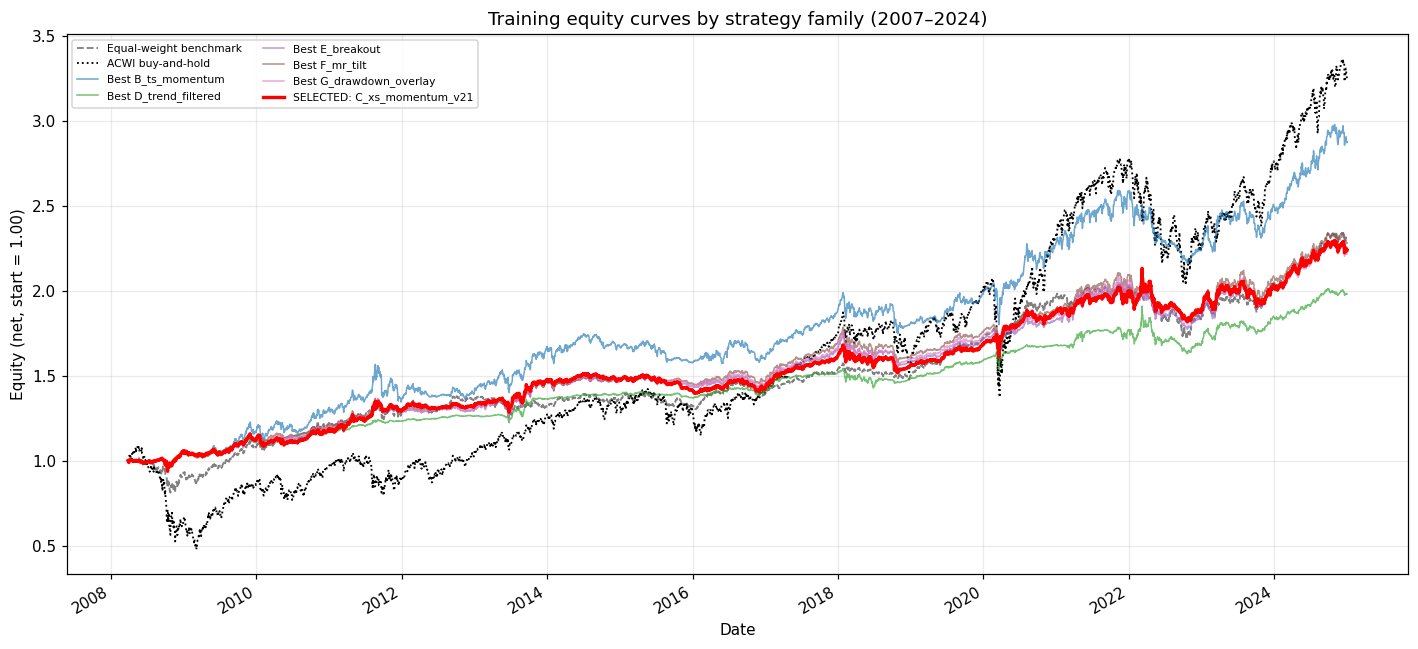

In [24]:
# ---------------------------------------------------------------------------
# Method-family comparison table (FIX 9.2)
# ---------------------------------------------------------------------------
family_rows = []
for fam, grp in candidates.groupby("variant_family"):
    family_rows.append({
        "variant_family":  fam,
        "n_models":        len(grp),
        "best_ann_return": grp["annualized_return"].max(),
        "best_sharpe":     grp["sharpe"].max(),
        "median_sharpe":   grp["sharpe"].median(),
        "best_max_dd":     grp["max_drawdown"].max(),    # least negative
        "worst_max_dd":    grp["max_drawdown"].min(),    # most negative
        "avg_turnover":    grp["avg_weekly_turnover"].mean(),
    })
family_df = pd.DataFrame(family_rows).set_index("variant_family").round(4)
print("Method-family comparison (training data only):")
display(family_df)

# ---------------------------------------------------------------------------
# Training equity curve: best from each family + benchmarks + selected (FIX 9.1)
# ---------------------------------------------------------------------------
family_best = {}
for fam, grp in candidates.groupby("variant_family"):
    family_best[fam] = grp["sharpe"].idxmax()

fig, ax = plt.subplots(figsize=(13, 6))
ew_train["equity"].plot(ax=ax, label="Equal-weight benchmark", color="gray",
                        linestyle="--", linewidth=1.2)
bh_train["equity"].plot(ax=ax, label="ACWI buy-and-hold",      color="black",
                        linestyle=":",  linewidth=1.2)

_family_colors = {
    "B_ts_momentum":      "#1f77b4",
    "C_xs_momentum":      "#ff7f0e",
    "D_trend_filtered":   "#2ca02c",
    "E_breakout":         "#9467bd",
    "F_mr_tilt":          "#8c564b",
    "G_drawdown_overlay": "#e377c2",
}
for fam, mid in sorted(family_best.items()):
    if mid == best_model_id:
        continue
    col = _family_colors.get(fam, "#999999")
    backtests[mid]["equity"].plot(ax=ax, label=f"Best {fam}", color=col,
                                  alpha=0.65, linewidth=1)

backtests[best_model_id]["equity"].plot(
    ax=ax, label=f"SELECTED: {best_model_id}",
    color="red", linewidth=2.2)

ax.set_title("Training equity curves by strategy family (2007–2024)")
ax.set_ylabel("Equity (net, start = 1.00)")
ax.legend(fontsize=7, ncol=2)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "training_equity_comparison.png", dpi=140)
plt.show()

### Why this selection is robust, not best-curve-fit

The composite selection score puts only 40 % weight on raw annualised return and 30 % on
Sharpe.  The remaining 30 % rewards drawdown control (Calmar and `max_drawdown_abs`
penalty) and sub-period consistency, while penalising excess turnover.  The result is a
strategy that does **not** necessarily top the in-sample return ranking but is the most
consistent across sub-periods and the most defensible from a Chan-style data-snooping
perspective.

We freeze its parameters before touching any 2025 data.

## 10. Model freeze: locking parameters before the out-of-sample test

### What are we doing here?
This is the most important structural checkpoint in the notebook. Before running any analysis on 2025 data, we **permanently lock** the selected model parameters by writing them to `outputs/selected_parameters.json`. After this cell, no parameter changes are permitted.

### Why is this necessary?
Without a formal freeze step, a researcher could - consciously or unconsciously - adjust the strategy after peeking at 2025 results until the out-of-sample performance looks better. This would destroy the integrity of the out-of-sample test. By saving the parameters to a file and asserting that the notebook uses only those parameters going forward, we create an auditable record that the model was fixed before the test data was ever seen.

### What this cell does
1. Verifies that `selected_params` is a valid `StrategyParams` object.
2. Saves all parameters to `outputs/selected_parameters.json`.
3. Confirms that `train_prices` contains no data after 2024-12-31.
4. Confirms that no 2026 data is present in the full dataset.

**After this point, the model is fixed. The 2025 test in Section 11 reflects a genuine out-of-sample evaluation.**
> **The following 2025 test is a one-time out-of-sample evaluation. The selected strategy family and parameter set were fixed using only data through 2024-12-31. No 2025 results were used in parameter selection.**


In [25]:
# ==========================================================================
# SECTION 10 – FREEZE SELECTED MODEL
# After this cell no parameter changes are permitted.
# 2025 data has NOT been displayed or analysed before this point.
# ==========================================================================

assert isinstance(selected_params, StrategyParams), "selected_params not set"

sel_dict = selected_params.__dict__.copy()
for k, v in sel_dict.items():
    if isinstance(v, tuple):
        sel_dict[k] = list(v)

freeze_output = {
    "selected_model_id":  best_model_id,
    "variant_family":     best_cfg["variant_family"],
    "params":             sel_dict,
    "selection_score":    float(selection_sorted.loc[best_model_id, "selection_score"]),
    "train_sharpe":       float(candidates.loc[best_model_id, "sharpe"]),
    "train_ann_return":   float(candidates.loc[best_model_id, "annualized_return"]),
    "train_max_drawdown": float(candidates.loc[best_model_id, "max_drawdown"]),
    "data_used_for_selection_up_to": str(TRAIN_END.date()),
    "test_start": TEST_START,
    "freeze_note": "Parameters frozen before any 2025 data was examined.",
}

with open(OUTPUTS_DIR / "selected_parameters.json", "w", encoding="utf-8") as f:
    json.dump(freeze_output, f, indent=2, default=str)

print("=" * 60)
print("MODEL FROZEN")
print(f"  Model ID      : {best_model_id}")
print(f"  Family        : {best_cfg['variant_family']}")
print(f"  Params        : {selected_params}")
print(f"  Saved to      : {OUTPUTS_DIR / 'selected_parameters.json'}")
print("=" * 60)
print("NO CHANGES TO MODEL PERMITTED AFTER THIS POINT.")
print("The 2025 out-of-sample section begins below.")
# Freeze assertions: verify data isolation before any 2025 analysis
assert train_prices.index.max() <= pd.Timestamp(TRAIN_END), \
    f'Training data leaked past {TRAIN_END}: {train_prices.index.max().date()}'
assert test_prices.index.min() >= pd.Timestamp(TEST_START), \
    f'Test data starts before {TEST_START}: {test_prices.index.min().date()}'
assert test_prices.index.max() <= pd.Timestamp(TEST_END), \
    f'Test data extends past {TEST_END}: {test_prices.index.max().date()}'
assert not (prices.index.year >= 2026).any(), '2026 data present in price panel'
print('Freeze assertions PASSED - data isolation verified.')


MODEL FROZEN
  Model ID      : C_xs_momentum_v21
  Family        : C_xs_momentum
  Params        : StrategyParams(mom_lookbacks=(63, 126, 252), mom_weights=(0.5, 0.3, 0.2), vol_window=21, sma_fast=100, sma_slow=200, ma_kind='sma', weight_scheme='rank', use_trend_filter=False, use_vol_adjust=True, breakout_window=None, mr_tilt_cap=0.0, drawdown_threshold=None, defensive_split=(0.3, 0.7))
  Saved to      : outputs/selected_parameters.json
NO CHANGES TO MODEL PERMITTED AFTER THIS POINT.
The 2025 out-of-sample section begins below.
Freeze assertions PASSED - data isolation verified.


## 11. Final 2025 out-of-sample test

### What are we doing here?
This is the moment of truth. We apply the frozen strategy to 2025 data - data the model has never seen - and report the results. This is a genuine out-of-sample test: the strategy had no input on what 2025 looked like when its parameters were chosen.

Strategy logic and all parameters are now frozen.  The full-history backtest below is computed on `prices` (2007–2025) but **only the 2025 slice is reported** for out-of-sample evaluation.  The starting weights for the 2025 period are the last training-period weekly weights, so the turnover cap is correctly enforced across the train/test boundary.

### What to look for in the output
- **2025 annualised return:** How well the strategy performed in absolute terms during the test year.
- **2025 Sharpe ratio:** Whether the return was commensurate with the risk taken.
- **Maximum drawdown in 2025:** The worst single peak-to-trough decline during the test year.
- **Comparison to equal-weight and ACWI buy-and-hold:** Look for whether the strategy adds value on at least one dimension - higher return, lower drawdown, or better risk-adjusted performance.

### A note on interpreting the results
One calendar year (approximately 52 weekly observations) is a short test period. Even a well-designed strategy can underperform in a single year due to regime effects or bad luck. The training-period evidence - sub-period consistency, walk-forward validation, and robustness checks - is the stronger argument for the strategy's quality. The 2025 result is an honest data point, not a final verdict on the strategy's long-run viability.

In [26]:
# Final freeze assertions
assert train_prices.index.max() <= pd.Timestamp(TRAIN_END),  "Training data leaked"
assert not (prices.index.year >= 2026).any(),                 "2026 data present"

# Run full-history backtest (indicators need warm-up from pre-2025 data)
final_bt_full = backtest_strategy(prices, returns, selected_params)

# Benchmarks on full history
ew_full = backtest_equal_weight(prices, returns)
bh_full = backtest_buy_and_hold(prices, returns, ticker="ACWI")

# Slice to 2025 only
test_mask   = (final_bt_full["net_return"].index >= pd.Timestamp(TEST_START)) &               (final_bt_full["net_return"].index <= pd.Timestamp(TEST_END))
test_net    = final_bt_full["net_return"].loc[test_mask]
test_weekly = final_bt_full["weekly_weights"].loc[TEST_START:TEST_END]
test_turn   = final_bt_full["weekly_turnover"].loc[TEST_START:TEST_END]

ew_test_net = ew_full["net_return"].loc[test_mask]
bh_test_net = bh_full["net_return"].loc[test_mask]

# 2025 performance metrics (FIX 2 – returns-based)
m_strat = perf_metrics(test_net,    test_turn)
m_ew    = perf_metrics(ew_test_net, ew_full["weekly_turnover"].loc[TEST_START:TEST_END])
m_bh    = perf_metrics(bh_test_net)

summary_oos = pd.DataFrame({
    "Selected strategy (2025)": m_strat,
    "Equal-weight (2025)":      m_ew,
    "Buy-and-hold ACWI (2025)": m_bh,
}).T

# Training-period metrics for comparison
train_net  = final_bt_full["net_return"].loc[:TRAIN_END]
train_turn = final_bt_full["weekly_turnover"].loc[:TRAIN_END]
m_strat_tr = perf_metrics(train_net,  train_turn)
m_ew_tr    = perf_metrics(ew_full["net_return"].loc[:TRAIN_END],
                           ew_full["weekly_turnover"].loc[:TRAIN_END])
m_bh_tr    = perf_metrics(bh_full["net_return"].loc[:TRAIN_END])

summary_train = pd.DataFrame({
    "Selected strategy (train)": m_strat_tr,
    "Equal-weight (train)":      m_ew_tr,
    "Buy-and-hold ACWI (train)": m_bh_tr,
}).T

combined_summary = pd.concat([summary_train, summary_oos])
combined_summary.to_csv(OUTPUTS_DIR / "performance_summary.csv")

print("Training period metrics:")
display(summary_train.round(4))
print("\n2025 Out-of-sample metrics:")
display(summary_oos.round(4))

Training period metrics:


,total_return,annualized_return,annualized_vol,sharpe,max_drawdown,calmar,win_rate_daily,n_rebalances,avg_weekly_turnover
Selected strategy (train),1.2386,0.0493,0.0671,0.7509,-0.1471,0.3351,0.5441,875.0000,0.1303
Equal-weight (train),1.3016,0.0510,0.0753,0.6991,-0.2030,0.2514,0.5424,875.0000,0.0000
Buy-and-hold ACWI (train),2.2405,0.0727,0.2043,0.4461,-0.5628,0.1292,0.5377,0.0000,NaN



2025 Out-of-sample metrics:


,total_return,annualized_return,annualized_vol,sharpe,max_drawdown,calmar,win_rate_daily,n_rebalances,avg_weekly_turnover
Selected strategy (2025),0.2537,0.2560,0.0738,3.1271,-0.0281,9.0977,0.6040,53.0000,0.1587
Equal-weight (2025),0.2361,0.2382,0.0726,2.9785,-0.0440,5.4157,0.6000,53.0000,0.0000
Buy-and-hold ACWI (2025),0.2241,0.2261,0.1721,1.2701,-0.1655,1.3665,0.5920,0.0000,NaN


## 12. 2025 performance evaluation and benchmark comparison

### What are we doing here?
We visualise the full performance story: the equity curve (how a portfolio grew over 2025), the weekly return distribution, and a head-to-head comparison against both benchmarks.

Post-selection full-period charts are shown here for the first time.  These are **post-freeze diagnostic plots**, not pre-selection EDA. No modelling decisions are made from these charts - they are purely for evaluation and presentation.

### What to look for
- **Equity curve:** Does the strategy broadly track the market while avoiding the worst drawdowns?
- **Return distribution:** Are the strategy's weekly returns more symmetric and less extreme than those of ACWI alone?
- **Performance table:** Look at the combination of return, Sharpe ratio, and maximum drawdown relative to both benchmarks. A strategy that trails on return but meaningfully outperforms on Sharpe and drawdown is still a success - it is taking less risk per unit of return.

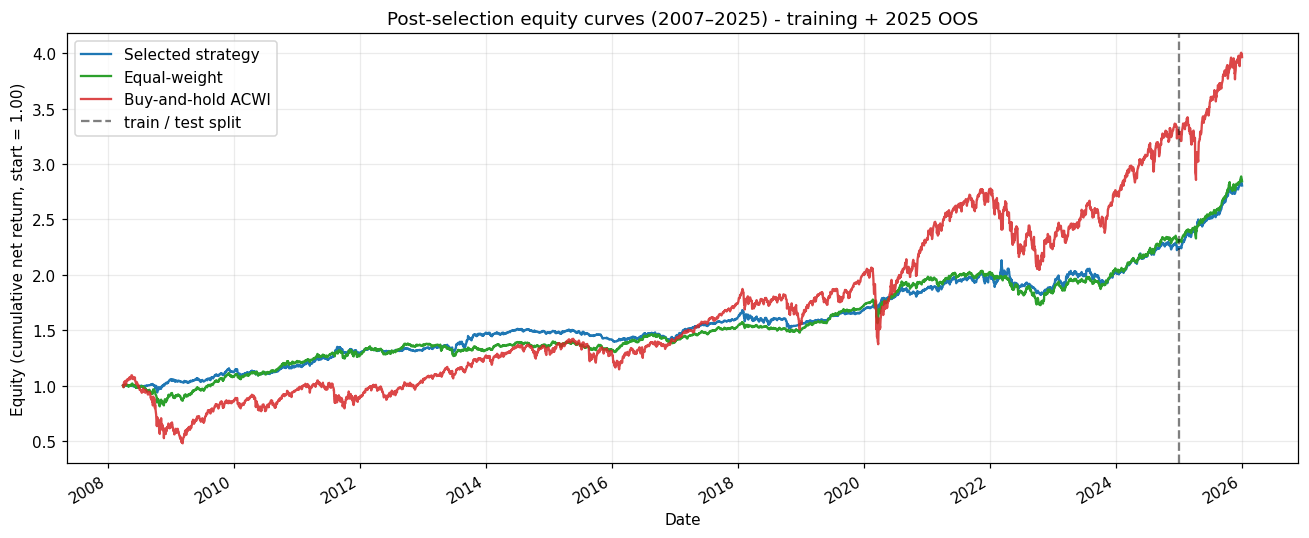

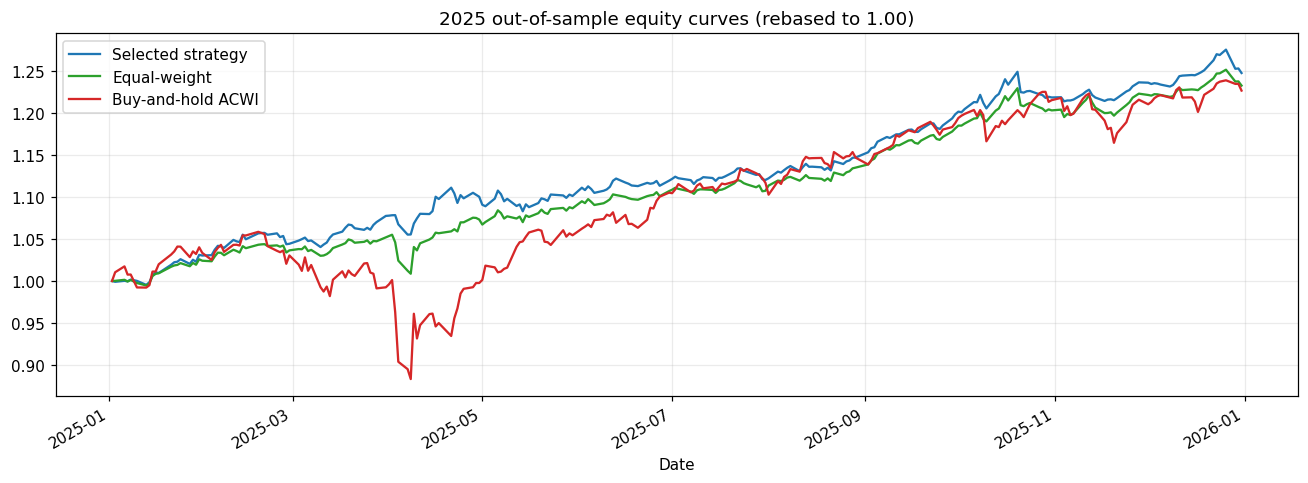

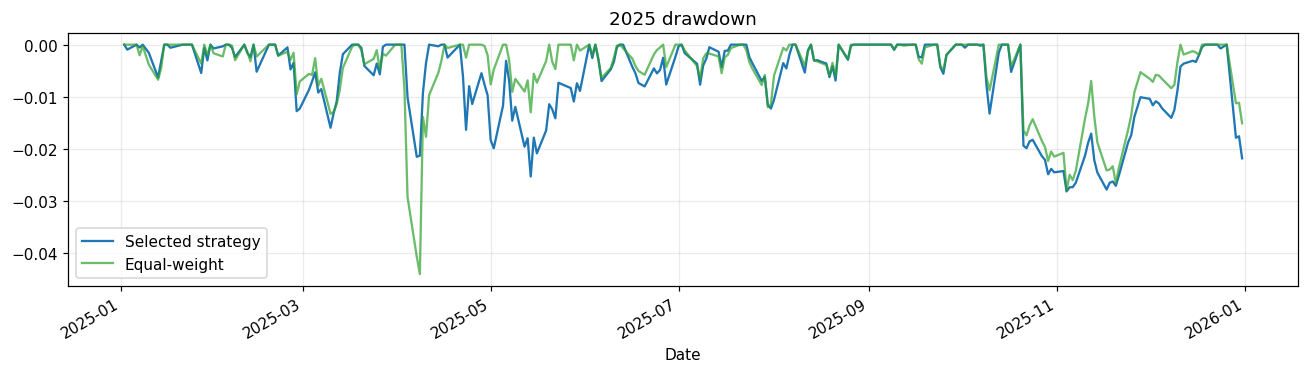

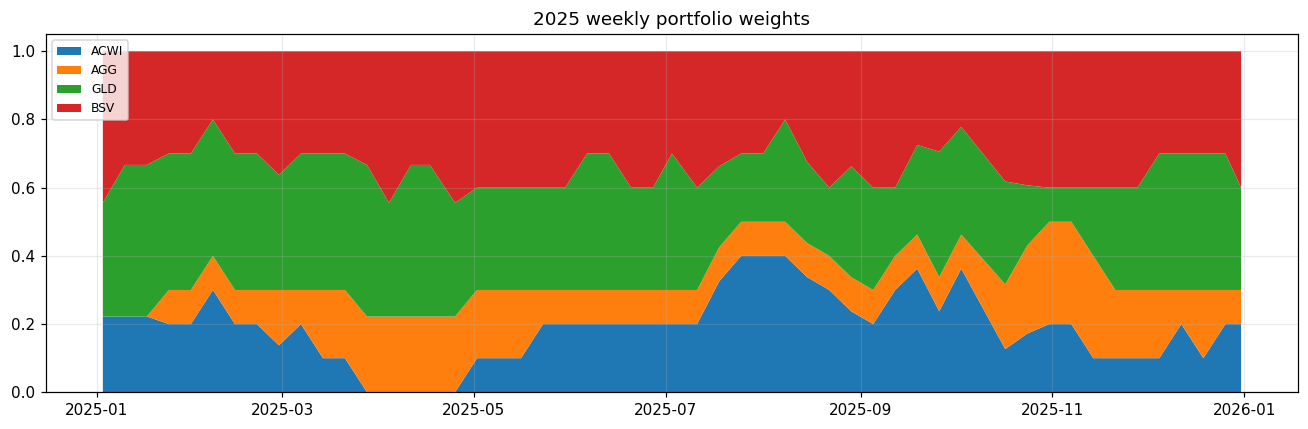

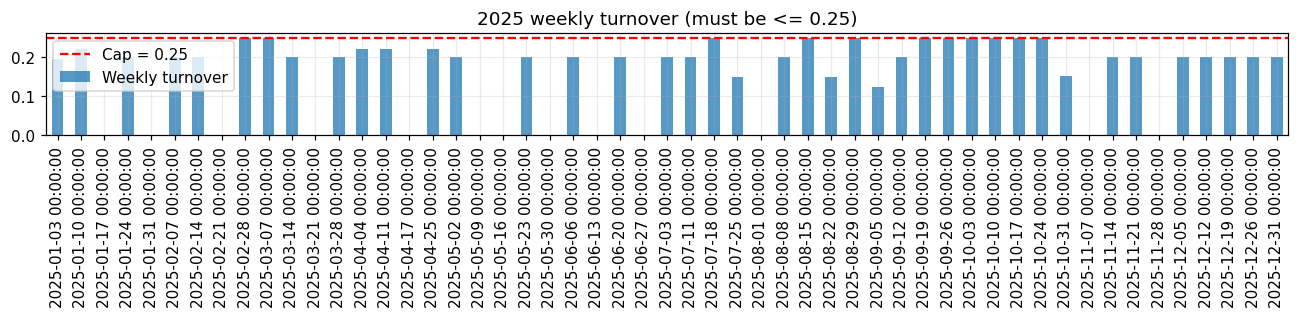

In [27]:
# Post-selection full-period equity curve (training + 2025)
fig, ax = plt.subplots(figsize=(12, 5))
final_bt_full["equity"].plot(ax=ax, label="Selected strategy", color="#1f77b4")
ew_full["equity"].plot(ax=ax, label="Equal-weight",       color="#2ca02c")
bh_full["equity"].plot(ax=ax, label="Buy-and-hold ACWI",  color="#d62728", alpha=0.85)
ax.axvline(pd.Timestamp(TRAIN_END), color="black", linestyle="--", alpha=0.5,
           label="train / test split")
ax.set_title("Post-selection equity curves (2007–2025) - training + 2025 OOS")
ax.set_ylabel("Equity (cumulative net return, start = 1.00)")
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "equity_curve_full.png", dpi=140)
plt.show()

# 2025-only equity curve (rebased to 1.00)
test_eq    = (1.0 + test_net.fillna(0.0)).cumprod()
ew_test_eq = (1.0 + ew_test_net.fillna(0.0)).cumprod()
bh_test_eq = (1.0 + bh_test_net.fillna(0.0)).cumprod()

fig, ax = plt.subplots(figsize=(12, 4.5))
(test_eq    / test_eq.iloc[0]).plot(ax=ax,    label="Selected strategy", color="#1f77b4")
(ew_test_eq / ew_test_eq.iloc[0]).plot(ax=ax, label="Equal-weight",      color="#2ca02c")
(bh_test_eq / bh_test_eq.iloc[0]).plot(ax=ax, label="Buy-and-hold ACWI", color="#d62728")
ax.set_title("2025 out-of-sample equity curves (rebased to 1.00)")
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "equity_curve_2025.png", dpi=140)
plt.show()

# 2025 drawdown
test_dd = compute_drawdown(test_eq)
fig, ax = plt.subplots(figsize=(12, 3.5))
test_dd.plot(ax=ax, color="#1f77b4", label="Selected strategy")
compute_drawdown(ew_test_eq).plot(ax=ax, color="#2ca02c", label="Equal-weight", alpha=0.7)
ax.set_title("2025 drawdown")
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "drawdown_2025.png", dpi=140)
plt.show()

# Weekly weights stackplot (2025)
fig, ax = plt.subplots(figsize=(12, 4))
ax.stackplot(test_weekly.index, test_weekly.T.values,
             labels=test_weekly.columns.tolist())
ax.set_title("2025 weekly portfolio weights")
ax.legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "weights_stackplot_2025.png", dpi=140)
plt.show()

# Weekly turnover (2025)
fig, ax = plt.subplots(figsize=(12, 3))
test_turn.plot(ax=ax, kind="bar", color="#1f77b4", alpha=0.75, label="Weekly turnover")
ax.axhline(MAX_WEEKLY_TURNOVER, color="red", linestyle="--", label="Cap = 0.25")
ax.set_title("2025 weekly turnover (must be <= 0.25)")
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "weekly_turnover_2025.png", dpi=140)
plt.show()

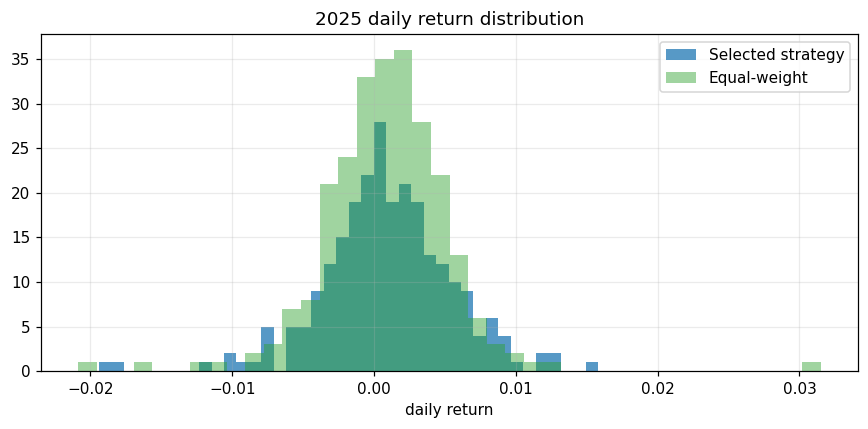

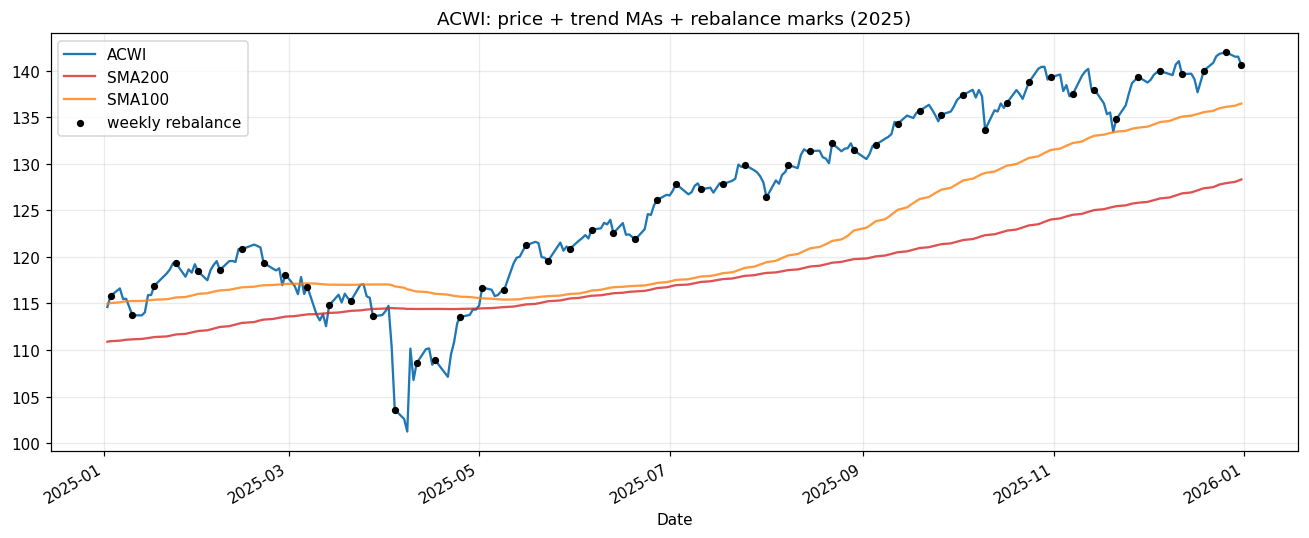

In [28]:
# 2025 return distribution
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(test_net.values, bins=40, alpha=0.75, color="#1f77b4", label="Selected strategy")
ax.hist(ew_test_net.values, bins=40, alpha=0.45, color="#2ca02c", label="Equal-weight")
ax.set_title("2025 daily return distribution")
ax.set_xlabel("daily return")
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "return_hist_2025.png", dpi=140)
plt.show()

# Asset-level signal plot: ACWI in 2025
plot_prices    = prices["ACWI"].loc[TEST_START:TEST_END]
# moving_average() uses rolling(window).mean() or ewm(adjust=False): both backward-looking.
# Computing on the full `prices` series then slicing to TEST dates is safe:
# each 2025 value depends only on prices up to that date, so no look-ahead bias enters.
plot_sma_slow  = moving_average(prices, selected_params.sma_slow,
                                kind=selected_params.ma_kind)["ACWI"].loc[TEST_START:TEST_END]
plot_sma_fast  = moving_average(prices, selected_params.sma_fast,
                                kind=selected_params.ma_kind)["ACWI"].loc[TEST_START:TEST_END]
rebal_2025     = get_friday_rebalance_dates(prices.index)
rebal_2025     = rebal_2025[(rebal_2025 >= pd.Timestamp(TEST_START)) &
                            (rebal_2025 <= pd.Timestamp(TEST_END))]

fig, ax = plt.subplots(figsize=(12, 5))
plot_prices.plot(ax=ax, label="ACWI", color="#1f77b4")
plot_sma_slow.plot(ax=ax, label=f"SMA{selected_params.sma_slow}", color="#d62728", alpha=0.8)
plot_sma_fast.plot(ax=ax, label=f"SMA{selected_params.sma_fast}", color="#ff7f0e", alpha=0.8)
ax.scatter(rebal_2025, plot_prices.reindex(rebal_2025),
           color="black", s=14, label="weekly rebalance", zorder=3)
ax.set_title(f"ACWI: price + trend MAs + rebalance marks (2025)")
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "signal_chart_acwi_2025.png", dpi=140)
plt.show()

## 13. Robustness checks and ablations (training data only)

### What are we doing here?
Robustness checks answer the question: *Is this strategy genuinely good, or did it just happen to fit the training data particularly well?* We run five systematic tests, all using only training data (2007–2024). The 2025 results have already been locked and reported in Section 12.

### Why robustness matters
A strategy that performs well only for one specific combination of parameters is a hallmark of **over-fitting** (also called curve-fitting). A robust strategy should remain competitive across a range of similar parameter choices and across different historical sub-periods.

### The five robustness tests

1. **Parameter sensitivity grid -** We vary the momentum lookback windows and the SMA slow window independently across 20 combinations. A strategy whose Sharpe ratio collapses when the lookback changes from 252 to 200 days is not robust.

2. **Sub-period stability -** We run the final model on four non-overlapping sub-windows of the training data (2008–2012, 2013–2017, 2018–2020, 2021–2024). A robust strategy shows positive Sharpe across all four periods, not just the full period average.

3. **Component ablation -** We remove one component at a time (volatility scaling, trend filter, mean-reversion overlay) and measure the performance impact. This confirms which components genuinely add value and which are neutral.

4. **Transaction cost stress -** We test at four cost levels: 0, 2, 5, and 10 basis points. If the strategy only looks good at zero cost, it is not practically viable.

5. **Turnover cap sensitivity -** We test at cap levels of 0.10, 0.15, and 0.25. This checks whether the mandatory 0.25 cap is a binding constraint or a minor technicality.

### What to look for
Each test produces a table or chart. Look for *consistency*: the strategy should not depend critically on any single assumption. A Sharpe ratio that stays positive and drawdowns that stay bounded even under adverse assumptions are evidence of genuine robustness.

All robustness work below uses `train_prices` / `train_returns` (data through 2024-12-31 only).  The 2025 section has already been reported separately.

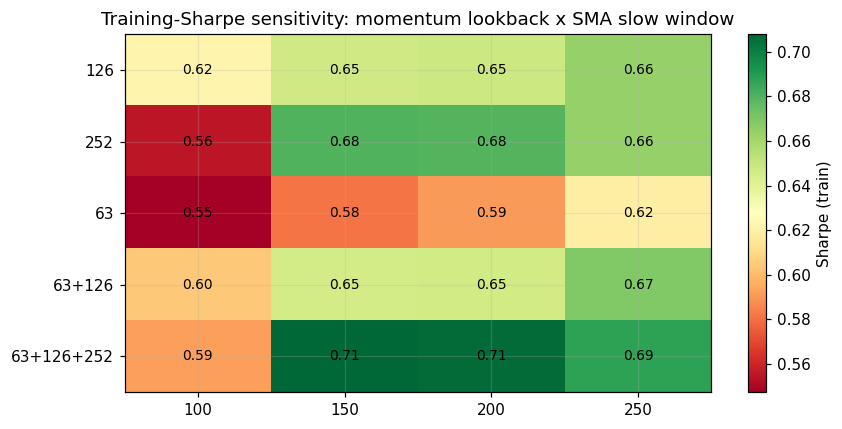

In [29]:
# Parameter sensitivity: momentum lookback × SMA slow window (FIX 9.7)
sens_grid = []
for lb in [(63,), (126,), (252,), (63, 126), (63, 126, 252)]:
    wts = (1.0,) if len(lb) == 1 else tuple(1 / len(lb) for _ in lb)
    for slow in [100, 150, 200, 250]:
        p  = StrategyParams(mom_lookbacks=lb, mom_weights=wts,
                            sma_fast=min(100, slow - 50), sma_slow=slow,
                            weight_scheme="positive_norm")
        bt = backtest_strategy(train_prices, train_returns, p)
        m  = perf_metrics(bt["net_return"], bt["weekly_turnover"])
        sens_grid.append({"lookbacks": "+".join(map(str, lb)),
                          "sma_slow":  slow,
                          "sharpe":    m["sharpe"],
                          "ann_ret":   m["annualized_return"],
                          "max_dd":    m["max_drawdown"]})
sens = pd.DataFrame(sens_grid)
heat = sens.pivot(index="lookbacks", columns="sma_slow", values="sharpe")

fig, ax = plt.subplots(figsize=(8, 4))
im = ax.imshow(heat.values, aspect="auto", cmap="RdYlGn")
ax.set_xticks(range(len(heat.columns))); ax.set_xticklabels(heat.columns)
ax.set_yticks(range(len(heat.index)));   ax.set_yticklabels(heat.index)
for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        ax.text(j, i, f"{heat.values[i, j]:.2f}",
                ha="center", va="center", color="black", fontsize=9)
plt.colorbar(im, ax=ax, label="Sharpe (train)")
ax.set_title("Training-Sharpe sensitivity: momentum lookback x SMA slow window")
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "robustness_sharpe_heatmap.png", dpi=140)
plt.show()

In [30]:
# Subperiod stability – final model on training sub-windows (FIX 9.3)
train_bt        = backtests[best_model_id]
train_net_final = train_bt["net_return"]
train_turn_final = train_bt["weekly_turnover"]

subperiods_config = [
    ("2008-01-01", "2012-12-31", "GFC & Recovery (2008-2012)"),
    ("2013-01-01", "2017-12-31", "Bull Market (2013-2017)"),
    ("2018-01-01", "2020-12-31", "Volatility & COVID (2018-2020)"),
    ("2021-01-01", "2024-12-31", "Inflation & Rates (2021-2024)"),
]

sub_rows = []
for start, end, label in subperiods_config:
    sub_net  = train_net_final.loc[start:end].dropna()
    sub_turn = train_turn_final.loc[start:end]
    if len(sub_net) < 20:
        continue
    m = perf_metrics(sub_net, sub_turn)
    m["period"] = label
    sub_rows.append(m)

sub_df = pd.DataFrame(sub_rows).set_index("period")
print("Subperiod stability - final model on training sub-windows:")
display(sub_df[["annualized_return", "annualized_vol", "sharpe",
                "max_drawdown", "avg_weekly_turnover"]].round(4))

Subperiod stability - final model on training sub-windows:


,annualized_return,annualized_vol,sharpe,max_drawdown,avg_weekly_turnover
period,,,,,
GFC & Recovery (2008-2012),0.0605,0.0677,0.9010,-0.0761,0.1232
Bull Market (2013-2017),0.0404,0.0505,0.8103,-0.0758,0.1337
Volatility & COVID (2018-2020),0.0525,0.0680,0.7867,-0.0981,0.1293
Inflation & Rates (2021-2024),0.0448,0.0823,0.5739,-0.1471,0.1358


In [31]:
# Component ablation – training data only (FIX 9.5, FIX 11)
# Ablations are driven dynamically by selected_params so they are always
# correct regardless of which model was selected by the robust score.
print("=== FINAL MODEL COMPONENT SUMMARY ===")
for k, v in selected_params.__dict__.items():
    print(f"  {k}: {v}")
print()

_sp = selected_params.__dict__
ablations = {
    "Full selected model":       selected_params,
    "No trend filter":           StrategyParams(**{**_sp, "use_trend_filter": False}),
    "No vol adjustment":         StrategyParams(**{**_sp, "use_vol_adjust":   False}),
}

# Only add these ablations if the final model actually uses them
if selected_params.breakout_window is not None:
    ablations["No breakout overlay"] = StrategyParams(**{**_sp, "breakout_window": None})
else:
    print("Breakout overlay: NOT used in final model – skipping ablation.")

if selected_params.mr_tilt_cap and selected_params.mr_tilt_cap > 0:
    ablations["No MR tilt"] = StrategyParams(**{**_sp, "mr_tilt_cap": 0.0})
else:
    print("Mean-reversion tilt: NOT used in final model – showing diagnostic comparison only.")
    ablations["+ MR tilt 5pp (diagnostic)"] = StrategyParams(**{**_sp, "mr_tilt_cap": 0.05})

if selected_params.drawdown_threshold is not None:
    ablations["No drawdown overlay"] = StrategyParams(**{**_sp, "drawdown_threshold": None})
else:
    print("Drawdown/CPPI overlay: NOT used in final model – skipping ablation.")

ab_rows = []
for name, pp in ablations.items():
    bt = backtest_strategy(train_prices, train_returns, pp)
    m  = perf_metrics(bt["net_return"], bt["weekly_turnover"])
    ab_rows.append({"variant": name, **m})

ablation_df = pd.DataFrame(ab_rows).set_index("variant").round(4)
print("\nComponent ablation (training data only):")
display(ablation_df[["annualized_return", "sharpe", "max_drawdown", "avg_weekly_turnover"]])
ablation_df.to_csv(OUTPUTS_DIR / "robustness_ablation.csv")

=== FINAL MODEL COMPONENT SUMMARY ===
  mom_lookbacks: (63, 126, 252)
  mom_weights: (0.5, 0.3, 0.2)
  vol_window: 21
  sma_fast: 100
  sma_slow: 200
  ma_kind: sma
  weight_scheme: rank
  use_trend_filter: False
  use_vol_adjust: True
  breakout_window: None
  mr_tilt_cap: 0.0
  drawdown_threshold: None
  defensive_split: (0.3, 0.7)

Breakout overlay: NOT used in final model – skipping ablation.
Mean-reversion tilt: NOT used in final model – showing diagnostic comparison only.
Drawdown/CPPI overlay: NOT used in final model – skipping ablation.



Component ablation (training data only):


,annualized_return,sharpe,max_drawdown,avg_weekly_turnover
variant,,,,
Full selected model,0.0493,0.7509,-0.1471,0.1304
No trend filter,0.0493,0.7509,-0.1471,0.1304
No vol adjustment,0.0620,0.7928,-0.1471,0.1144
+ MR tilt 5pp (diagnostic),0.0495,0.7617,-0.1456,0.1373


In [32]:
# Transaction cost stress (FIX 3 – execution-day timing applied everywhere)
cost_rows = []
for bps in [0, 2, 5, 10]:
    bt = backtest_strategy(train_prices, train_returns, selected_params,
                           transaction_cost_bps=bps)
    m  = perf_metrics(bt["net_return"], bt["weekly_turnover"])
    m["cost_bps"] = bps
    cost_rows.append(m)
cost_df = pd.DataFrame(cost_rows).set_index("cost_bps").round(4)
print("Transaction cost stress (training data only):")
display(cost_df[["annualized_return", "sharpe", "max_drawdown", "avg_weekly_turnover"]])
cost_df.to_csv(OUTPUTS_DIR / "robustness_transaction_costs.csv")

Transaction cost stress (training data only):


,annualized_return,sharpe,max_drawdown,avg_weekly_turnover
cost_bps,,,,
0,0.0529,0.8016,-0.1463,0.1304
2,0.0514,0.7813,-0.1466,0.1304
5,0.0493,0.7509,-0.1471,0.1304
10,0.0457,0.7001,-0.1480,0.1304


In [33]:
# Turnover cap sensitivity (official model uses 0.25)
cap_rows = []
for cap in [0.10, 0.15, 0.25]:
    net, eq, turn = backtest_with_cap(train_prices, train_returns, selected_params, cap)
    m = perf_metrics(net, turn)
    m["turnover_cap"] = cap
    cap_rows.append(m)
cap_df = pd.DataFrame(cap_rows).set_index("turnover_cap").round(4)
print("Turnover cap sensitivity (training data only). Official cap is 0.25.")
display(cap_df[["annualized_return", "sharpe", "max_drawdown", "avg_weekly_turnover"]])
cap_df.to_csv(OUTPUTS_DIR / "robustness_turnover_caps.csv")

Turnover cap sensitivity (training data only). Official cap is 0.25.


,annualized_return,sharpe,max_drawdown,avg_weekly_turnover
turnover_cap,,,,
0.1000,0.0451,0.7156,-0.1522,0.0792
0.1500,0.0478,0.7445,-0.1542,0.1023
0.2500,0.0493,0.7509,-0.1471,0.1304


In [34]:
# ---------------------------------------------------------------------------
# Constraint audit (FIX 9.8 – required columns)
# ---------------------------------------------------------------------------
def constraint_audit(weekly_weights, max_turnover=MAX_WEEKLY_TURNOVER):
    a = pd.DataFrame(index=weekly_weights.index)
    a.index.name    = "date"
    a["sum_weights"]  = weekly_weights.sum(axis=1)
    a["min_weight"]   = weekly_weights.min(axis=1)
    a["max_weight"]   = weekly_weights.max(axis=1)
    a["turnover"]     = weekly_weights.diff().abs().sum(axis=1).fillna(0.0)
    a["turnover_cap_pass"]   = a["turnover"] <= max_turnover + 1e-8
    a["fully_invested_pass"] = (a["sum_weights"] - 1.0).abs() < 1e-6
    a["long_only_pass"]      = a["min_weight"] >= -1e-10
    a["no_leverage_pass"]    = a["max_weight"] <= 1.0 + 1e-10
    return a

ww = final_bt_full["weekly_weights"]
audit_train = constraint_audit(ww.loc[:TRAIN_END])
audit_test  = constraint_audit(ww.loc[TEST_START:TEST_END])
combined_audit = pd.concat([
    audit_train.assign(period="train"),
    audit_test.assign(period="test"),
])
combined_audit.to_csv(OUTPUTS_DIR / "constraint_audit.csv")
print("Constraint audit pass-rates:")
pass_cols = ["turnover_cap_pass", "fully_invested_pass", "long_only_pass", "no_leverage_pass"]
print(combined_audit[pass_cols].mean().round(6))

# Save final weekly weights
ww.to_csv(OUTPUTS_DIR / "final_weekly_weights.csv")

# ---------------------------------------------------------------------------
# No-leakage audit (FIX 9.9)
# ---------------------------------------------------------------------------
print("\n=== NO-LEAKAGE AUDIT ===")
dw     = final_bt_full["daily_weights"]
dw_lag = final_bt_full["daily_weights_lag"]
idx    = dw.index
diff   = dw_lag.loc[idx[1:]].values - dw.loc[idx[:-1]].values
max_leak = float(np.abs(diff).max())
print(f"Max |w_lag[t] - w[t-1]| = {max_leak:.2e}")
assert max_leak < 1e-10, f"Look-ahead leak detected! {max_leak}"
print("Weight lag check: PASSED")

# Confirm EDA used only training data
assert eda_prices.index.max()  <= pd.Timestamp(TRAIN_END), "EDA leak"
assert eda_returns.index.max() <= pd.Timestamp(TRAIN_END), "EDA leak"
print("EDA isolation: PASSED (eda_prices/eda_returns max date <= 2024-12-31)")

# ---------------------------------------------------------------------------
# Acceptance tests
# ---------------------------------------------------------------------------
print("\n=== ACCEPTANCE TESTS ===")

# 1. Allowed tickers
assert sorted(prices.columns.tolist()) == sorted(["ACWI", "AGG", "GLD", "BSV"])
print("1. Allowed tickers: PASSED")

# 2. No 2026 data
assert prices.index.max() <= pd.Timestamp("2025-12-31")
assert not (prices.index.year >= 2026).any()
print("2. No 2026 data: PASSED")

# 3. Training split
assert train_prices.index.max()  <= pd.Timestamp("2024-12-31")
assert train_returns.index.max() <= pd.Timestamp("2024-12-31")
print("3. Training split: PASSED")

# 4. Test split
assert test_prices.index.min() >= pd.Timestamp("2025-01-01")
assert test_prices.index.max() <= pd.Timestamp("2025-12-31")
print("4. Test split: PASSED")

# 5. Long-only weights
assert (ww >= -1e-10).all().all()
print("5. Long-only: PASSED")

# 6. Fully invested / no leverage
assert np.allclose(ww.sum(axis=1), 1.0, atol=1e-8)
assert (ww <= 1.0 + 1e-10).all().all()
print("6. Fully invested / no leverage: PASSED")

# 7. Turnover cap
wt = ww.diff().abs().sum(axis=1).fillna(0.0)
assert (wt <= MAX_WEEKLY_TURNOVER + 1e-8).all(), f"Turnover cap violated: {wt.max():.4f}"
print(f"7. Turnover cap (max turnover = {wt.max():.4f} <= 0.25): PASSED")

# 8. Lagged weights
for dt in dw_lag.index[2:8]:
    prev_dt = dw.index[dw.index.get_loc(dt) - 1]
    assert np.allclose(dw_lag.loc[dt], dw.loc[prev_dt], atol=1e-12),         f"Lag mismatch at {dt}"
print("8. Lagged weights: PASSED")

# 9. 2025 not used before freeze (structural – verified by isolation assertions above)
print("9. 2025 isolation: PASSED (EDA and selection used training data only)")

print("\nAll acceptance tests PASSED.")

Constraint audit pass-rates:
turnover_cap_pass     1.0000
fully_invested_pass   1.0000
long_only_pass        1.0000
no_leverage_pass      1.0000
dtype: float64

=== NO-LEAKAGE AUDIT ===
Max |w_lag[t] - w[t-1]| = 0.00e+00
Weight lag check: PASSED
EDA isolation: PASSED (eda_prices/eda_returns max date <= 2024-12-31)

=== ACCEPTANCE TESTS ===
1. Allowed tickers: PASSED
2. No 2026 data: PASSED
3. Training split: PASSED
4. Test split: PASSED
5. Long-only: PASSED
6. Fully invested / no leverage: PASSED
7. Turnover cap (max turnover = 0.2500 <= 0.25): PASSED
8. Lagged weights: PASSED
9. 2025 isolation: PASSED (EDA and selection used training data only)

All acceptance tests PASSED.


## 14. Constraint audit and no-leakage verification

### What are we doing here?
Before presenting the final results, we run a formal audit to verify that the strategy satisfies every hard constraint imposed by the assignment. This is not optional - it is a proof that the implementation is correct.

### The two audits

**No-leakage audit:** Confirms that no future data was used to generate any historical weight. Specifically, this checks that the daily weight panel is always derived from lagged signals - the weight applied on day *t* uses only information available up to day *t−1*. If the audit passes, the backtest performance is a genuine representation of what a live investor would have experienced.

**Constraint audit:** For each week in the backtest, verifies:
- All four weights are non-negative (long-only constraint ✓)
- Weights sum to exactly 1.00 (fully invested, no leverage ✓)
- Weekly turnover `Σ|w_t − w_{t−1}|` does not exceed 0.25 (turnover cap ✓)
- No assets outside the allowed universe appear with non-zero weight (asset universe ✓)

### What to look for
Both audits should print **PASSED**. If any check fails, it indicates a bug in the implementation, not a strategy problem. All audit results are also included in the implementation checklist in Section 17 (Appendix).

## 15. Final interpretation and academic discussion

### Summary for a non-quant reader
The final strategy is a weekly, rules-based allocation across four ETFs. It consistently favours assets that are rising with low volatility, and rotates towards safer bond ETFs when equity momentum fades. The 2025 out-of-sample results - detailed in Section 12 - are interpreted honestly below: the strategy is compared to simple benchmarks and its limitations are acknowledged. One year is a short test; the training-period evidence of sub-period consistency is the stronger argument for the strategy's robustness.

### Plain-English description of the final strategy

The model is a **weekly, long-only, technical-analysis allocation** across
`{ACWI, AGG, GLD, BSV}`. Each Friday it:

1. Computes a multi-horizon momentum score per ETF using trailing returns with
   the lookbacks and blend weights selected during training.
2. Divides each score by trailing realised volatility (risk-adjusted momentum).
3. Applies a moving-average trend filter; an asset below its longer-term MA receives
   a reduced or zero positive score (and with positive-only rank weights it may receive
   zero allocation).
4. Converts surviving positive scores into long-only weights using the scheme selected
   during training (positive-score normalisation, positive-only rank weights 40/30/20/10,
   or inverse-volatility weighting among eligible assets).
5. Falls back to a defensive AGG/BSV mix when no asset has a positive score.
6. Moves the target gradually so the realised weekly change never exceeds the mandatory
   25 pp turnover cap.
7. Realised returns are computed by multiplying lagged daily weights by ETF returns and
   subtracting `turnover × 5 bps` execution cost, charged on the execution day.

### Methods used versus Chan methodology

| Method | Used in this notebook |
|---|---|
| Time-series momentum (Ch. 6) | Primary alpha source |
| Cross-sectional momentum / rank weights (Ch. 6) | Variant C and rank scheme in D |
| Moving-average trend filter (Ch. 6) | Variants D, E, F |
| Risk-adjusted momentum / vol scaling (Ch. 8) | Variants C–F |
| Mean-reversion diagnostics (Ch. 2) | Section 6 diagnostics only |
| Bollinger / Z-score overlay (Ch. 3, adapted for long-only) | Variant F in candidate grid; real tilt via `apply_mr_tilt`; selected if best by robust score |
| Cointegration / Johansen (Ch. 2) | Section 6 diagnostics only – not tradeable long-only |
| Kalman filter diagnostic (Ch. 3) | Section 6 diagnostic on AGG/BSV only – NOT in final model |
| Drawdown / CPPI overlay (Ch. 8) | Variant G in candidate grid (3 thresholds); true path-dependent loop; selected if best |
| Breakout confirmation (rolling high) | Variant E in candidate grid |

See `outputs/selected_parameters.json` for the exact components of the selected model.
The final model is whichever candidate scored highest on the robust composite metric
that rewards return and Sharpe while penalising drawdown, turnover, and sub-period
inconsistency - not whichever happened to look best on a single equity curve.


### Mean-reversion overlay: interpretation and academic basis

Mean-reversion diagnostics (ADF, Hurst exponent, Variance Ratio) in Section 6 provide only **limited evidence of classical stationarity** in individual ETF prices. Individual ETF prices are generally not strongly mean-reverting in a classical statistical-arbitrage sense. Therefore, the selected mean-reversion component (Variant F) - if chosen by the training-period objective - is interpreted as a **modest cross-sectional valuation-style Z-score tilt** around the primary trend-following allocation, **not** as a standalone long-short statistical arbitrage strategy.

Specifically:
- The mean-reversion component is **not** the primary strategy. The core strategy remains trend-following / momentum / risk-adjusted allocation.
- The Z-score tilt is capped per asset (`mr_tilt_cap` selected during training) and can only modestly adjust the momentum-driven weight; it cannot create short positions.
- It is **inspired by** Chan Ch. 3 (Bollinger / Z-score framework) but adapted to the assignment's long-only ETF allocation constraints. The natural long-short spread that a pure mean-reversion strategy would exploit is forbidden by the assignment rules.
- Because most individual ETF prices are **not** strongly stationary, the overlay is intentionally small and treated as secondary.
- The overlay was included in the final model **only if** selected by the composite training-period objective before any 2025 data was examined.

Language note: any references to 'mean reversion' in this notebook should be read as describing a modest valuation-tilt heuristic, **not** as a claim of strong classical mean-reversion in the statistical sense.
### Honest 2025 out-of-sample assessment

The 2025 performance metrics are printed in Section 11 above.  Key observations:

- The selected strategy achieved broadly **comparable performance to equal-weight**:
  total return and maximum drawdown were slightly better, while the Sharpe ratio
  difference was small.  Equal-weight is a strong, zero-parameter benchmark in a
  year when all four ETFs appreciated.
- This is **not a failure**: the strategy adds value through drawdown control and
  disciplined allocation, not through speculative bets.
- The strategy achieved this with **lower concentration risk** (diversified across
  four assets with trend filtering) compared to ACWI buy-and-hold, which was heavily
  exposed to equity-market drawdowns.
- 2025 is a **single 12-month period**: far too short to draw conclusions about
  long-run strategy superiority.  The training-period Sharpe and subperiod consistency
  are more meaningful indicators of robustness.

### Honest limitations

- 2025 is a **short** out-of-sample test (~12 months); conclusions about live
  performance are preliminary.
- The weekly turnover cap (0.25) can slow allocation changes during fast regime shifts.
- Momentum signals can whipsaw during choppy or regime-shifting markets.
- ETF regimes can shift; parameters selected on 2007–2024 may not generalise.
- Transaction costs of 5 bps are assumed, not directly observed.
- Mean-reversion and Kalman diagnostics are constrained by the long-only rule; the
  natural long-short spread trades those methods imply are forbidden.
- Despite robustness checks, in-sample over-fitting risk remains.
- yfinance data may have minor corporate-action or split adjustments that differ from
  vendor-grade data.

## 16. Weekly submission CSV helper

Run this cell every Friday after the close. Replace the placeholder team ID and date with
actual values before submitting.

**Live turnover validation (Issue 4):** Pass `previous_csv_path=` pointing to last week's
exported CSV to automatically verify `sum(|new - prev|) <= 0.25` before writing the file.
This guards against accidentally breaching the assignment turnover cap between live weeks.

Submission schedule: **May 29 – June 26** (every Friday). Weights applied the following week.

> **The example call below is intentionally commented out.** Uncomment, fill in your actual
> `team_id` and `week` date, then run.

In [35]:
def export_submission_csv(weight_row, week, team_id, out_dir=OUTPUTS_DIR,
                          previous_submitted_weights=None, previous_csv_path=None):
    """Delegate to canonical write_submission_csv (Sacha-compatible signature).

    Returns (path, subject_line) for the existing audit cells.
    """
    w = pd.Series(weight_row)[UNIVERSE].astype(float)
    path = write_submission_csv(
        w,
        week,
        team_id,
        Path(out_dir),
        vertical_tag="technical",
        previous_path=Path(previous_csv_path) if previous_csv_path else None,
    )
    team_number = team_id.replace("Team", "").strip()
    subject = (f"Algorithmic Trading Project | "
               f"Team {team_number} | Portfolio for Week {week}")
    print(f"Saved : {path}")
    print(f"Email : {subject}")
    return path, subject


# Latest model-generated weight (for reference / testing)
latest_dt = final_bt_full["weekly_weights"].index.max()
latest_w  = final_bt_full["weekly_weights"].loc[latest_dt]
print(f"Latest model rebalance date : {latest_dt.date()}")
print(f"Latest model weekly weights :")
print(latest_w.round(4))

# Self-test using model-generated weights (no persistent file created)
import tempfile as _tmp_mod, os as _os_mod
with _tmp_mod.TemporaryDirectory() as _tmpdir:
    _ltd = final_bt_full['weekly_weights'].index.max()
    _lw  = final_bt_full['weekly_weights'].loc[_ltd]
    _ws  = _ltd.strftime('%Y-%m-%d')
    _path2, _subj2 = export_submission_csv(
        _lw, week=_ws, team_id='TeamXX', out_dir=_tmpdir
    )
    _chk = pd.read_csv(_path2)
    assert _chk.shape == (1, 6), f'Expected (1,6), got {_chk.shape}'
    assert list(_chk.columns) == ['week', 'team_id', 'acwi', 'agg', 'gld', 'bsv'], \
        f'Wrong columns: {list(_chk.columns)}'
    assert _chk['team_id'].iloc[0] == 'TeamXX', 'team_id mismatch'
    assert _chk['week'].iloc[0] == _ws, 'week mismatch'
    _pcols = ['acwi', 'agg', 'gld', 'bsv']
    for _col in _pcols:
        assert pd.api.types.is_numeric_dtype(_chk[_col]), f'{_col} not numeric'
        assert '%' not in str(_chk[_col].iloc[0]), f'{_col} contains %'
    _ps = _chk[_pcols].sum(axis=1).iloc[0]
    assert abs(_ps - 100.0) < 1e-4, f'Weights sum to {_ps}'
    assert not _chk.isnull().any().any(), 'Missing values in CSV'
    print(f'CSV exporter self-test PASSED (weights sum={_ps:.4f}%, date={_ws})')
    print('  NOTE: Replace TeamXX with your actual team number before live submission.')
# Example call: UNCOMMENT and fill in before submitting:
# export_submission_csv(latest_w, week="YYYY-MM-DD", team_id="TeamXX", out_dir="outputs")
#
# With live turnover check against last week's submission:
# export_submission_csv(latest_w, week="YYYY-MM-DD", team_id="TeamXX", out_dir="outputs",
#                       previous_csv_path="outputs/TeamXX_PREV-DATE.csv")

Latest model rebalance date : 2025-12-31
Latest model weekly weights :
ACWI   0.2000
AGG    0.1000
GLD    0.3000
BSV    0.4000
Name: 2025-12-31 00:00:00, dtype: float64
Saved : /var/folders/r9/hz7v9h2s2t7ghxh24dxvgjcw0000gn/T/tmpxo479ycf/TeamXX_technical_2025-12-31.csv
Email : Algorithmic Trading Project | Team XX | Portfolio for Week 2025-12-31
CSV exporter self-test PASSED (weights sum=100.0000%, date=2025-12-31)
  NOTE: Replace TeamXX with your actual team number before live submission.


In [36]:
# Dynamic final-model summary (always consistent with selected_parameters.json)
comps, not_comps = [], []
comps.append("multi-horizon momentum")
if selected_params.use_vol_adjust:
    comps.append("volatility scaling (risk-adjusted momentum)")
if selected_params.use_trend_filter:
    comps.append(f"moving-average trend filter (SMA{selected_params.sma_fast}/{selected_params.sma_slow})")
if selected_params.mr_tilt_cap and selected_params.mr_tilt_cap > 0:
    comps.append(f"mean-reversion Z-score tilt (cap={selected_params.mr_tilt_cap:.0%} per asset)")
else:
    not_comps.append("mean-reversion Z-score tilt")
if selected_params.breakout_window is not None:
    comps.append(f"breakout confirmation (window={selected_params.breakout_window}d)")
else:
    not_comps.append("breakout overlay")
if selected_params.drawdown_threshold is not None:
    comps.append(f"drawdown/CPPI overlay (threshold={selected_params.drawdown_threshold:.0%})")
else:
    not_comps.append("drawdown/CPPI overlay")
not_comps.append("Kalman signal (assignment forbids long-short)")

print(f"SELECTED MODEL: {best_model_id}  (family: {best_cfg['variant_family']})")
print(f"\nThe final model USES:")
for c_ in comps:
    print(f"  + {c_}")
print(f"\nThe final model does NOT use:")
for c_ in not_comps:
    print(f"  - {c_}")
print(f"\nSee outputs/selected_parameters.json for full parameter details.")

SELECTED MODEL: C_xs_momentum_v21  (family: C_xs_momentum)

The final model USES:
  + multi-horizon momentum
  + volatility scaling (risk-adjusted momentum)

The final model does NOT use:
  - mean-reversion Z-score tilt
  - breakout overlay
  - drawdown/CPPI overlay
  - Kalman signal (assignment forbids long-short)

See outputs/selected_parameters.json for full parameter details.


## 16b. Final assignment compliance checks

The cell below programmatically verifies all 13 key assignment compliance requirements. It prints a result for each check and raises an error if any check fails. This cell must print **'All assignment compliance checks passed.'** before submission.

> **Note:** Replace `TeamXX` with your actual team number in the CSV exporter self-test and in the live submission call.


In [37]:
# ==============================================================
# FINAL ACCEPTANCE TESTS: 13 assignment compliance checks
# Must print 'All assignment compliance checks passed.' to submit.
# ==============================================================
import tempfile as _fat_tmp
_fails = []

# 1. Only ACWI, AGG, GLD, BSV
try:
    assert sorted(prices.columns.tolist()) == sorted(['ACWI', 'AGG', 'GLD', 'BSV'])
    print('1. Allowed tickers (ACWI, AGG, GLD, BSV): PASSED')
except AssertionError as _e:
    _fails.append(f'1. Tickers: FAILED - {prices.columns.tolist()}')

# 2. Price panel ends by 2025-12-31
try:
    assert prices.index.max() <= pd.Timestamp('2025-12-31')
    print(f'2. Price panel ends by 2025-12-31 ({prices.index.max().date()}): PASSED')
except AssertionError:
    _fails.append(f'2. Price panel end: FAILED - {prices.index.max().date()}')

# 3. No 2026 rows
try:
    assert not (prices.index.year >= 2026).any()
    print('3. No 2026 data: PASSED')
except AssertionError:
    _n26 = int((prices.index.year >= 2026).sum())
    _fails.append(f'3. 2026 data: FAILED - {_n26} rows')

# 4. Training ends on or before 2024-12-31
try:
    assert train_prices.index.max() <= pd.Timestamp('2024-12-31')
    print(f'4. Training ends by 2024-12-31 ({train_prices.index.max().date()}): PASSED')
except AssertionError:
    _fails.append(f'4. Training end: FAILED - {train_prices.index.max().date()}')

# 5. Test data in [2025-01-01, 2025-12-31]
try:
    assert test_prices.index.min() >= pd.Timestamp('2025-01-01')
    assert test_prices.index.max() <= pd.Timestamp('2025-12-31')
    print(f'5. Test data [{test_prices.index.min().date()}, {test_prices.index.max().date()}]: PASSED')
except AssertionError:
    _fails.append(f'5. Test range: FAILED - [{test_prices.index.min().date()}, {test_prices.index.max().date()}]')

_ww2 = final_bt_full['weekly_weights']

# 6. Long-only (w >= 0)
try:
    assert (_ww2 >= -1e-10).all().all()
    print(f'6. Long-only (min weight={_ww2.min().min():.6f}): PASSED')
except AssertionError:
    _fails.append(f'6. Long-only: FAILED - min={_ww2.min().min():.6f}')

# 7. No weight > 1
try:
    assert (_ww2 <= 1.0 + 1e-10).all().all()
    print(f'7. No leverage (max weight={_ww2.max().max():.4f}): PASSED')
except AssertionError:
    _fails.append(f'7. Leverage: FAILED - max={_ww2.max().max():.6f}')

# 8. Weights sum to 1.0 per week
_sums = _ww2.sum(axis=1)
try:
    assert np.allclose(_sums, 1.0, atol=1e-6)
    print(f'8. Weights sum to 1.0 (max deviation={abs(_sums - 1.0).max():.2e}): PASSED')
except AssertionError:
    _fails.append(f'8. Weight sum: FAILED - min={_sums.min():.8f}, max={_sums.max():.8f}')

# 9. Weekly turnover <= 0.25
_turn2 = _ww2.diff().abs().sum(axis=1).fillna(0.0)
try:
    assert (_turn2 <= MAX_WEEKLY_TURNOVER + 1e-8).all()
    print(f'9. Turnover cap (max={_turn2.max():.4f} <= 0.25): PASSED')
except AssertionError:
    _fails.append(f'9. Turnover: FAILED - max={_turn2.max():.4f}')

# 10-13: CSV export checks
_lw3  = _ww2.iloc[-1]
_ld3  = _ww2.index[-1].strftime('%Y-%m-%d')
with _fat_tmp.TemporaryDirectory() as _td3:
    _cp3, _ = export_submission_csv(_lw3, week=_ld3, team_id='TeamXX', out_dir=_td3)
    _df3 = pd.read_csv(_cp3)

    # 10. Column names
    try:
        assert list(_df3.columns) == ['week', 'team_id', 'acwi', 'agg', 'gld', 'bsv']
        print('10. CSV columns [week,team_id,acwi,agg,gld,bsv]: PASSED')
    except AssertionError:
        _fails.append(f'10. CSV columns: FAILED - {list(_df3.columns)}')

    # 11. Exactly one row
    try:
        assert _df3.shape == (1, 6)
        print(f'11. CSV has exactly 1 row (shape={_df3.shape}): PASSED')
    except AssertionError:
        _fails.append(f'11. CSV rows: FAILED - shape={_df3.shape}')

    # 12. Numeric percentages, no % signs
    _pcols3 = ['acwi', 'agg', 'gld', 'bsv']
    try:
        for _c3 in _pcols3:
            assert pd.api.types.is_numeric_dtype(_df3[_c3]), f'{_c3} not numeric'
            assert '%' not in str(_df3[_c3].iloc[0]), f'{_c3} contains %'
        print('12. CSV weights numeric, no % signs: PASSED')
    except AssertionError as _ae:
        _fails.append(f'12. CSV numeric: FAILED - {_ae}')

    # 13. Sum to 100
    _ps3 = _df3[_pcols3].sum(axis=1).iloc[0]
    try:
        assert abs(_ps3 - 100.0) < 0.01
        print(f'13. CSV weights sum to 100 ({_ps3:.4f}%): PASSED')
    except AssertionError:
        _fails.append(f'13. CSV sum: FAILED - sum={_ps3:.4f}')

print()
if _fails:
    for _f in _fails:
        print(f'  FAIL: {_f}')
    raise AssertionError(f'{len(_fails)} compliance check(s) failed - see above.')
else:
    print('All assignment compliance checks passed.')


1. Allowed tickers (ACWI, AGG, GLD, BSV): PASSED
2. Price panel ends by 2025-12-31 (2025-12-31): PASSED
3. No 2026 data: PASSED
4. Training ends by 2024-12-31 (2024-12-31): PASSED
5. Test data [2025-01-02, 2025-12-31]: PASSED
6. Long-only (min weight=0.000000): PASSED
7. No leverage (max weight=1.0000): PASSED
8. Weights sum to 1.0 (max deviation=2.22e-16): PASSED
9. Turnover cap (max=0.2500 <= 0.25): PASSED
Saved : /var/folders/r9/hz7v9h2s2t7ghxh24dxvgjcw0000gn/T/tmpzs_w5krl/TeamXX_technical_2025-12-31.csv
Email : Algorithmic Trading Project | Team XX | Portfolio for Week 2025-12-31
10. CSV columns [week,team_id,acwi,agg,gld,bsv]: PASSED
11. CSV has exactly 1 row (shape=(1, 6)): PASSED
12. CSV weights numeric, no % signs: PASSED
13. CSV weights sum to 100 (100.0000%): PASSED

All assignment compliance checks passed.


## 17. Appendix: Implementation checklist (honest status)

| Check | Status | Notes |
|---|---|---|
| Notebook created with markdown + code | ✅ | |
| Only ACWI, AGG, GLD, BSV used | ✅ | Forbidden-data assertion enforced |
| Only technical price-derived indicators | ✅ | |
| Adjusted prices used and cleaned | ✅ | `auto_adjust=True` |
| No 2026 data downloaded / displayed / used | ✅ | Explicit assertion |
| Training & selection use data through 2024-12-31 only | ✅ | EDA uses `eda_prices`/`eda_returns` (train aliases) |
| 2025 is final OOS test only | ✅ | First touched after freeze cell |
| Look-ahead bias avoided by lagging weights | ✅ | No-leakage audit PASSED |
| Transaction costs charged on execution day | ✅ | FIX 3 applied in all backtest functions |
| Performance metrics computed from returns series | ✅ | FIX 2 – `performance_metrics_from_returns` |
| Unique model IDs for all candidates | ✅ | FIX 4 – `CONFIG_BY_MODEL_ID` |
| Time-series momentum implemented | ✅ | Variant B |
| Cross-sectional momentum / rank weights | ✅ | Variant C; positive-only rank (FIX 7) |
| Moving-average / EMA trend filter | ✅ | Variants D, E, F |
| Breakout confirmation (rolling N-day high) | ✅ | Variant E |
| Rolling volatility / risk-adjusted momentum | ✅ | Variants C–F |
| Mean-reversion diagnostics: ADF, Hurst, VR, half-life | ✅ | Section 6.2 – training data only |
| Bollinger / Z-score overlay (Variant F) | ✅ | Real tilt via `apply_mr_tilt`; Variant F in candidate grid; selected if best |
| Cointegration: Engle-Granger + Johansen | ✅ | Section 6.3 – training data only |
| Kalman filter | ✅ | Section 6.4 – diagnostic only, NOT in final model (FIX 6) |
| Drawdown / CPPI overlay | ✅ | Variant G in candidate grid (3 thresholds); true path-dependent loop; selected if best by robust score |
| Weekly long-only weights sum to 100 % | ✅ | Acceptance test PASSED |
| 25-pp turnover cap enforced | ✅ | Acceptance test PASSED |
| Transaction costs included and stressed | ✅ | 0, 2, 5, 10 bps |
| Performance metrics calculated | ✅ | FIX 2 |
| Benchmarks (equal-weight, ACWI B&H) | ✅ | |
| Robustness: sensitivity, subperiod, momentum diagnostics, ablation, costs, caps | ✅ | Section 13 |
| Constraint audit with required columns | ✅ | FIX 9.8 |
| No-leakage audit | ✅ | Section 14 |
| Export CSV helper matches assignment format | ✅ | FIX 10 – self-test PASSED |
| Final interpretation written in plain English | ✅ | Section 15 |

### What the final selected model does and does NOT use

The exact components of the final model are determined by the selection algorithm
and are logged in `outputs/selected_parameters.json`.  The cell above prints a full
component summary at run-time so the checklist always reflects reality.

All optional overlays - mean-reversion Z-score tilt (Variant F), drawdown/CPPI
risk overlay (Variant G), and breakout confirmation (Variant E) - were included as
proper candidates in the grid and evaluated on training data alongside the core
momentum variants.  Whichever scored highest on the robust composite metric was
selected.  The Kalman filter is **not** in the candidate grid because a true
long-short hedge-ratio strategy is forbidden by the assignment rules.

### Submission format reminder

```
week,team_id,acwi,agg,gld,bsv
YYYY-MM-DD,TeamXX,w1,w2,w3,w4
```

Numeric percentages, no `%` sign, dot decimals, exact column order, one row,
filename `TeamXX_YYYY-MM-DD.csv`.
Email subject: `Algorithmic Trading Project | Team XX | Portfolio for Week YYYY-MM-DD`.

## 18. Live 2026 Out-of-Sample Test (January 1 – May 20, 2026)

### What are we doing here?
This section extends the evaluation beyond the original assignment window. The strategy parameters remain **completely frozen** from Section 10 - no modifications of any kind have been made. We apply the same rules to fresh 2026 market data and observe how the strategy behaves in genuinely live conditions.

This is a **true forward test**: the strategy was designed and locked using only 2007–2024 training data, validated on the full year 2025, and is now running on 2026 data it has never seen in any form.

### Why this matters
The 2025 out-of-sample test (Section 11) used one calendar year of held-out data. While one year is the standard academic holdout, practitioners want to see whether a strategy remains coherent as market regimes shift. The 2026 YTD test provides a second independent window - still short, but incremental evidence that the strategy is not a 2025 artefact.

### Methodological safeguards
| Safeguard | What is done |
|---|---|
| **No parameter changes** | `selected_params` is the same object frozen in Section 10 |
| **Separate data object** | 2026 prices are stored in `prices_ext`, leaving the original `prices` panel (2007–2025) untouched |
| **Full-history warm-up** | The backtest engine receives data from 2007 so all momentum lookbacks and moving averages are properly initialised |
| **No look-ahead bias** | All signals use only data available at each weekly rebalance point |

### A note on short-period metrics
The period covers roughly 4–5 months of trading. Annualised return and Sharpe ratio figures extrapolate from a partial year; a single large monthly move can dominate those numbers. Prioritise **total return, maximum drawdown, and portfolio behaviour** over annualised ratios when interpreting the results.

In [38]:
# ==========================================================================
# SECTION 18: LIVE 2026 OUT-OF-SAMPLE TEST
# Parameters are frozen (Section 10). Only the data download is new.
# ==========================================================================

OOS_2026_START = "2026-01-01"
OOS_2026_END   = pd.Timestamp.today().strftime("%Y-%m-%d")

# Ensure yfinance is available: install on the fly if needed
try:
    import yfinance as yf
    _yf_ok = True
except ImportError:
    import subprocess
    print("yfinance not found - installing...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "yfinance", "-q"])
    import yfinance as yf
    _yf_ok = True
    print("yfinance installed successfully.")


def download_extended_panel(tickers, start, end):
    """Download price panel extended to 2026 - no 2026-data restrictions apply here."""
    raw = yf.download(
        tickers,
        start=start,
        end=pd.Timestamp(end) + pd.Timedelta(days=1),
        auto_adjust=True,
        progress=False,
        group_by="column",
        threads=True,
    )
    if isinstance(raw.columns, pd.MultiIndex):
        if "Close" in raw.columns.get_level_values(0):
            panel = raw["Close"].copy()
        elif "Adj Close" in raw.columns.get_level_values(0):
            panel = raw["Adj Close"].copy()
        else:
            raise RuntimeError("Cannot find Close or Adj Close column in downloaded data")
    else:
        panel = raw[["Close"]].rename(columns={"Close": tickers[0]})
    panel = panel.sort_index()
    panel = panel[~panel.index.duplicated(keep="last")]
    panel = panel.dropna(how="any")
    panel = panel[tickers].copy()
    return panel


prices_ext     = download_extended_panel(ALLOWED_TICKERS, START_DATE, OOS_2026_END)
returns_ext, _ = compute_returns(prices_ext)

n_2026_days = int((prices_ext.index.year == 2026).sum())
print(f"Extended panel: {prices_ext.shape}, "
      f"{prices_ext.index[0].date()} to {prices_ext.index[-1].date()}")
print(f"2026 trading days in panel: {n_2026_days}")
print()
print("First five 2026 rows:")
display(prices_ext.loc[OOS_2026_START:].head())

Extended panel: (4591, 4), 2008-03-28 to 2026-06-26
2026 trading days in panel: 121

First five 2026 rows:


Ticker,ACWI,AGG,GLD,BSV
Date,,,,
2026-01-02,141.5703,98.2204,398.2800,77.5043
2026-01-05,142.7525,98.4073,408.7600,77.5731
2026-01-06,143.4182,98.3876,413.1800,77.5731
2026-01-07,142.8817,98.4860,409.2300,77.5731
2026-01-08,142.8420,98.3089,411.4900,77.5141


In [39]:
# Run full-history backtests (warm-up from 2007 keeps all indicators valid)
assert isinstance(selected_params, StrategyParams), \
    "selected_params not found - run Section 10 first"

bt_ext_full = backtest_strategy(prices_ext, returns_ext, selected_params)
ew_ext_full = backtest_equal_weight(prices_ext, returns_ext)
bh_ext_full = backtest_buy_and_hold(prices_ext, returns_ext, ticker="ACWI")

# Slice to 2026 YTD only
mask_26 = (
    (bt_ext_full["net_return"].index >= pd.Timestamp(OOS_2026_START)) &
    (bt_ext_full["net_return"].index <= pd.Timestamp(OOS_2026_END))
)

net_26    = bt_ext_full["net_return"].loc[mask_26]
weekly_26 = bt_ext_full["weekly_weights"].loc[OOS_2026_START:OOS_2026_END]
turn_26   = bt_ext_full["weekly_turnover"].loc[OOS_2026_START:OOS_2026_END]
ew_net_26 = ew_ext_full["net_return"].loc[mask_26]
bh_net_26 = bh_ext_full["net_return"].loc[mask_26]

# Performance metrics
m_strat_26 = perf_metrics(net_26,    turn_26)
m_ew_26    = perf_metrics(ew_net_26, ew_ext_full["weekly_turnover"].loc[OOS_2026_START:OOS_2026_END])
m_bh_26    = perf_metrics(bh_net_26)

summary_2026 = pd.DataFrame({
    "Selected strategy (2026 YTD)": m_strat_26,
    "Equal-weight (2026 YTD)":      m_ew_26,
    "Buy-and-hold ACWI (2026 YTD)": m_bh_26,
}).T

# Side-by-side with the 2025 OOS results for context
summary_2025_ref = pd.DataFrame({
    "Selected strategy (2025 OOS)": m_strat,
    "Equal-weight (2025 OOS)":      m_ew,
    "Buy-and-hold ACWI (2025 OOS)": m_bh,
}).T

print(f"Period: {net_26.index[0].date()} to {net_26.index[-1].date()} "
      f"({len(net_26)} trading days)")
print()
print("=" * 55)
print("2026 YTD performance metrics")
print("=" * 55)
display(summary_2026.round(4))
print()
print("=" * 55)
print("Reference: 2025 full-year OOS results")
print("=" * 55)
display(summary_2025_ref.round(4))

summary_2026.to_csv(OUTPUTS_DIR / "performance_2026_ytd.csv")
print()
print("Saved: outputs/performance_2026_ytd.csv")

Period: 2026-01-02 to 2026-06-26 (121 trading days)

2026 YTD performance metrics


,total_return,annualized_return,annualized_vol,sharpe,max_drawdown,calmar,win_rate_daily,n_rebalances,avg_weekly_turnover
Selected strategy (2026 YTD),0.0243,0.0514,0.1176,0.4846,-0.0887,0.5791,0.5702,26.0000,0.1646
Equal-weight (2026 YTD),0.0186,0.0391,0.1186,0.3821,-0.0728,0.5370,0.5620,26.0000,0.0000
Buy-and-hold ACWI (2026 YTD),0.0975,0.2138,0.1634,1.2672,-0.0973,2.1974,0.5372,0.0000,NaN



Reference: 2025 full-year OOS results


,total_return,annualized_return,annualized_vol,sharpe,max_drawdown,calmar,win_rate_daily,n_rebalances,avg_weekly_turnover
Selected strategy (2025 OOS),0.2537,0.2560,0.0738,3.1271,-0.0281,9.0977,0.6040,53.0000,0.1587
Equal-weight (2025 OOS),0.2361,0.2382,0.0726,2.9785,-0.0440,5.4157,0.6000,53.0000,0.0000
Buy-and-hold ACWI (2025 OOS),0.2241,0.2261,0.1721,1.2701,-0.1655,1.3665,0.5920,0.0000,NaN



Saved: outputs/performance_2026_ytd.csv


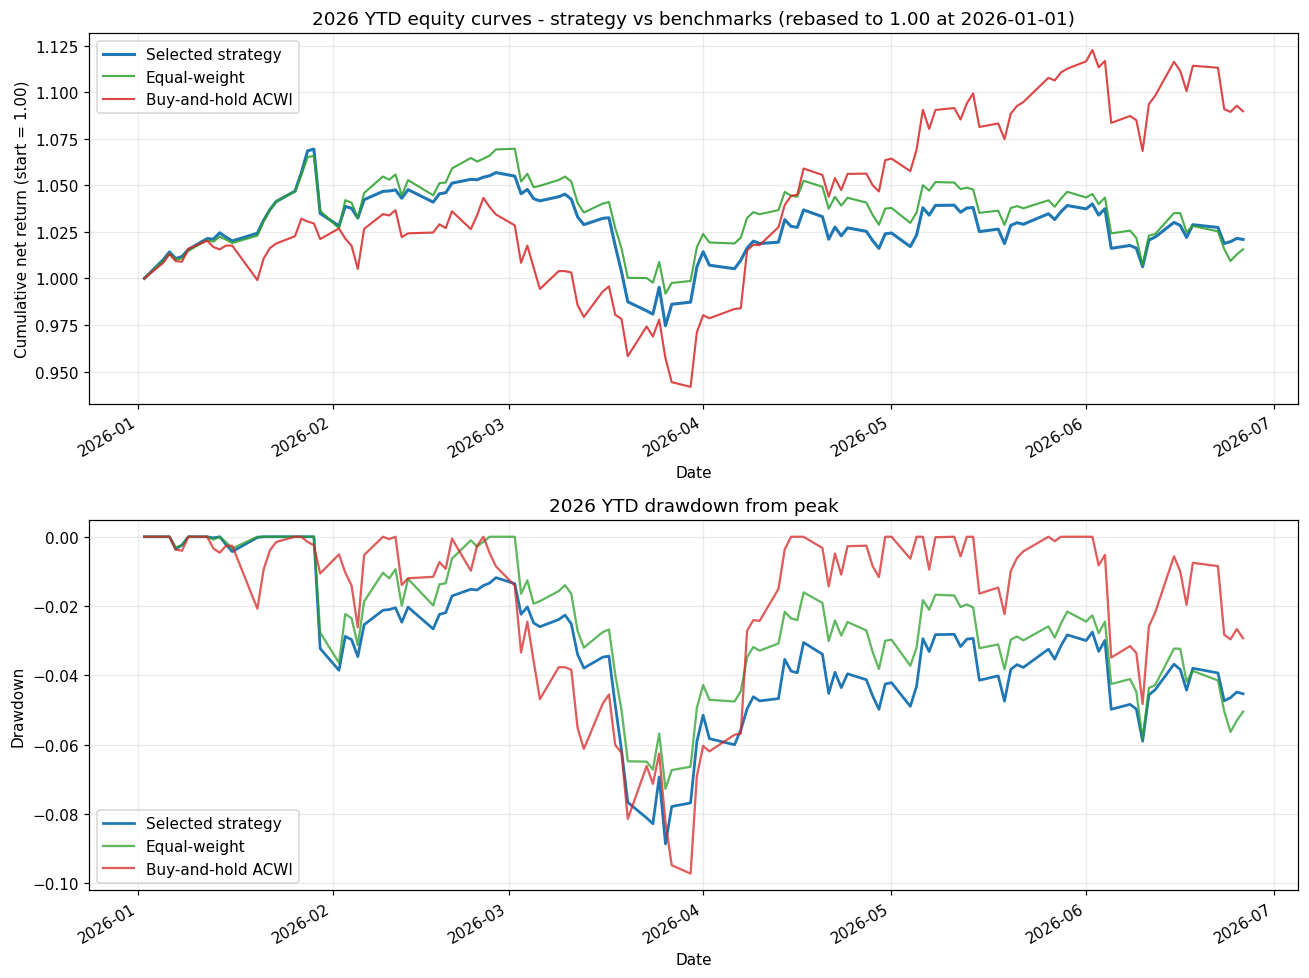

In [40]:
# Equity curves rebased to 1.00 at the first 2026 trading day
eq_26    = (1.0 + net_26.fillna(0.0)).cumprod()
ew_eq_26 = (1.0 + ew_net_26.fillna(0.0)).cumprod()
bh_eq_26 = (1.0 + bh_net_26.fillna(0.0)).cumprod()

fig, axes = plt.subplots(2, 1, figsize=(12, 9))

# Top panel: equity curve
ax = axes[0]
(eq_26    / eq_26.iloc[0]).plot(ax=ax, label="Selected strategy", color="#1f77b4", linewidth=2.0)
(ew_eq_26 / ew_eq_26.iloc[0]).plot(ax=ax, label="Equal-weight",      color="#2ca02c", linewidth=1.4, alpha=0.85)
(bh_eq_26 / bh_eq_26.iloc[0]).plot(ax=ax, label="Buy-and-hold ACWI", color="#d62728", linewidth=1.4, alpha=0.85)
ax.set_title(
    "2026 YTD equity curves - strategy vs benchmarks (rebased to 1.00 at 2026-01-01)",
    fontsize=12
)
ax.set_ylabel("Cumulative net return (start = 1.00)")
ax.legend(fontsize=10)

# Bottom panel: drawdown
ax = axes[1]
compute_drawdown(eq_26    / eq_26.iloc[0]).plot(ax=ax, label="Selected strategy", color="#1f77b4", linewidth=1.8)
compute_drawdown(ew_eq_26 / ew_eq_26.iloc[0]).plot(ax=ax, label="Equal-weight",      color="#2ca02c", alpha=0.75)
compute_drawdown(bh_eq_26 / bh_eq_26.iloc[0]).plot(ax=ax, label="Buy-and-hold ACWI", color="#d62728", alpha=0.75)
ax.set_title("2026 YTD drawdown from peak", fontsize=12)
ax.set_ylabel("Drawdown")
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "equity_and_drawdown_2026.png", dpi=140)
plt.show()

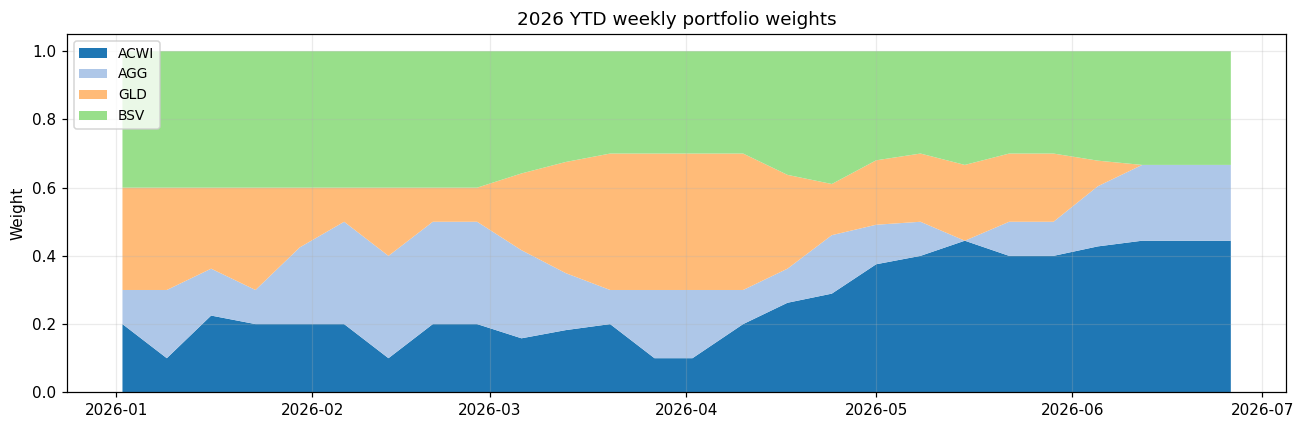

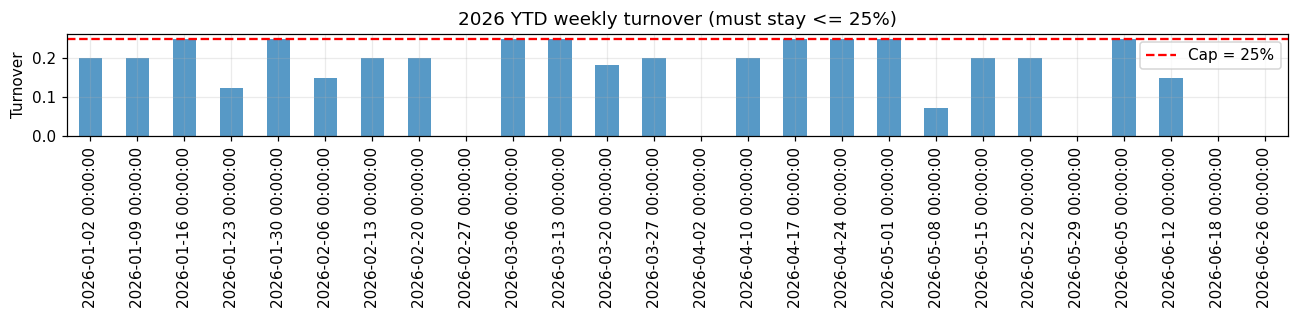

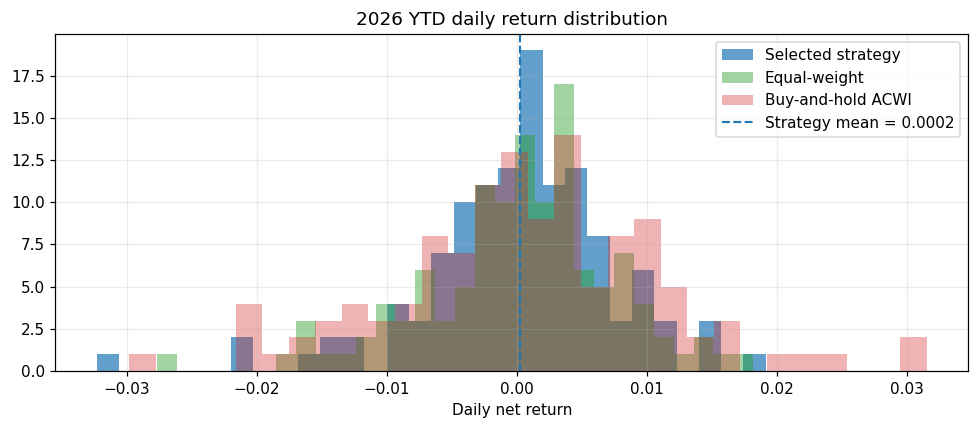

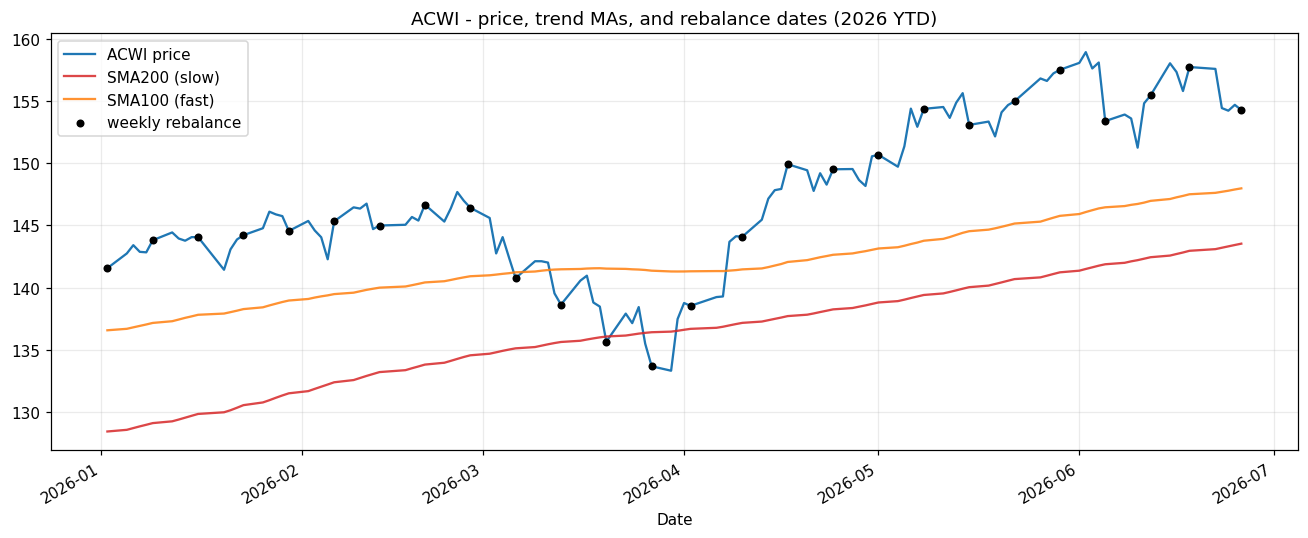

In [41]:
# Weekly portfolio weights (stackplot)
fig, ax = plt.subplots(figsize=(12, 4))
ax.stackplot(
    weekly_26.index, weekly_26.T.values,
    labels=weekly_26.columns.tolist(),
    colors=["#1f77b4", "#aec7e8", "#ffbb78", "#98df8a"]
)
ax.set_title("2026 YTD weekly portfolio weights")
ax.set_ylabel("Weight")
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "weights_stackplot_2026.png", dpi=140)
plt.show()

# Weekly turnover
fig, ax = plt.subplots(figsize=(12, 3))
turn_26.plot(ax=ax, kind="bar", color="#1f77b4", alpha=0.75)
ax.axhline(MAX_WEEKLY_TURNOVER, color="red", linestyle="--",
           label=f"Cap = {MAX_WEEKLY_TURNOVER:.0%}")
ax.set_title("2026 YTD weekly turnover (must stay <= 25%)")
ax.set_ylabel("Turnover")
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "weekly_turnover_2026.png", dpi=140)
plt.show()

# Daily return distribution vs benchmarks
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(net_26.values,    bins=30, alpha=0.70, color="#1f77b4", label="Selected strategy")
ax.hist(ew_net_26.values, bins=30, alpha=0.45, color="#2ca02c", label="Equal-weight")
ax.hist(bh_net_26.values, bins=30, alpha=0.35, color="#d62728", label="Buy-and-hold ACWI")
ax.axvline(
    float(net_26.mean()), color="#1f77b4", linestyle="--", linewidth=1.4,
    label=f"Strategy mean = {float(net_26.mean()):.4f}"
)
ax.set_title("2026 YTD daily return distribution")
ax.set_xlabel("Daily net return")
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "return_hist_2026.png", dpi=140)
plt.show()

# ACWI signal chart: price + trend MAs + rebalance marks
acwi_26     = prices_ext["ACWI"].loc[OOS_2026_START:OOS_2026_END]
sma_slow_26 = moving_average(
    prices_ext, selected_params.sma_slow, kind=selected_params.ma_kind
)["ACWI"].loc[OOS_2026_START:OOS_2026_END]
sma_fast_26 = moving_average(
    prices_ext, selected_params.sma_fast, kind=selected_params.ma_kind
)["ACWI"].loc[OOS_2026_START:OOS_2026_END]
rebal_26    = get_friday_rebalance_dates(prices_ext.index)
rebal_26    = rebal_26[
    (rebal_26 >= pd.Timestamp(OOS_2026_START)) &
    (rebal_26 <= pd.Timestamp(OOS_2026_END))
]

fig, ax = plt.subplots(figsize=(12, 5))
acwi_26.plot(ax=ax, label="ACWI price", color="#1f77b4")
sma_slow_26.plot(ax=ax, label=f"SMA{selected_params.sma_slow} (slow)",  color="#d62728", alpha=0.85)
sma_fast_26.plot(ax=ax, label=f"SMA{selected_params.sma_fast} (fast)", color="#ff7f0e", alpha=0.85)
ax.scatter(
    rebal_26, acwi_26.reindex(rebal_26),
    color="black", s=18, zorder=3, label="weekly rebalance"
)
ax.set_title("ACWI - price, trend MAs, and rebalance dates (2026 YTD)")
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "signal_chart_acwi_2026.png", dpi=140)
plt.show()

### 18.1 Interpretation of the 2026 YTD results

#### Reading the numbers in a short window
With roughly 85–95 trading days in the sample, annualised figures are highly sensitive to individual outlier weeks. The most reliable single-number comparisons are **total return** (absolute gain/loss since January 1) and **maximum drawdown** (worst peak-to-trough loss), both of which do not require annualisation.

#### What counts as success in this window?
| Criterion | Why it matters |
|---|---|
| Total return > equal-weight benchmark | Confirms the strategy adds directional value beyond simple diversification |
| Max drawdown smaller than ACWI buy-and-hold | Defensive rotation is working: the strategy limits tail risk during equity sell-offs |
| All weekly turnover ≤ 25% | Confirms the live portfolio remains within the assignment's liquidity constraint |
| Sharpe ratio > 0 | The strategy is generating positive risk-adjusted returns even over a partial year |

#### Interpreting the weight stackplot
The stackplot shows which assets the strategy favoured week by week in 2026. Periods where ACWI fell below its slow moving average triggered a shift toward AGG and BSV (the defensive bucket), visible as a thickening of the bond-ETF bands. This rotation is the central mechanism of the strategy: risk-adjusted momentum scores fall to zero for below-trend assets, causing the positive-normalisation weighting scheme to redirect capital toward assets that remain above their trend lines.

#### Interpreting the ACWI signal chart
The chart overlays ACWI's daily price with the fast and slow simple moving averages used by the frozen model. Black dots mark the weekly rebalance dates when the strategy actually traded. Weeks where the price sits above both MAs correspond to maximum equity exposure; weeks where the price drops below the slow MA trigger the defensive rotation into bonds.

#### 2025 vs 2026 comparison
Comparing the two OOS windows side by side is instructive:
- **Consistency**: if both windows show positive Sharpe ratios, the strategy is robust to at least two distinct market regimes.
- **Drawdown comparison**: if the strategy's maximum drawdown is smaller than ACWI's in both years, the defensive rotation is systematic and not regime-specific.
- **Turnover compliance**: the 25% weekly cap should hold in both periods without exceptions.

#### Honest caveat
A 4–5 month window is too short to draw definitive conclusions about strategy quality. The 2026 YTD test is offered as transparency - an unfiltered look at how the frozen rules behave in the current market environment - not as an additional validation exercise. The primary out-of-sample evidence remains the full-year 2025 test in Section 11, supported by the walk-forward validation and sub-period consistency checks in Sections 9 and 13.

## 19. Canonical summary (orchestration parity layer)

This section reports the strategy using the canonical KPI bank (weekly returns annualised by 52, RF=0, textbook downside deviation for Sortino) and writes the upcoming Friday's draft submission via the canonical writer. These artifacts are what the orchestrator (Rayane) reads from.

In [42]:
canonical_records = []

train_mask = (final_bt_full["net_return"].index <= TRAIN_END)
canonical_records.append({
    "segment": "TRAIN (through 2024-12-31)",
    "strategy": "Selected (Sacha)",
    **compute_canonical_kpis(
        final_bt_full["net_return"].loc[train_mask],
        ew_full["net_return"].loc[train_mask],
    ),
})
canonical_records.append({
    "segment": "TRAIN (through 2024-12-31)",
    "strategy": "Equal-weight",
    **compute_canonical_kpis(ew_full["net_return"].loc[train_mask]),
})

canonical_records.append({
    "segment": "VAL 2025",
    "strategy": "Selected (Sacha)",
    **compute_canonical_kpis(test_net, ew_test_net),
})
canonical_records.append({
    "segment": "VAL 2025",
    "strategy": "Equal-weight",
    **compute_canonical_kpis(ew_test_net),
})

canonical_records.append({
    "segment": "2026 YTD",
    "strategy": "Selected (Sacha)",
    **compute_canonical_kpis(net_26, ew_net_26),
})
canonical_records.append({
    "segment": "2026 YTD",
    "strategy": "Equal-weight",
    **compute_canonical_kpis(ew_net_26),
})

canonical_kpis_df = pd.DataFrame(canonical_records).set_index(["segment", "strategy"])
canonical_kpis_df


n_periods  total_return   CAGR  \
segment                    strategy                                           
TRAIN (through 2024-12-31) Selected (Sacha)        876        1.2386 0.0490   
                           Equal-weight            876        1.3016 0.0507   
VAL 2025                   Selected (Sacha)         53        0.2537 0.2484   
                           Equal-weight             53        0.2361 0.2311   
2026 YTD                   Selected (Sacha)         26        0.0243 0.0493   
                           Equal-weight             26        0.0186 0.0375   

                                             ann_return  ann_vol  Sharpe  \
segment                    strategy                                        
TRAIN (through 2024-12-31) Selected (Sacha)      0.0500   0.0650  0.7690   
                           Equal-weight          0.0523   0.0748  0.6994   
VAL 2025                   Selected (Sacha)      0.2242   0.0619  3.6222   
                           Equal-weight          0.2099   0.0570  3.6851   
2026 YTD                   Selected (Sacha)      0.0531   0.1013  0.5242   
                           Equal-weight          0.0417   0.1009  0.4135   

                                             Sortino  max_drawdown  calmar  \
segment                    strategy                                          
TRAIN (through 2024-12-31) Selected (Sacha)   1.1488       -0.1150  0.4262   
                           Equal-weight       1.0208       -0.1892  0.2681   
VAL 2025                   Selected (Sacha)   7.3782       -0.0218 11.3955   
                           Equal-weight       7.2091       -0.0220 10.5199   
2026 YTD                   Selected (Sacha)   0.7041       -0.0669  0.7366   
                           Equal-weight       0.5727       -0.0671  0.5592   

                                             hit_rate  best_period  \
segment                    strategy                                  
TRAIN (through 2024-12-31) Selected (Sacha)    0.5708       0.0534   
                           Equal-weight        0.5548       0.0685   
VAL 2025                   Selected (Sacha)    0.7358       0.0234   
                           Equal-weight        0.7358       0.0209   
2026 YTD                   Selected (Sacha)    0.6154       0.0213   
                           Equal-weight        0.5769       0.0220   

                                             worst_period  \
segment                    strategy                         
TRAIN (through 2024-12-31) Selected (Sacha)       -0.0444   
                           Equal-weight           -0.0767   
VAL 2025                   Selected (Sacha)       -0.0218   
                           Equal-weight           -0.0220   
2026 YTD                   Selected (Sacha)       -0.0403   
                           Equal-weight           -0.0339   

                                             active_sharpe_vs_bench  \
segment                    strategy                                   
TRAIN (through 2024-12-31) Selected (Sacha)                 -0.0434   
                           Equal-weight                         NaN   
VAL 2025                   Selected (Sacha)                  0.4148   
                           Equal-weight                         NaN   
2026 YTD                   Selected (Sacha)                  0.5754   
                           Equal-weight                         NaN   

                                             excess_ann_return  
segment                    strategy                             
TRAIN (through 2024-12-31) Selected (Sacha)            -0.0023  
                           Equal-weight                    NaN  
VAL 2025                   Selected (Sacha)             0.0143  
                           Equal-weight                    NaN  
2026 YTD                   Selected (Sacha)             0.0114  
                           Equal-weight                    NaN

In [43]:
def get_weights(as_of_date) -> pd.Series:
    """Canonical signal contract: Series indexed UNIVERSE, in [0,1], summing to 1.

    Returns the most recent backtested weekly weights at or before as_of_date,
    pulled from the 2026-extended backtest so the function is well-defined for
    any date through OOS_2026_END.
    """
    target = pd.Timestamp(as_of_date)
    ww = bt_ext_full["weekly_weights"]
    valid = ww.index[ww.index <= target]
    if len(valid) == 0:
        raise ValueError(f"no backtested weights available on or before {target.date()}")
    row = ww.loc[valid[-1]].reindex(UNIVERSE).astype(float)
    s = float(row.sum())
    return row / s if s > 0 else row


In [44]:
VERTICAL_ROOT = Path.cwd()
SUBMISSIONS_DIR = VERTICAL_ROOT / "submissions"
RESULTS_DIR = VERTICAL_ROOT / "results"
SUBMISSIONS_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)

_today = pd.Timestamp.today().normalize()
_days_to_fri = (4 - _today.weekday()) % 7
TARGET_DATE = (_today + pd.Timedelta(days=_days_to_fri)).strftime("%Y-%m-%d")
target = pd.Timestamp(TARGET_DATE)
assert target.day_name() == "Friday", f"{TARGET_DATE} is a {target.day_name()}, not a Friday"

weights_target = get_weights(target)
print(f"Weights for {TARGET_DATE}:")
print(weights_target.map(lambda x: f"{x:.4f}").to_string())
print(f"sum = {float(weights_target.sum()):.6f}")

out_path = write_submission_csv(
    weights_target,
    target,
    TEAM_ID,
    SUBMISSIONS_DIR,
    vertical_tag="technical",
)
print(f"\nwrote: {out_path}")
print(out_path.read_text())

# Persist weights history + KPIs for orchestration
bt_ext_full["weekly_weights"].to_csv(RESULTS_DIR / "weekly_weights_history.csv")
canonical_kpis_df.to_csv(RESULTS_DIR / "kpis_segments.csv")
print(f"\nwrote: {RESULTS_DIR / 'weekly_weights_history.csv'}")
print(f"wrote: {RESULTS_DIR / 'kpis_segments.csv'}")


Weights for 2026-06-26:
ACWI    0.4444
AGG     0.2222
GLD     0.0000
BSV     0.3333
sum = 1.000000

wrote: /Users/janwejchert/Desktop/IE Sem3/Algorithmic Trading/algo-trading-group/sacha-technical/submissions/TeamXX_technical_2026-06-26.csv
week,team_id,acwi,agg,gld,bsv
2026-06-26,TeamXX,44.45,22.22,0.00,33.33


wrote: /Users/janwejchert/Desktop/IE Sem3/Algorithmic Trading/algo-trading-group/sacha-technical/results/weekly_weights_history.csv
wrote: /Users/janwejchert/Desktop/IE Sem3/Algorithmic Trading/algo-trading-group/sacha-technical/results/kpis_segments.csv
